# Phase 3: Temporal Data Preparation

## CMS Inpatient Rehabilitation Facility (IRF) Provider Data

Phase 2 focused on cleaning, validating, and preparing the 2024 CMS IRF provider dataset for analysis.

Phase 3 expands the analysis to multiple years of CMS IRF data to explore temporal provider patterns that may be useful for identifying unusual utilization and payment behavior related to Fraud, Waste, and Abuse (FWA).

Cotiviti recommended using approximately 2–3 years of data rather than expanding to a much larger historical dataset.

### Initial Plan

1. Apply the established 2024 cleaning framework to the 2023 CMS IRF dataset.
2. Confirm consistency in variables, suppression patterns, and data quality between years.
3. Compare providers appearing across both years.
4. Combine compatible yearly datasets into a provider year dataset.
5. Evaluate changes in payment, utilization, and therapy patterns over time.
6. Determine whether adding 2022 provides meaningful additional value.
7. Use temporal findings and peer group comparisons to guide later anomaly detection.

Unusual values will be retained during data preparation. Statistical anomalies will not be interpreted as evidence of fraud without additional context.

In [1]:
# lets load raw datasets for 2023 and 2024

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_2023_raw = pd.read_csv(
    "Medicare_Post_Acute_Care_Utilization_Inpatient_Rehabilitation_Facility_by_Geography_and_Provider_2023.csv"
)

df_2024_raw = pd.read_csv(
    "RY26_PACPUF_IRF_2024_main_S.csv"
)

print("2023 raw shape:", df_2023_raw.shape)
print("2024 raw shape:", df_2024_raw.shape)

2023 raw shape: (1205, 82)
2024 raw shape: (1218, 82)


In [2]:
# Keep provider records only

df_2023 = df_2023_raw[
    df_2023_raw["SMRY_CTGRY"] == "PROVIDER"
].copy()

df_2024 = df_2024_raw[
    df_2024_raw["SMRY_CTGRY"] == "PROVIDER"
].copy()

print("2023 provider shape:", df_2023.shape)
print("2024 provider shape:", df_2024.shape)

print("\nUnique providers:")
print("2023:", df_2023["PRVDR_ID"].nunique())
print("2024:", df_2024["PRVDR_ID"].nunique())

2023 provider shape: (1152, 82)
2024 provider shape: (1165, 82)

Unique providers:
2023: 1152
2024: 1165


In [3]:
# Comparing the 2023 and 2024 schemas

cols_2023 = list(df_2023.columns)
cols_2024 = list(df_2024.columns)

print("2023 columns:", len(cols_2023))
print("2024 columns:", len(cols_2024))

print("\nColumns only in 2023:")
print(set(cols_2023) - set(cols_2024))

print("\nColumns only in 2024:")
print(set(cols_2024) - set(cols_2023))

print("\nSame column order:")
print(cols_2023 == cols_2024)

2023 columns: 82
2024 columns: 82

Columns only in 2023:
set()

Columns only in 2024:
set()

Same column order:
True


### 2023/2024 Schema Comparison

The 2023 and 2024 CMS IRF provider datasets contain the same 82 variables in the same column order.

- 2023 providers: 1,152
- 2024 providers: 1,165
- No duplicate provider IDs were identified within either year.
- No variables were unique to either dataset.
- Column order was identical across years.

This structural consistency supports applying the established 2024 cleaning framework to the 2023 dataset and later combining the datasets for temporal analysis.

In [4]:
# Count "*" suppression values in each year

suppression_compare = pd.DataFrame({
    "Column": df_2023.columns,
    "2023_Suppressed": [
        (df_2023[col].astype(str).str.strip() == "*").sum()
        for col in df_2023.columns
    ],
    "2024_Suppressed": [
        (df_2024[col].astype(str).str.strip() == "*").sum()
        for col in df_2024.columns
    ]
})

# Keep only variables with suppression in at least one year
suppression_compare = suppression_compare[
    (suppression_compare["2023_Suppressed"] > 0) |
    (suppression_compare["2024_Suppressed"] > 0)
].copy()

# Convert counts to percentages for comparison
suppression_compare["2023_Percent"] = (
    suppression_compare["2023_Suppressed"] / len(df_2023) * 100
).round(2)

suppression_compare["2024_Percent"] = (
    suppression_compare["2024_Suppressed"] / len(df_2024) * 100
).round(2)

display(suppression_compare)

,Column,2023_Suppressed,2024_Suppressed,2023_Percent,2024_Percent
17,BENE_DUAL_PCT,144,168,12.50,14.42
18,BENE_RRL_PCT,483,499,41.93,42.83
20,BENE_MALE_PCT,24,23,2.08,1.97
21,BENE_FEML_PCT,24,23,2.08,1.97
22,BENE_RACE_WHT_PCT,21,19,1.82,1.63
...,...,...,...,...,...
77,COTRT_OT_MNTS,8,6,0.69,0.52
78,TOT_SLP_MNTS,8,6,0.69,0.52
79,INDVDL_SLP_MNTS,8,6,0.69,0.52
80,CNCRNT_GRP_SLP_MNTS,8,6,0.69,0.52


In [5]:
# Check "+" values across both years

plus_compare = []

for col in df_2023.columns:
    count_2023 = (df_2023[col].astype(str).str.strip() == "+").sum()
    count_2024 = (df_2024[col].astype(str).str.strip() == "+").sum()

    if count_2023 > 0 or count_2024 > 0:
        plus_compare.append({
            "Column": col,
            "2023_Plus": count_2023,
            "2024_Plus": count_2024
        })

plus_compare = pd.DataFrame(plus_compare)

display(plus_compare)

,Column,2023_Plus,2024_Plus
0,BENE_DUAL_PCT,8,8


### Suppression and Special Value Comparison

CMS suppression patterns were compared between the 2023 and 2024 provider datasets before applying cleaning rules.

- 63 variables contained `"*"` suppression values.
- Suppression percentages were generally similar across the two years.
- Therapy variables had very low suppression in both years (0.69% in 2023 and 0.52% in 2024).
- `BENE_DUAL_PCT` was the only variable containing the special `"+"` notation.
- Exactly 8 `"+"` values occurred in `BENE_DUAL_PCT` in both 2023 and 2024.

The consistent schema and similar suppression/special value patterns support applying the same general cleaning framework across both years.

Suppressed and special values will be converted to missing (`NaN`) rather than zero so that unavailable CMS data are not interpreted as true zero values.

In [6]:
# already did final clean of 2024 and partial clean of 2023. lets load. 

df_2023_clean = df_2023.copy()
df_2024_clean = df_2024.copy()

print("2023 clean starting shape:", df_2023_clean.shape)
print("2024 clean starting shape:", df_2024_clean.shape)

2023 clean starting shape: (1152, 82)
2024 clean starting shape: (1165, 82)


In [7]:
# Replace CMS suppression/special values with NaN

for dataset in [df_2023_clean, df_2024_clean]:
    dataset.replace(["*", "+"], np.nan, inplace=True)

# Verify they are gone
for year, dataset in [
    ("2023", df_2023_clean),
    ("2024", df_2024_clean)
]:
    star_count = (
        dataset.astype(str)
        .apply(lambda col: col.str.strip().eq("*").sum())
        .sum()
    )

    plus_count = (
        dataset.astype(str)
        .apply(lambda col: col.str.strip().eq("+").sum())
        .sum()
    )

    print(f"{year} remaining '*':", star_count)
    print(f"{year} remaining '+':", plus_count)

2023 remaining '*': 0
2023 remaining '+': 0
2024 remaining '*': 0
2024 remaining '+': 0


In [8]:
# lets check pandas structuring real quick 

dtype_compare = pd.DataFrame({
    "Column": df_2023_clean.columns,
    "2023_Type": df_2023_clean.dtypes.astype(str).values,
    "2024_Type": df_2024_clean.dtypes.astype(str).values
})

display(dtype_compare)

,Column,2023_Type,2024_Type
0,YEAR,int64,int64
1,YEAR_TYPE,object,object
2,SMRY_CTGRY,object,object
3,SRVC_CTGRY,object,object
4,PRVDR_ID,object,object
...,...,...,...
77,COTRT_OT_MNTS,object,object
78,TOT_SLP_MNTS,object,object
79,INDVDL_SLP_MNTS,object,object
80,CNCRNT_GRP_SLP_MNTS,object,object


In [9]:
# define 

text_cols = [
    "YEAR_TYPE",
    "SMRY_CTGRY",
    "SRVC_CTGRY",
    "PRVDR_ID",
    "PRVDR_NAME",
    "PRVDR_CITY",
    "STATE",
    "PRVDR_ZIP"
]

# All remaining columns should be numeric
numeric_cols = [
    col for col in df_2023_clean.columns
    if col not in text_cols
]

print("Text / ID columns:", len(text_cols))
print("Numeric columns:", len(numeric_cols))
print("Total:", len(text_cols) + len(numeric_cols))

Text / ID columns: 8
Numeric columns: 74
Total: 82


In [10]:
# Convert analytical variables to numeric in both years

for dataset in [df_2023_clean, df_2024_clean]:
    for col in numeric_cols:
        dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

print("Numeric conversion complete.")

print("\n2023 numeric columns:",
      df_2023_clean[numeric_cols].select_dtypes(include=np.number).shape[1])

print("2024 numeric columns:",
      df_2024_clean[numeric_cols].select_dtypes(include=np.number).shape[1])

Numeric conversion complete.

2023 numeric columns: 74
2024 numeric columns: 74


In [11]:
# Expected missing values from CMS special values in the original data

expected_missing_2023 = sum(
    (df_2023[col].astype(str).str.strip().isin(["*", "+"])).sum()
    for col in numeric_cols
)

expected_missing_2024 = sum(
    (df_2024[col].astype(str).str.strip().isin(["*", "+"])).sum()
    for col in numeric_cols
)

# Actual missing values after numeric conversion

actual_missing_2023 = df_2023_clean[numeric_cols].isna().sum().sum()
actual_missing_2024 = df_2024_clean[numeric_cols].isna().sum().sum()

print("2023 expected missing:", expected_missing_2023)
print("2023 actual missing:  ", actual_missing_2023)
print("2023 unexpected:      ", actual_missing_2023 - expected_missing_2023)

print()

print("2024 expected missing:", expected_missing_2024)
print("2024 actual missing:  ", actual_missing_2024)
print("2024 unexpected:      ", actual_missing_2024 - expected_missing_2024)

2023 expected missing: 15358
2023 actual missing:   15358
2023 unexpected:       0

2024 expected missing: 15294
2024 actual missing:   15294
2024 unexpected:       0


### Numeric Conversion Validation

After CMS suppression and special values were converted to missing (`NaN`), analytical variables were converted to numeric format using the same process for both years.

- 2023 contained 15,358 expected missing numeric values and 15,358 observed missing values after conversion.
- 2024 contained 15,294 expected missing numeric values and 15,294 observed missing values after conversion.
- No unexpected missing values were introduced in either dataset.

This confirms that numeric conversion did not result in additional data loss beyond the previously identified CMS suppression and special value notation.

In [12]:
# Identify percentage variables

percent_cols = [
    col for col in numeric_cols
    if col.endswith("_PCT")
]

print("Percentage variables:", len(percent_cols))

# Check for values outside 0–100

for year, dataset in [
    ("2023", df_2023_clean),
    ("2024", df_2024_clean)
]:
    below_zero = (dataset[percent_cols] < 0).sum().sum()
    above_100 = (dataset[percent_cols] > 100).sum().sum()

    print(f"\n{year}")
    print("Values below 0:", below_zero)
    print("Values above 100:", above_100)

Percentage variables: 51

2023
Values below 0: 0
Values above 100: 0

2024
Values below 0: 0
Values above 100: 0


In [13]:
# check negative values 

for year, dataset in [
    ("2023", df_2023_clean),
    ("2024", df_2024_clean)
]:
    negative_counts = (dataset[numeric_cols] < 0).sum()
    negative_counts = negative_counts[negative_counts > 0]

    print(f"\n{year} variables containing negative values:")

    if len(negative_counts) == 0:
        print("None")
    else:
        display(negative_counts)


2023 variables containing negative values:
None

2024 variables containing negative values:
None


In [14]:
# Check whether therapy components equal reported therapy totals

therapy_checks = {
    "PT": ["TOT_PT_MNTS", "INDVDL_PT_MNTS", "CNCRNT_GRP_PT_MNTS", "COTRT_PT_MNTS"],
    "OT": ["TOT_OT_MNTS", "INDVDL_OT_MNTS", "CNCRNT_GRP_OT_MNTS", "COTRT_OT_MNTS"],
    "SLP": ["TOT_SLP_MNTS", "INDVDL_SLP_MNTS", "CNCRNT_GRP_SLP_MNTS", "COTRT_SLP_MNTS"]
}

for year, dataset in [
    ("2023", df_2023_clean),
    ("2024", df_2024_clean)
]:
    print(f"\n{year} Therapy Consistency")

    for therapy, cols in therapy_checks.items():

        total = dataset[cols[0]]
        components = dataset[cols[1:]].sum(axis=1, min_count=3)

        valid = total.notna() & components.notna()

        mismatches = (total[valid] != components[valid]).sum()

        print(
            f"{therapy}: {valid.sum()} providers checked, "
            f"{mismatches} mismatches"
        )


2023 Therapy Consistency
PT: 1144 providers checked, 0 mismatches
OT: 1144 providers checked, 0 mismatches
SLP: 1144 providers checked, 0 mismatches

2024 Therapy Consistency
PT: 1159 providers checked, 0 mismatches
OT: 1159 providers checked, 0 mismatches
SLP: 1159 providers checked, 0 mismatches


### Cross Year Therapy Integrity Check

Therapy utilization variables were checked for internal consistency in both datasets.

For PT, OT, and SLP, reported total therapy minutes were compared with the sum of individual, concurrent/group, and cotreatment minutes.

- 2023: 1,144 providers had complete therapy data, with 0 mismatches.
- 2024: 1,159 providers had complete therapy data, with 0 mismatches.
- No inconsistencies were identified for PT, OT, or SLP in either year.

These results support consistent use of the therapy variables for cross year and temporal analysis.

In [15]:
# cross year comparison

comparison_cols = [
    "BENE_DSTNCT_CNT",
    "TOT_EPSD_STAY_CNT",
    "TOT_SRVC_DAYS",
    "TOT_CHRG_AMT",
    "TOT_ALOWD_AMT",
    "TOT_MDCR_PYMT_AMT",
    "TOT_MDCR_STDZD_PYMT_AMT",
    "TOT_OUTLIER_PYMT_AMT",
    "BENE_AVG_AGE",
    "BENE_AVG_RISK_SCRE",
    "TOT_PT_MNTS",
    "TOT_OT_MNTS",
    "TOT_SLP_MNTS"
]

comparison_2023 = (
    df_2023_clean[comparison_cols]
    .describe()
    .T[["count", "mean", "50%", "min", "max"]]
    .rename(columns={
        "count": "2023_Count",
        "mean": "2023_Mean",
        "50%": "2023_Median",
        "min": "2023_Min",
        "max": "2023_Max"
    })
)

comparison_2024 = (
    df_2024_clean[comparison_cols]
    .describe()
    .T[["count", "mean", "50%", "min", "max"]]
    .rename(columns={
        "count": "2024_Count",
        "mean": "2024_Mean",
        "50%": "2024_Median",
        "min": "2024_Min",
        "max": "2024_Max"
    })
)

cross_year_summary = comparison_2023.join(comparison_2024)

display(cross_year_summary.round(2))

,2023_Count,2023_Mean,2023_Median,2023_Min,2023_Max,2024_Count,2024_Mean,2024_Median,2024_Min,2024_Max
BENE_DSTNCT_CNT,1152.0,316.16,196.00,13.00,2893.0,1165.0,335.11,209.00,11.00,2.947000e+03
TOT_EPSD_STAY_CNT,1152.0,350.64,209.00,14.00,3296.0,1165.0,373.18,221.00,11.00,3.305000e+03
TOT_SRVC_DAYS,1152.0,4343.09,2631.00,157.00,43341.0,1165.0,4590.95,2771.00,137.00,4.367800e+04
TOT_CHRG_AMT,1152.0,19489854.46,13421082.00,317327.00,340225930.0,1165.0,21422328.23,14672813.00,224752.00,3.742799e+08
TOT_ALOWD_AMT,1152.0,8517568.97,5220098.00,224435.00,92926786.0,1165.0,9459792.43,5833028.00,165747.00,9.925966e+07
TOT_MDCR_PYMT_AMT,1152.0,8362599.82,5123044.50,222835.00,91481720.0,1165.0,9289369.98,5761628.00,161619.00,9.758301e+07
TOT_MDCR_STDZD_PYMT_AMT,1152.0,8307893.26,5022124.00,344182.00,78302380.0,1165.0,9266730.47,5676481.00,271105.00,8.191882e+07
TOT_OUTLIER_PYMT_AMT,1152.0,212009.53,58443.50,0.00,8190734.0,1165.0,310065.85,77218.00,0.00,9.939920e+06
BENE_AVG_AGE,1152.0,76.69,77.00,61.00,83.0,1165.0,77.22,78.00,63.00,8.300000e+01
BENE_AVG_RISK_SCRE,1152.0,2.50,2.38,1.09,98.0,1165.0,2.41,2.39,0.89,5.220000e+00


In [16]:
# risk score? 

risk_check_2023 = df_2023_clean[
    [
        "PRVDR_ID",
        "PRVDR_NAME",
        "PRVDR_CITY",
        "STATE",
        "TOT_EPSD_STAY_CNT",
        "BENE_AVG_AGE",
        "BENE_AVG_RISK_SCRE"
    ]
].sort_values(
    "BENE_AVG_RISK_SCRE",
    ascending=False
)

display(risk_check_2023.head(10))

,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_AGE,BENE_AVG_RISK_SCRE
1203,530015,St Johns Medical Center,Jackson,WY,28,79,98.00
1030,450697,Texas Vista Medical Center,San Antonio,TX,38,76,4.62
1049,452108,Kindred Hospital Dallas Central,Dallas,TX,73,73,4.56
274,102009,Kindred Hospital-Bay Area-Tampa,Tampa,FL,91,72,4.43
559,230046,University Of Michigan Health,Ann Arbor,MI,64,67,4.31
1040,452023,Kindred Hospital Houston Medical Center,Houston,TX,88,74,4.25
280,103027,St Anthony's Rehabilitation Hospital,Lauderdale Lakes,FL,168,78,4.24
276,102015,Kindred Hospital-North Florida,Green Cove Springs,FL,92,75,4.13
390,143025,Schwab Rehabilitation Hospital,Chicago,IL,123,68,4.12
286,103036,West Gables Rehabilitation Hospital,Miami,FL,1027,77,4.10


In [17]:
# thats suspicious. Lets check our cleaning 

raw_risk_check = df_2023_raw.loc[
    df_2023_raw["PRVDR_ID"].astype(str).str.strip() == "530015",
    [
        "YEAR",
        "SMRY_CTGRY",
        "PRVDR_ID",
        "PRVDR_NAME",
        "PRVDR_CITY",
        "STATE",
        "TOT_EPSD_STAY_CNT",
        "BENE_AVG_AGE",
        "BENE_AVG_RISK_SCRE"
    ]
]

display(raw_risk_check)

,YEAR,SMRY_CTGRY,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_AGE,BENE_AVG_RISK_SCRE
1203,2023,PROVIDER,530015,St Johns Medical Center,Jackson,WY,28,79,98.0


### 2023 Risk Score Data Quality Flag

Cross year descriptive review identified one extreme value in `BENE_AVG_RISK_SCRE`.

Provider 530015 (St Johns Medical Center, WY) has a reported 2023 average HCC risk score of 98.00. The value was confirmed in the untouched CMS source dataset and therefore was not introduced during data cleaning.

The next highest observed 2023 risk score was 4.62, while the maximum observed in 2024 was 5.22. CMS defines this variable as the arithmetic mean HCC risk score of beneficiaries, and no documentation reviewed identified 98 as a special suppression or missing value code.

The value will remain unchanged at this stage but will be flagged for additional data quality review before temporal modeling or anomaly detection.

In [18]:
# lets engineer the core features that are identical in both datasets 

for dataset in [df_2023_clean, df_2024_clean]:

    dataset["AVG_SRVC_DAYS_PER_STAY"] = (
        dataset["TOT_SRVC_DAYS"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["STDZD_PYMT_PER_STAY"] = (
        dataset["TOT_MDCR_STDZD_PYMT_AMT"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["MDCR_PYMT_PER_STAY"] = (
        dataset["TOT_MDCR_PYMT_AMT"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["OUTLIER_PYMT_PER_STAY"] = (
        dataset["TOT_OUTLIER_PYMT_AMT"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["ALOWD_AMT_PER_STAY"] = (
        dataset["TOT_ALOWD_AMT"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["CHRG_AMT_PER_STAY"] = (
        dataset["TOT_CHRG_AMT"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

print("2023 shape after feature engineering:", df_2023_clean.shape)
print("2024 shape after feature engineering:", df_2024_clean.shape)

2023 shape after feature engineering: (1152, 88)
2024 shape after feature engineering: (1165, 88)


In [19]:
# compare per stay features 

per_stay_features = [
    "AVG_SRVC_DAYS_PER_STAY",
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY",
    "ALOWD_AMT_PER_STAY",
    "CHRG_AMT_PER_STAY"
]

engineered_comparison = pd.DataFrame({
    "2023_Mean": df_2023_clean[per_stay_features].mean(),
    "2023_Median": df_2023_clean[per_stay_features].median(),
    "2023_Min": df_2023_clean[per_stay_features].min(),
    "2023_Max": df_2023_clean[per_stay_features].max(),
    "2024_Mean": df_2024_clean[per_stay_features].mean(),
    "2024_Median": df_2024_clean[per_stay_features].median(),
    "2024_Min": df_2024_clean[per_stay_features].min(),
    "2024_Max": df_2024_clean[per_stay_features].max()
})

display(engineered_comparison.round(2))

,2023_Mean,2023_Median,2023_Min,2023_Max,2024_Mean,2024_Median,2024_Min,2024_Max
AVG_SRVC_DAYS_PER_STAY,12.51,12.31,8.32,26.81,12.44,12.25,8.15,22.89
STDZD_PYMT_PER_STAY,24149.03,23471.49,16844.57,84879.00,25526.16,24552.98,18330.90,64822.60
MDCR_PYMT_PER_STAY,24471.99,22853.60,10507.24,89131.07,25685.81,23954.22,10101.19,79672.33
OUTLIER_PYMT_PER_STAY,1202.82,236.85,0.00,63276.00,1603.70,348.30,0.00,36951.38
ALOWD_AMT_PER_STAY,24880.73,23329.30,10933.32,89579.33,26099.83,24383.89,10292.63,80175.64
CHRG_AMT_PER_STAY,63804.69,52013.61,8118.44,312064.27,66427.93,53098.64,14131.99,314725.37


In [20]:
# therapy per stay in minutes 

for dataset in [df_2023_clean, df_2024_clean]:

    dataset["PT_MNTS_PER_STAY"] = (
        dataset["TOT_PT_MNTS"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["OT_MNTS_PER_STAY"] = (
        dataset["TOT_OT_MNTS"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

    dataset["SLP_MNTS_PER_STAY"] = (
        dataset["TOT_SLP_MNTS"] /
        dataset["TOT_EPSD_STAY_CNT"]
    )

print("2023 shape:", df_2023_clean.shape)
print("2024 shape:", df_2024_clean.shape)

2023 shape: (1152, 91)
2024 shape: (1165, 91)


In [21]:
# Therapy composition percentages for both years

for dataset in [df_2023_clean, df_2024_clean]:

    # PT
    dataset["PT_INDVDL_PCT"] = (
        dataset["INDVDL_PT_MNTS"] / dataset["TOT_PT_MNTS"] * 100
    )
    dataset["PT_CNCRNT_GRP_PCT"] = (
        dataset["CNCRNT_GRP_PT_MNTS"] / dataset["TOT_PT_MNTS"] * 100
    )
    dataset["PT_COTRT_PCT"] = (
        dataset["COTRT_PT_MNTS"] / dataset["TOT_PT_MNTS"] * 100
    )

    # OT
    dataset["OT_INDVDL_PCT"] = (
        dataset["INDVDL_OT_MNTS"] / dataset["TOT_OT_MNTS"] * 100
    )
    dataset["OT_CNCRNT_GRP_PCT"] = (
        dataset["CNCRNT_GRP_OT_MNTS"] / dataset["TOT_OT_MNTS"] * 100
    )
    dataset["OT_COTRT_PCT"] = (
        dataset["COTRT_OT_MNTS"] / dataset["TOT_OT_MNTS"] * 100
    )

    # SLP
    dataset["SLP_INDVDL_PCT"] = (
        dataset["INDVDL_SLP_MNTS"] / dataset["TOT_SLP_MNTS"] * 100
    )
    dataset["SLP_CNCRNT_GRP_PCT"] = (
        dataset["CNCRNT_GRP_SLP_MNTS"] / dataset["TOT_SLP_MNTS"] * 100
    )
    dataset["SLP_COTRT_PCT"] = (
        dataset["COTRT_SLP_MNTS"] / dataset["TOT_SLP_MNTS"] * 100
    )

print("2023 final shape:", df_2023_clean.shape)
print("2024 final shape:", df_2024_clean.shape)

2023 final shape: (1152, 100)
2024 final shape: (1165, 100)


In [22]:
# therapy % 

therapy_pct_groups = {
    "PT": ["PT_INDVDL_PCT", "PT_CNCRNT_GRP_PCT", "PT_COTRT_PCT"],
    "OT": ["OT_INDVDL_PCT", "OT_CNCRNT_GRP_PCT", "OT_COTRT_PCT"],
    "SLP": ["SLP_INDVDL_PCT", "SLP_CNCRNT_GRP_PCT", "SLP_COTRT_PCT"]
}

for year, dataset in [("2023", df_2023_clean), ("2024", df_2024_clean)]:
    
    print(f"\n{year}")
    
    for therapy, cols in therapy_pct_groups.items():
        
        pct_sum = dataset[cols].sum(axis=1, min_count=3)
        complete = pct_sum.notna()
        
        mismatches = (
            ~np.isclose(pct_sum[complete], 100, atol=0.01)
        ).sum()
        
        print(
            therapy,
            "| complete:", complete.sum(),
            "| not ~100%:", mismatches
        )

    numeric_data = dataset.select_dtypes(include=np.number)
    inf_count = np.isinf(numeric_data).sum().sum()
    
    print("Infinite numeric values:", inf_count)


2023
PT | complete: 1143 | not ~100%: 0
OT | complete: 1143 | not ~100%: 0
SLP | complete: 1143 | not ~100%: 0
Infinite numeric values: 0

2024
PT | complete: 1159 | not ~100%: 0
OT | complete: 1159 | not ~100%: 0
SLP | complete: 1159 | not ~100%: 0
Infinite numeric values: 0


In [23]:
# Find providers with complete raw therapy data but missing engineered therapy percentages

therapy_raw_cols = [
    "TOT_PT_MNTS", "INDVDL_PT_MNTS", "CNCRNT_GRP_PT_MNTS", "COTRT_PT_MNTS",
    "TOT_OT_MNTS", "INDVDL_OT_MNTS", "CNCRNT_GRP_OT_MNTS", "COTRT_OT_MNTS",
    "TOT_SLP_MNTS", "INDVDL_SLP_MNTS", "CNCRNT_GRP_SLP_MNTS", "COTRT_SLP_MNTS"
]

therapy_pct_cols = [
    "PT_INDVDL_PCT", "PT_CNCRNT_GRP_PCT", "PT_COTRT_PCT",
    "OT_INDVDL_PCT", "OT_CNCRNT_GRP_PCT", "OT_COTRT_PCT",
    "SLP_INDVDL_PCT", "SLP_CNCRNT_GRP_PCT", "SLP_COTRT_PCT"
]

raw_complete = df_2023_clean[therapy_raw_cols].notna().all(axis=1)
pct_incomplete = df_2023_clean[therapy_pct_cols].isna().any(axis=1)

display(
    df_2023_clean.loc[
        raw_complete & pct_incomplete,
        [
            "PRVDR_ID",
            "PRVDR_NAME",
            "STATE",
            "TOT_EPSD_STAY_CNT",
            "TOT_PT_MNTS",
            "TOT_OT_MNTS",
            "TOT_SLP_MNTS"
        ]
    ]
)

,PRVDR_ID,PRVDR_NAME,STATE,TOT_EPSD_STAY_CNT,TOT_PT_MNTS,TOT_OT_MNTS,TOT_SLP_MNTS
504,192057,Sage Specialty And Rehabilitation Center Of La...,LA,36,0.0,0.0,0.0


### Engineered Feature Validation

The same 18 engineered features developed during Phase 2 were recreated for both the 2023 and 2024 datasets.

Per stay payment, utilization, and therapy measures showed generally consistent distributions across years.

Therapy composition percentages were also validated:

- 2023: 1,143 providers had complete therapy percentage calculations.
- 2024: 1,159 providers had complete therapy percentage calculations.
- All complete PT, OT, and SLP percentage groups summed to approximately 100%.
- No infinite numeric values were created during feature engineering.

One 2023 provider had complete raw therapy fields but reported 0 total minutes for PT, OT, and SLP. Because therapy composition cannot be calculated when total therapy minutes equal zero, the resulting percentage variables were retained as missing (`NaN`) rather than being assigned artificial zero values.

No engineered values were removed based solely on being unusually high or low.

In [24]:
# Compare provider continuity between 2023 and 2024

providers_2023 = set(df_2023_clean["PRVDR_ID"])
providers_2024 = set(df_2024_clean["PRVDR_ID"])

providers_both = providers_2023 & providers_2024
providers_only_2023 = providers_2023 - providers_2024
providers_only_2024 = providers_2024 - providers_2023

overlap_pct_2023 = (
    len(providers_both) / len(providers_2023) * 100
)

overlap_pct_2024 = (
    len(providers_both) / len(providers_2024) * 100
)

print("2023 providers:", len(providers_2023))
print("2024 providers:", len(providers_2024))
print("Providers in both years:", len(providers_both))
print("Only in 2023:", len(providers_only_2023))
print("Only in 2024:", len(providers_only_2024))
print()
print(f"% of 2023 providers also in 2024: {overlap_pct_2023:.2f}%")
print(f"% of 2024 providers also in 2023: {overlap_pct_2024:.2f}%")

2023 providers: 1152
2024 providers: 1165
Providers in both years: 1123
Only in 2023: 29
Only in 2024: 42

% of 2023 providers also in 2024: 97.48%
% of 2024 providers also in 2023: 96.39%


### Provider Continuity Across Years

Provider identifiers were compared across the 2023 and 2024 CMS IRF datasets to determine whether the same facilities could be followed longitudinally.

- 2023 providers: 1,152
- 2024 providers: 1,165
- Providers appearing in both years: 1,123
- Providers appearing only in 2023: 29
- Providers appearing only in 2024: 42
- 97.48% of 2023 providers were also present in 2024.
- 96.39% of 2024 providers were also present in 2023.

The high provider overlap supports longitudinal analysis at the provider level. Providers observed in both years can be compared against their own prior year utilization, payment, and therapy patterns.

Providers appearing in only one year will be retained but will not automatically be interpreted as anomalous, since differences in provider participation may reflect multiple administrative or operational factors.

In [25]:
# Inspect providers appearing in only one year

only_2023 = (
    df_2023_clean[
        df_2023_clean["PRVDR_ID"].isin(providers_only_2023)
    ][
        ["PRVDR_ID", "PRVDR_NAME", "PRVDR_CITY", "STATE", "TOT_EPSD_STAY_CNT"]
    ]
    .sort_values(["STATE", "PRVDR_NAME"])
)

only_2024 = (
    df_2024_clean[
        df_2024_clean["PRVDR_ID"].isin(providers_only_2024)
    ][
        ["PRVDR_ID", "PRVDR_NAME", "PRVDR_CITY", "STATE", "TOT_EPSD_STAY_CNT"]
    ]
    .sort_values(["STATE", "PRVDR_NAME"])
)

print("Providers only in 2023:")
display(only_2023)

print("\nProviders only in 2024:")
display(only_2024)

Providers only in 2023:


,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT
74,040010,Mercy Hospital Northwest Arkansas,Rogers,AR,296
101,030030,Abrazo Central Campus,Phoenix,AZ,20
178,050599,University Of California Davis Medical Center,Sacramento,CA,96
242,100063,Morton Plant North Bay Hospital,New Port Richey,FL,68
325,110200,Piedmont Columbus Regional Northside,Columbus,GA,502
376,140166,St Marys Hospital,Decatur,IL,29
493,190146,East Jefferson General Hospital,Metairie,LA,39
476,190017,Opelousas General Health System,Opelousas,LA,15
546,200033,Northern Light Eastern Maine Medical Center,Bangor,ME,16
609,260077,Mercy Hospital South,Saint Louis,MO,81



Providers only in 2024:


,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT
98,043038,Jefferson Regional Specialty Hospital,White Hall,AR,81
183,052046,Kindred Hospital Paramount,Paramount,CA,30
217,063039,Pam Health Rehabilitation Hospital Of Greeley,Greeley,CO,339
307,103061,Clearsky Rehabilitation Hospital Of Lecanto,Lecanto,FL,327
310,103064,Encompass Health Rehabilitation Hospital Of Ki...,Kissimmee,FL,132
277,102025,Kindred Hospital The Palm Beaches,Riviera Beach,FL,62
312,103066,North Florida Rehabilitation Hospital,Jacksonville,FL,30
311,103065,Orlando Rehabilitation Hospital,Altamonte Springs,FL,56
308,103062,Pam Health Rehabilitation Hospital Of Venice,Nokomis,FL,722
309,103063,Reunion Rehabilitation Hospital Jacksonville,Jacksonville,FL,468


In [26]:
# Combine 2023 and 2024 into one provider year dataset -- using concat!! not merge ** I made this mistake so many times. 

df_temporal = pd.concat(
    [df_2023_clean, df_2024_clean],
    axis=0,
    ignore_index=True
)

print("Temporal dataset shape:", df_temporal.shape)
print()
print("Rows by year:")
print(df_temporal["YEAR"].value_counts().sort_index())

print()
print("Unique providers:", df_temporal["PRVDR_ID"].nunique())

Temporal dataset shape: (2317, 100)

Rows by year:
YEAR
2023    1152
2024    1165
Name: count, dtype: int64

Unique providers: 1194


In [27]:
# Validate one row per provider per year

provider_year_duplicates = df_temporal.duplicated(
    subset=["PRVDR_ID", "YEAR"]
).sum()

years_per_provider = (
    df_temporal.groupby("PRVDR_ID")["YEAR"]
    .nunique()
    .value_counts()
    .sort_index()
)

print("Duplicate provider-year rows:", provider_year_duplicates)

print("\nNumber of years observed per provider:")
print(years_per_provider)

Duplicate provider-year rows: 0

Number of years observed per provider:
YEAR
1      71
2    1123
Name: count, dtype: int64


### Creation of the 2023/2024 Temporal Dataset

The cleaned and engineered 2023 and 2024 provider datasets were combined vertically to create a provider year temporal dataset.

The combined dataset contains:

- 2,317 provider year observations
- 100 variables
- 1,194 unique providers
- 1,152 observations from 2023
- 1,165 observations from 2024

Provider year integrity was validated using `PRVDR_ID` and `YEAR`.

- No duplicate provider year observations were identified.
- 1,123 providers were observed in both 2023 and 2024.
- 71 providers were observed in only one of the two years.

Providers observed in both years will support within provider temporal comparisons. Providers observed in only one year will remain in the combined dataset but cannot contribute to two year change calculations.

The combined structure preserves one observation per provider per year and provides the foundation for evaluating changes in utilization, payment, and therapy patterns over time.

In [28]:
#temporal cohort of providers observed in both years

df_matched = df_temporal[
    df_temporal["PRVDR_ID"].isin(providers_both)
].copy()

print("Matched temporal dataset shape:", df_matched.shape)
print("Unique providers:", df_matched["PRVDR_ID"].nunique())

print("\nRows by year:")
print(df_matched["YEAR"].value_counts().sort_index())

Matched temporal dataset shape: (2246, 100)
Unique providers: 1123

Rows by year:
YEAR
2023    1123
2024    1123
Name: count, dtype: int64


In [29]:
# variables for initial temporal change analysis

temporal_vars = [
    "TOT_EPSD_STAY_CNT",
    "AVG_SRVC_DAYS_PER_STAY",
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY",
    "ALOWD_AMT_PER_STAY",
    "CHRG_AMT_PER_STAY",
    "PT_MNTS_PER_STAY",
    "OT_MNTS_PER_STAY",
    "SLP_MNTS_PER_STAY"
]

# Reshape so each provider has 2023 and 2024 values 

df_change = df_matched.pivot(
    index="PRVDR_ID",
    columns="YEAR",
    values=temporal_vars
)

print("Change dataset shape:", df_change.shape)

display(df_change.head())

Change dataset shape: (1123, 20)


TOT_EPSD_STAY_CNT        AVG_SRVC_DAYS_PER_STAY             \
YEAR                  2023   2024                   2023       2024   
PRVDR_ID                                                              
010011                55.0   48.0              15.781818  14.854167   
010033               170.0  164.0              15.423529  13.804878   
010092               256.0  263.0              13.953125  14.779468   
010100               142.0   90.0              13.429577  16.488889   
010104               216.0  193.0              11.564815  11.549223   

         STDZD_PYMT_PER_STAY               MDCR_PYMT_PER_STAY                \
YEAR                    2023          2024               2023          2024   
PRVDR_ID                                                                      
010011          22511.163636  24210.145833       19676.290909  20452.687500   
010033          27723.341176  28285.097561       26650.082353  27496.170732   
010092          22065.304688  25519.593156       18156.828125  22001.771863   
010100          25763.753521  31988.444444       20499.380282  26006.677778   
010104          23504.527778  23867.673575       20178.703704  20253.544041   

         OUTLIER_PYMT_PER_STAY              ALOWD_AMT_PER_STAY                \
YEAR                      2023         2024               2023          2024   
PRVDR_ID                                                                       
010011              649.472727   369.937500       19791.854545  20999.687500   
010033             1710.194118  1467.067073       27385.323529  28061.487805   
010092              827.953125  1115.486692       18592.078125  22319.741445   
010100             2228.274648  6046.388889       20617.535211  26142.322222   
010104              719.717593   490.932642       20516.217593  20427.554404   

         CHRG_AMT_PER_STAY                PT_MNTS_PER_STAY              \
YEAR                  2023           2024             2023        2024   
PRVDR_ID                                                                 
010011        64280.600000   60212.541667       682.309091  591.020833   
010033        81072.564706   78093.164634       689.829412  677.432927   
010092        39906.664062   42996.798479       705.320312  643.695817   
010100        39157.288732   51446.911111       722.000000  804.288889   
010104       110043.550926  113608.269430       722.185185  677.751295   

         OT_MNTS_PER_STAY             SLP_MNTS_PER_STAY              
YEAR                 2023        2024              2023        2024  
PRVDR_ID                                                             
010011         716.709091  618.041667         40.018182   21.020833  
010033         687.470588  663.231707        171.058824  158.500000  
010092         628.179688  666.349810        191.019531  188.532319  
010100         710.197183  809.866667         78.563380  129.200000  
010104         681.555556  647.958549         55.546296   43.730570

In [30]:
#absolute change from 2023 to 2024

for var in temporal_vars:
    df_change[(var, "CHANGE")] = (
        df_change[(var, 2024)] -
        df_change[(var, 2023)]
    )

# Sort columns so each variable's 2023, 2024, and CHANGE values stay together
df_change = df_change.reindex(
    columns=pd.MultiIndex.from_product(
        [temporal_vars, [2023, 2024, "CHANGE"]]
    )
)

print("Updated change dataset shape:", df_change.shape)

display(df_change.head())

Updated change dataset shape: (1123, 30)


TOT_EPSD_STAY_CNT               AVG_SRVC_DAYS_PER_STAY             \
                      2023   2024 CHANGE                   2023       2024   
PRVDR_ID                                                                     
010011                55.0   48.0   -7.0              15.781818  14.854167   
010033               170.0  164.0   -6.0              15.423529  13.804878   
010092               256.0  263.0    7.0              13.953125  14.779468   
010100               142.0   90.0  -52.0              13.429577  16.488889   
010104               216.0  193.0  -23.0              11.564815  11.549223   

                   STDZD_PYMT_PER_STAY                             \
            CHANGE                2023          2024       CHANGE   
PRVDR_ID                                                            
010011   -0.927652        22511.163636  24210.145833  1698.982197   
010033   -1.618651        27723.341176  28285.097561   561.756385   
010092    0.826343        22065.304688  25519.593156  3454.288468   
010100    3.059311        25763.753521  31988.444444  6224.690923   
010104   -0.015592        23504.527778  23867.673575   363.145797   

         MDCR_PYMT_PER_STAY  ... CHRG_AMT_PER_STAY PT_MNTS_PER_STAY  \
                       2023  ...            CHANGE             2023   
PRVDR_ID                     ...                                      
010011         19676.290909  ...      -4068.058333       682.309091   
010033         26650.082353  ...      -2979.400072       689.829412   
010092         18156.828125  ...       3090.134417       705.320312   
010100         20499.380282  ...      12289.622379       722.000000   
010104         20178.703704  ...       3564.718504       722.185185   

                                OT_MNTS_PER_STAY                         \
                2024     CHANGE             2023        2024     CHANGE   
PRVDR_ID                                                                  
010011    591.020833 -91.288258       716.709091  618.041667 -98.667424   
010033    677.432927 -12.396485       687.470588  663.231707 -24.238881   
010092    643.695817 -61.624495       628.179688  666.349810  38.170122   
010100    804.288889  82.288889       710.197183  809.866667  99.669484   
010104    677.751295 -44.433890       681.555556  647.958549 -33.597006   

         SLP_MNTS_PER_STAY                         
                      2023        2024     CHANGE  
PRVDR_ID                                           
010011           40.018182   21.020833 -18.997348  
010033          171.058824  158.500000 -12.558824  
010092          191.019531  188.532319  -2.487212  
010100           78.563380  129.200000  50.636620  
010104           55.546296   43.730570 -11.815726  

[5 rows x 30 columns]

In [31]:
# Summary of absolute changes from 2023 to 2024

change_summary = pd.DataFrame({
    "Count": [
        df_change[(var, "CHANGE")].count()
        for var in temporal_vars
    ],
    "Mean_Change": [
        df_change[(var, "CHANGE")].mean()
        for var in temporal_vars
    ],
    "Median_Change": [
        df_change[(var, "CHANGE")].median()
        for var in temporal_vars
    ],
    "Min_Change": [
        df_change[(var, "CHANGE")].min()
        for var in temporal_vars
    ],
    "Max_Change": [
        df_change[(var, "CHANGE")].max()
        for var in temporal_vars
    ]
}, index=temporal_vars)

display(change_summary.round(2))

,Count,Mean_Change,Median_Change,Min_Change,Max_Change
TOT_EPSD_STAY_CNT,1123,23.45,7.00,-336.00,961.00
AVG_SRVC_DAYS_PER_STAY,1123,-0.02,-0.04,-7.74,3.94
STDZD_PYMT_PER_STAY,1123,1389.61,1115.01,-57141.26,24724.57
MDCR_PYMT_PER_STAY,1123,1280.08,1004.47,-57739.50,25272.12
OUTLIER_PYMT_PER_STAY,1123,399.26,48.74,-62198.42,23749.04
ALOWD_AMT_PER_STAY,1123,1282.66,1019.00,-58103.54,25383.27
CHRG_AMT_PER_STAY,1123,3220.27,1653.04,-22770.49,61698.38
PT_MNTS_PER_STAY,1115,-1.42,-0.00,-381.16,457.66
OT_MNTS_PER_STAY,1115,-0.55,0.46,-408.25,415.25
SLP_MNTS_PER_STAY,1115,-4.69,-3.98,-164.77,145.73


### Temporal Analysis Checkpoint

Initial temporal preparation confirmed that the 2023 and 2024 datasets are structurally compatible and support provider level longitudinal analysis.

Before proceeding with temporal anomaly detection, the 2023 variables will be evaluated using the same data quality and analytical decision framework developed during Phase 2 for the 2024 dataset.

This step will assess whether variables previously classified as KEEP, KEEP – Context, or EXCLUDE FROM ANALYSIS show similar completeness, suppression, validity, and usefulness in 2023.

Temporal comparisons will then focus on variables considered appropriate for analysis across both years rather than assuming that all variables suitable for 2024 are equally suitable for longitudinal analysis.

In [32]:
# lets do a variable audit of original 82 variables

original_cols = df_2023_raw.columns.tolist()

audit_2023 = pd.DataFrame({
    "Variable": original_cols,
    "Data_Type": [df_2023_clean[col].dtype for col in original_cols],
    "Non_Missing": [df_2023_clean[col].notna().sum() for col in original_cols],
    "Missing": [df_2023_clean[col].isna().sum() for col in original_cols],
    "Missing_Pct": [
        df_2023_clean[col].isna().mean() * 100
        for col in original_cols
    ],
    "Unique_Values": [
        df_2023_clean[col].nunique(dropna=True)
        for col in original_cols
    ]
})

audit_2023["Missing_Pct"] = audit_2023["Missing_Pct"].round(2)

print("Variables audited:", len(audit_2023))

display(audit_2023)

Variables audited: 82


,Variable,Data_Type,Non_Missing,Missing,Missing_Pct,Unique_Values
0,YEAR,int64,1152,0,0.00,1
1,YEAR_TYPE,object,1152,0,0.00,1
2,SMRY_CTGRY,object,1152,0,0.00,1
3,SRVC_CTGRY,object,1152,0,0.00,1
4,PRVDR_ID,object,1152,0,0.00,1152
...,...,...,...,...,...,...
77,COTRT_OT_MNTS,float64,1144,8,0.69,404
78,TOT_SLP_MNTS,float64,1144,8,0.69,1139
79,INDVDL_SLP_MNTS,float64,1144,8,0.69,1138
80,CNCRNT_GRP_SLP_MNTS,float64,1144,8,0.69,404


In [33]:
# missingness in % 

def missing_category(pct):
    if pct < 10:
        return "Low (<10%)"
    elif pct < 30:
        return "Moderate (10-30%)"
    elif pct < 50:
        return "High (30-50%)"
    else:
        return "Very High (>=50%)"

audit_2023["Missing_Category"] = (
    audit_2023["Missing_Pct"].apply(missing_category)
)

print(
    audit_2023["Missing_Category"]
    .value_counts()
)

display(
    audit_2023[
        ["Variable", "Missing_Pct", "Missing_Category"]
    ].sort_values("Missing_Pct", ascending=False)
)

Missing_Category
Low (<10%)           52
Very High (>=50%)    11
Moderate (10-30%)    10
High (30-50%)         9
Name: count, dtype: int64


,Variable,Missing_Pct,Missing_Category
27,BENE_RACE_UNK_PCT,76.48,Very High (>=50%)
30,BENE_CC_BH_ADHD_OTHCD_V1_PCT,69.88,Very High (>=50%)
38,BENE_CC_BH_PTSD_V1_PCT,66.15,Very High (>=50%)
37,BENE_CC_BH_PD_V1_PCT,65.36,Very High (>=50%)
28,BENE_RACE_OTHR_PCT,64.93,Very High (>=50%)
...,...,...,...
6,PRVDR_CITY,0.00,Low (<10%)
3,SRVC_CTGRY,0.00,Low (<10%)
4,PRVDR_ID,0.00,Low (<10%)
19,BENE_AVG_AGE,0.00,Low (<10%)


In [34]:
# Review administrative and provider/geography variables

admin_provider_cols = [
    "YEAR",
    "YEAR_TYPE",
    "SMRY_CTGRY",
    "SRVC_CTGRY",
    "PRVDR_ID",
    "PRVDR_NAME",
    "PRVDR_CITY",
    "STATE",
    "PRVDR_ZIP"
]

display(
    audit_2023[
        audit_2023["Variable"].isin(admin_provider_cols)
    ][
        [
            "Variable",
            "Data_Type",
            "Non_Missing",
            "Missing_Pct",
            "Unique_Values",
            "Missing_Category"
        ]
    ]
)

for col in ["YEAR", "YEAR_TYPE", "SMRY_CTGRY", "SRVC_CTGRY"]:
    print(f"\n{col}:")
    print(df_2023_clean[col].value_counts(dropna=False))

,Variable,Data_Type,Non_Missing,Missing_Pct,Unique_Values,Missing_Category
0,YEAR,int64,1152,0.0,1,Low (<10%)
1,YEAR_TYPE,object,1152,0.0,1,Low (<10%)
2,SMRY_CTGRY,object,1152,0.0,1,Low (<10%)
3,SRVC_CTGRY,object,1152,0.0,1,Low (<10%)
4,PRVDR_ID,object,1152,0.0,1152,Low (<10%)
5,PRVDR_NAME,object,1152,0.0,1143,Low (<10%)
6,PRVDR_CITY,object,1152,0.0,781,Low (<10%)
7,STATE,object,1152,0.0,52,Low (<10%)
8,PRVDR_ZIP,object,1152,0.0,1066,Low (<10%)



YEAR:
YEAR
2023    1152
Name: count, dtype: int64

YEAR_TYPE:
YEAR_TYPE
FY    1152
Name: count, dtype: int64

SMRY_CTGRY:
SMRY_CTGRY
PROVIDER    1152
Name: count, dtype: int64

SRVC_CTGRY:
SRVC_CTGRY
IRF    1152
Name: count, dtype: int64


In [35]:
# Add decision and rationale columns to the 2023 audit

audit_2023["Decision"] = ""
audit_2023["Rationale"] = ""

admin_cols = [
    "YEAR",
    "YEAR_TYPE",
    "SMRY_CTGRY",
    "SRVC_CTGRY"
]

audit_2023.loc[
    audit_2023["Variable"].isin(admin_cols),
    "Decision"
] = "EXCLUDE FROM ANALYSIS"

audit_2023.loc[
    audit_2023["Variable"].isin(admin_cols),
    "Rationale"
] = "Constant within the 2023 provider dataset; retained for dataset structure/context."

# Provider / geography variables
provider_context_cols = [
    "PRVDR_ID",
    "PRVDR_NAME",
    "PRVDR_CITY",
    "STATE",
    "PRVDR_ZIP"
]

audit_2023.loc[
    audit_2023["Variable"].isin(provider_context_cols),
    "Decision"
] = "KEEP - ID/Context"

audit_2023.loc[
    audit_2023["Variable"].isin(provider_context_cols),
    "Rationale"
] = "Retained for provider identification, geographic context, linkage, and reporting."

display(
    audit_2023[
        audit_2023["Variable"].isin(admin_provider_cols)
    ][["Variable", "Missing_Pct", "Decision", "Rationale"]]
)

,Variable,Missing_Pct,Decision,Rationale
0,YEAR,0.0,EXCLUDE FROM ANALYSIS,Constant within the 2023 provider dataset; ret...
1,YEAR_TYPE,0.0,EXCLUDE FROM ANALYSIS,Constant within the 2023 provider dataset; ret...
2,SMRY_CTGRY,0.0,EXCLUDE FROM ANALYSIS,Constant within the 2023 provider dataset; ret...
3,SRVC_CTGRY,0.0,EXCLUDE FROM ANALYSIS,Constant within the 2023 provider dataset; ret...
4,PRVDR_ID,0.0,KEEP - ID/Context,"Retained for provider identification, geograph..."
5,PRVDR_NAME,0.0,KEEP - ID/Context,"Retained for provider identification, geograph..."
6,PRVDR_CITY,0.0,KEEP - ID/Context,"Retained for provider identification, geograph..."
7,STATE,0.0,KEEP - ID/Context,"Retained for provider identification, geograph..."
8,PRVDR_ZIP,0.0,KEEP - ID/Context,"Retained for provider identification, geograph..."


In [36]:
#check 

utilization_payment_cols = [
    "BENE_DSTNCT_CNT",
    "TOT_EPSD_STAY_CNT",
    "TOT_SRVC_DAYS",
    "TOT_CHRG_AMT",
    "TOT_ALOWD_AMT",
    "TOT_MDCR_PYMT_AMT",
    "TOT_MDCR_STDZD_PYMT_AMT",
    "TOT_OUTLIER_PYMT_AMT"
]

display(
    audit_2023[
        audit_2023["Variable"].isin(utilization_payment_cols)
    ][
        [
            "Variable",
            "Data_Type",
            "Non_Missing",
            "Missing_Pct",
            "Unique_Values",
            "Missing_Category"
        ]
    ]
)

display(
    df_2023_clean[utilization_payment_cols]
    .describe()
    .T
    .round(2)
)

,Variable,Data_Type,Non_Missing,Missing_Pct,Unique_Values,Missing_Category
9,BENE_DSTNCT_CNT,int64,1152,0.0,574,Low (<10%)
10,TOT_EPSD_STAY_CNT,int64,1152,0.0,584,Low (<10%)
11,TOT_SRVC_DAYS,int64,1152,0.0,1069,Low (<10%)
12,TOT_CHRG_AMT,int64,1152,0.0,1152,Low (<10%)
13,TOT_ALOWD_AMT,int64,1152,0.0,1152,Low (<10%)
14,TOT_MDCR_PYMT_AMT,int64,1152,0.0,1152,Low (<10%)
15,TOT_MDCR_STDZD_PYMT_AMT,int64,1152,0.0,1152,Low (<10%)
16,TOT_OUTLIER_PYMT_AMT,int64,1152,0.0,1001,Low (<10%)


,count,mean,std,min,25%,50%,75%,max
BENE_DSTNCT_CNT,1152.0,316.16,312.58,13.0,115.75,196.0,423.25,2893.0
TOT_EPSD_STAY_CNT,1152.0,350.64,358.22,14.0,123.00,209.0,472.00,3296.0
TOT_SRVC_DAYS,1152.0,4343.09,4450.49,157.0,1517.50,2631.0,5759.75,43341.0
TOT_CHRG_AMT,1152.0,19489854.46,23171406.36,317327.0,6544549.50,13421082.0,24407119.25,340225930.0
TOT_ALOWD_AMT,1152.0,8517568.97,8836853.30,224435.0,2912944.25,5220098.0,11381502.00,92926786.0
TOT_MDCR_PYMT_AMT,1152.0,8362599.82,8655913.29,222835.0,2868201.50,5123044.5,11240328.50,91481720.0
TOT_MDCR_STDZD_PYMT_AMT,1152.0,8307893.26,8395442.19,344182.0,2864044.75,5022124.0,11044097.25,78302380.0
TOT_OUTLIER_PYMT_AMT,1152.0,212009.53,550779.66,0.0,9358.75,58443.5,187746.75,8190734.0


In [37]:
# Assign decisions for utilization and payment variables

audit_2023.loc[
    audit_2023["Variable"].isin(utilization_payment_cols),
    "Decision"
] = "KEEP"

audit_2023.loc[
    audit_2023["Variable"].isin(utilization_payment_cols),
    "Rationale"
] = (
    "Complete provider-level utilization/payment measure; "
    "relevant to provider volume, resource use, payment patterns, "
    "and engineered per-stay analysis."
)

display(
    audit_2023[
        audit_2023["Variable"].isin(utilization_payment_cols)
    ][["Variable", "Missing_Pct", "Decision", "Rationale"]]
)

,Variable,Missing_Pct,Decision,Rationale
9,BENE_DSTNCT_CNT,0.0,KEEP,Complete provider-level utilization/payment me...
10,TOT_EPSD_STAY_CNT,0.0,KEEP,Complete provider-level utilization/payment me...
11,TOT_SRVC_DAYS,0.0,KEEP,Complete provider-level utilization/payment me...
12,TOT_CHRG_AMT,0.0,KEEP,Complete provider-level utilization/payment me...
13,TOT_ALOWD_AMT,0.0,KEEP,Complete provider-level utilization/payment me...
14,TOT_MDCR_PYMT_AMT,0.0,KEEP,Complete provider-level utilization/payment me...
15,TOT_MDCR_STDZD_PYMT_AMT,0.0,KEEP,Complete provider-level utilization/payment me...
16,TOT_OUTLIER_PYMT_AMT,0.0,KEEP,Complete provider-level utilization/payment me...


In [38]:
# Review beneficiary characteristic variables

beneficiary_cols = [
    "BENE_AVG_AGE",
    "BENE_MALE_PCT",
    "BENE_FEML_PCT",
    "BENE_RACE_WHT_PCT",
    "BENE_RACE_BLACK_PCT",
    "BENE_RACE_HSPNC_PCT",
    "BENE_RACE_NATIND_PCT",
    "BENE_RACE_API_PCT",
    "BENE_RACE_OTHR_PCT",
    "BENE_RACE_UNK_PCT",
    "BENE_RRL_PCT",
    "BENE_DUAL_PCT",
    "BENE_AVG_RISK_SCRE"
]

display(
    audit_2023[
        audit_2023["Variable"].isin(beneficiary_cols)
    ][
        [
            "Variable",
            "Non_Missing",
            "Missing_Pct",
            "Unique_Values",
            "Missing_Category"
        ]
    ].sort_values("Missing_Pct")
)

display(
    df_2023_clean[beneficiary_cols]
    .describe()
    .T
    .round(2)
)

,Variable,Non_Missing,Missing_Pct,Unique_Values,Missing_Category
19,BENE_AVG_AGE,1152,0.00,19,Low (<10%)
29,BENE_AVG_RISK_SCRE,1152,0.00,226,Low (<10%)
22,BENE_RACE_WHT_PCT,1131,1.82,77,Low (<10%)
21,BENE_FEML_PCT,1128,2.08,41,Low (<10%)
20,BENE_MALE_PCT,1128,2.08,41,Low (<10%)
17,BENE_DUAL_PCT,1000,13.19,72,Moderate (10-30%)
26,BENE_RACE_NATIND_PCT,825,28.39,18,Moderate (10-30%)
23,BENE_RACE_BLACK_PCT,698,39.41,57,High (30-50%)
18,BENE_RRL_PCT,669,41.93,56,High (30-50%)
25,BENE_RACE_HSPNC_PCT,525,54.43,59,Very High (>=50%)


,count,mean,std,min,25%,50%,75%,max
BENE_AVG_AGE,1152.0,76.69,2.35,61.00,76.00,77.00,78.00,83.0
BENE_MALE_PCT,1128.0,46.95,6.60,29.00,43.00,46.00,51.00,71.0
BENE_FEML_PCT,1128.0,53.06,6.60,29.00,49.00,54.00,57.00,71.0
BENE_RACE_WHT_PCT,1131.0,82.29,14.75,0.00,77.00,86.00,92.00,100.0
BENE_RACE_BLACK_PCT,698.0,11.30,12.35,0.00,3.00,8.00,16.00,95.0
BENE_RACE_HSPNC_PCT,525.0,9.92,17.13,0.00,0.00,4.00,10.00,100.0
BENE_RACE_NATIND_PCT,825.0,0.39,2.18,0.00,0.00,0.00,0.00,31.0
BENE_RACE_API_PCT,438.0,2.40,7.33,0.00,0.00,0.00,1.75,75.0
BENE_RACE_OTHR_PCT,404.0,0.12,0.64,0.00,0.00,0.00,0.00,10.0
BENE_RACE_UNK_PCT,271.0,1.14,1.57,0.00,0.00,0.00,2.00,11.0


In [39]:
# Assign 2023 beneficiary variable decisions

bene_keep = [
    "BENE_AVG_AGE",
    "BENE_MALE_PCT",
    "BENE_FEML_PCT",
    "BENE_RACE_WHT_PCT",
    "BENE_DUAL_PCT",
    "BENE_AVG_RISK_SCRE"
]

bene_context = [
    "BENE_RRL_PCT",
    "BENE_RACE_BLACK_PCT",
    "BENE_RACE_HSPNC_PCT",
    "BENE_RACE_NATIND_PCT"
]

bene_exclude = [
    "BENE_RACE_API_PCT",
    "BENE_RACE_OTHR_PCT",
    "BENE_RACE_UNK_PCT"
]

# KEEP
audit_2023.loc[
    audit_2023["Variable"].isin(bene_keep),
    "Decision"
] = "KEEP"

audit_2023.loc[
    audit_2023["Variable"].isin(bene_keep),
    "Rationale"
] = (
    "Retained as beneficiary characteristic/case mix context; "
    "not interpreted independently as evidence of anomalous provider behavior."
)

# KEEP - Context
audit_2023.loc[
    audit_2023["Variable"].isin(bene_context),
    "Decision"
] = "KEEP - Context"

audit_2023.loc[
    audit_2023["Variable"].isin(bene_context),
    "Rationale"
] = (
    "Retained for contextual or peer group interpretation despite "
    "moderate/high missingness; not used independently as a suspicion indicator."
)

# EXCLUDE
audit_2023.loc[
    audit_2023["Variable"].isin(bene_exclude),
    "Decision"
] = "EXCLUDE FROM ANALYSIS"

audit_2023.loc[
    audit_2023["Variable"].isin(bene_exclude),
    "Rationale"
] = (
    "High missingness/suppression limits reliable provider level comparison; "
    "retained in cleaned dataset but excluded from primary analysis."
)

display(
    audit_2023[
        audit_2023["Variable"].isin(beneficiary_cols)
    ][["Variable", "Missing_Pct", "Decision", "Rationale"]]
    .sort_values(["Decision", "Missing_Pct"])
)

,Variable,Missing_Pct,Decision,Rationale
24,BENE_RACE_API_PCT,61.98,EXCLUDE FROM ANALYSIS,High missingness/suppression limits reliable p...
28,BENE_RACE_OTHR_PCT,64.93,EXCLUDE FROM ANALYSIS,High missingness/suppression limits reliable p...
27,BENE_RACE_UNK_PCT,76.48,EXCLUDE FROM ANALYSIS,High missingness/suppression limits reliable p...
19,BENE_AVG_AGE,0.00,KEEP,Retained as beneficiary characteristic/case mi...
29,BENE_AVG_RISK_SCRE,0.00,KEEP,Retained as beneficiary characteristic/case mi...
22,BENE_RACE_WHT_PCT,1.82,KEEP,Retained as beneficiary characteristic/case mi...
20,BENE_MALE_PCT,2.08,KEEP,Retained as beneficiary characteristic/case mi...
21,BENE_FEML_PCT,2.08,KEEP,Retained as beneficiary characteristic/case mi...
17,BENE_DUAL_PCT,13.19,KEEP,Retained as beneficiary characteristic/case mi...
26,BENE_RACE_NATIND_PCT,28.39,KEEP - Context,Retained for contextual or peer group interpre...


In [40]:
# Identify and review chronic condition variables

chronic_cols = [
    col for col in original_cols
    if col.startswith("BENE_CC_")
]

print("Number of chronic condition variables:", len(chronic_cols))

display(
    audit_2023[
        audit_2023["Variable"].isin(chronic_cols)
    ][
        [
            "Variable",
            "Non_Missing",
            "Missing_Pct",
            "Unique_Values",
            "Missing_Category"
        ]
    ].sort_values("Missing_Pct")
)

display(
    df_2023_clean[chronic_cols]
    .describe()
    .T
    .round(2)
)

Number of chronic condition variables: 25


,Variable,Non_Missing,Missing_Pct,Unique_Values,Missing_Category
45,BENE_CC_PH_CKD_V2_PCT,1124,2.43,54,Low (<10%)
47,BENE_CC_PH_DIABETES_V2_PCT,1124,2.43,51,Low (<10%)
51,BENE_CC_PH_ISCHEMICHEART_V2_PCT,1122,2.60,52,Low (<10%)
48,BENE_CC_PH_HF_NONIHD_V2_PCT,1119,2.86,53,Low (<10%)
54,BENE_CC_PH_STROKE_TIA_V2_PCT,1119,2.86,57,Low (<10%)
33,BENE_CC_BH_ANXIETY_V1_PCT,1118,2.95,56,Low (<10%)
35,BENE_CC_BH_DEPRESS_V1_PCT,1117,3.04,50,Low (<10%)
41,BENE_CC_PH_AFIB_V2_PCT,1116,3.12,40,Low (<10%)
36,BENE_CC_BH_MOOD_V2_PCT,1115,3.21,58,Low (<10%)
42,BENE_CC_PH_ARTHRITIS_V2_PCT,1105,4.08,49,Low (<10%)


,count,mean,std,min,25%,50%,75%,max
BENE_CC_BH_ADHD_OTHCD_V1_PCT,347.0,1.44,2.25,0.0,0.0,1.0,2.0,26.0
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,981.0,15.92,5.10,0.0,13.0,15.0,19.0,51.0
BENE_CC_BH_ALZ_NONALZDEM_V2_PCT,1071.0,26.62,7.79,10.0,21.0,26.0,31.0,75.0
BENE_CC_BH_ANXIETY_V1_PCT,1118.0,46.19,8.33,19.0,41.0,47.0,51.0,86.0
BENE_CC_BH_BIPOLAR_V1_PCT,751.0,10.41,5.45,0.0,7.0,9.0,12.0,61.0
BENE_CC_BH_DEPRESS_V1_PCT,1117.0,47.09,7.72,23.0,42.0,47.0,52.0,86.0
BENE_CC_BH_MOOD_V2_PCT,1115.0,51.27,8.56,27.0,46.0,51.0,56.0,90.0
BENE_CC_BH_PD_V1_PCT,399.0,2.50,2.61,0.0,0.0,2.0,3.0,27.0
BENE_CC_BH_PTSD_V1_PCT,390.0,2.58,1.86,0.0,2.0,3.0,4.0,11.0
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,511.0,5.58,5.51,0.0,3.0,5.0,6.0,76.0


In [41]:
# Assign 2023 chronicncondition decisions

chronic_exclude = [
    "BENE_CC_BH_ADHD_OTHCD_V1_PCT",
    "BENE_CC_BH_PD_V1_PCT",
    "BENE_CC_BH_PTSD_V1_PCT",
    "BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT"
]

chronic_context = [
    "BENE_CC_BH_BIPOLAR_V1_PCT",
    "BENE_CC_PH_PARKINSON_V2_PCT",
    "BENE_CC_PH_HYPERTENSION_V2_PCT"
]

chronic_keep = [
    col for col in chronic_cols
    if col not in chronic_exclude + chronic_context
]

# KEEP
audit_2023.loc[
    audit_2023["Variable"].isin(chronic_keep),
    "Decision"
] = "KEEP"

audit_2023.loc[
    audit_2023["Variable"].isin(chronic_keep),
    "Rationale"
] = (
    "Retained as provider level beneficiary case mix information "
    "with sufficient coverage and variation for analysis."
)

# KEEP - Context
audit_2023.loc[
    audit_2023["Variable"].isin(chronic_context),
    "Decision"
] = "KEEP - Context"

audit_2023.loc[
    audit_2023["Variable"].isin(chronic_context),
    "Rationale"
] = (
    "Potentially useful case mix context, but higher missingness/suppression "
    "limits use as a primary analytical feature."
)

# EXCLUDE
audit_2023.loc[
    audit_2023["Variable"].isin(chronic_exclude),
    "Decision"
] = "EXCLUDE FROM ANALYSIS"

audit_2023.loc[
    audit_2023["Variable"].isin(chronic_exclude),
    "Rationale"
] = (
    "Very high missingness/suppression and limited provider coverage; "
    "retained in cleaned dataset but excluded from primary analysis."
)

display(
    audit_2023[
        audit_2023["Variable"].isin(chronic_cols)
    ][["Variable", "Missing_Pct", "Decision", "Rationale"]]
    .sort_values(["Decision", "Missing_Pct"])
)

,Variable,Missing_Pct,Decision,Rationale
39,BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,55.64,EXCLUDE FROM ANALYSIS,Very high missingness/suppression and limited ...
37,BENE_CC_BH_PD_V1_PCT,65.36,EXCLUDE FROM ANALYSIS,Very high missingness/suppression and limited ...
38,BENE_CC_BH_PTSD_V1_PCT,66.15,EXCLUDE FROM ANALYSIS,Very high missingness/suppression and limited ...
30,BENE_CC_BH_ADHD_OTHCD_V1_PCT,69.88,EXCLUDE FROM ANALYSIS,Very high missingness/suppression and limited ...
45,BENE_CC_PH_CKD_V2_PCT,2.43,KEEP,Retained as provider level beneficiary case mi...
47,BENE_CC_PH_DIABETES_V2_PCT,2.43,KEEP,Retained as provider level beneficiary case mi...
51,BENE_CC_PH_ISCHEMICHEART_V2_PCT,2.60,KEEP,Retained as provider level beneficiary case mi...
48,BENE_CC_PH_HF_NONIHD_V2_PCT,2.86,KEEP,Retained as provider level beneficiary case mi...
54,BENE_CC_PH_STROKE_TIA_V2_PCT,2.86,KEEP,Retained as provider level beneficiary case mi...
33,BENE_CC_BH_ANXIETY_V1_PCT,2.95,KEEP,Retained as provider level beneficiary case mi...


In [42]:
# Identify and review primary diagnosis variables

primary_dx_cols = [
    col for col in original_cols
    if col.startswith("PRMRY_DX_")
]

print("Number of primary diagnosis variables:", len(primary_dx_cols))

display(
    audit_2023[
        audit_2023["Variable"].isin(primary_dx_cols)
    ][
        [
            "Variable",
            "Non_Missing",
            "Missing_Pct",
            "Unique_Values",
            "Missing_Category"
        ]
    ].sort_values("Missing_Pct")
)

display(
    df_2023_clean[primary_dx_cols]
    .describe()
    .T
    .round(2)
)

Number of primary diagnosis variables: 15


,Variable,Non_Missing,Missing_Pct,Unique_Values,Missing_Category
61,PRMRY_DX_CIRCSYSTM_PCT,1076,6.60,60,Low (<10%)
68,PRMRY_DX_INJPOIS_PCT,1061,7.90,52,Low (<10%)
66,PRMRY_DX_PRGPERICONG_PCT,1058,8.16,1,Low (<10%)
60,PRMRY_DX_ENTSYS_PCT,1016,11.81,1,Moderate (10-30%)
58,PRMRY_DX_MNTBEHNEUDIS_PCT,943,18.14,2,Moderate (10-30%)
69,PRMRY_DX_HLTHSRV_PCT,937,18.66,54,Moderate (10-30%)
67,PRMRY_DX_SXILLDEF_PCT,871,24.39,62,Moderate (10-30%)
59,PRMRY_DX_NERVSYSTM_PCT,853,25.95,54,Moderate (10-30%)
65,PRMRY_DX_GUSYSTM_PCT,794,31.08,7,High (30-50%)
55,PRMRY_DX_INFCTN_PCT,691,40.02,7,High (30-50%)


,count,mean,std,min,25%,50%,75%,max
PRMRY_DX_INFCTN_PCT,691.0,0.08,0.59,0.0,0.0,0.0,0.0,8.0
PRMRY_DX_NEOBLD_PCT,514.0,0.28,1.07,0.0,0.0,0.0,0.0,8.0
PRMRY_DX_ENDONUTRMET_PCT,611.0,0.07,0.49,0.0,0.0,0.0,0.0,6.0
PRMRY_DX_MNTBEHNEUDIS_PCT,943.0,0.00,0.07,0.0,0.0,0.0,0.0,2.0
PRMRY_DX_NERVSYSTM_PCT,853.0,17.38,11.57,0.0,9.0,14.0,24.0,56.0
PRMRY_DX_ENTSYS_PCT,1016.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
PRMRY_DX_CIRCSYSTM_PCT,1076.0,22.02,10.45,0.0,15.0,20.0,27.0,68.0
PRMRY_DX_RSPSYSTM_PCT,598.0,1.03,2.36,0.0,0.0,0.0,0.0,19.0
PRMRY_DX_DIGSYSTM_PCT,618.0,0.11,0.52,0.0,0.0,0.0,0.0,4.0
PRMRY_DX_SKNMUSSYSTM_PCT,572.0,6.01,5.55,0.0,3.0,5.0,8.0,45.0


In [43]:
# Assign 2023 primary diagnosis decisions

primary_dx_keep = [
    "PRMRY_DX_MNTBEHNEDIS_PCT",
    "PRMRY_DX_NERVSYSTM_PCT",
    "PRMRY_DX_CIRCSYSTM_PCT",
    "PRMRY_DX_SXILLDEF_PCT",
    "PRMRY_DX_INJPOIS_PCT",
    "PRMRY_DX_HLTHSRV_PCT"
]

primary_dx_context = [
    "PRMRY_DX_SKNMUSSYSTM_PCT"
]

primary_dx_exclude = [
    "PRMRY_DX_INFCTN_PCT",
    "PRMRY_DX_NEOBLD_PCT",
    "PRMRY_DX_ENDONUTRMET_PCT",
    "PRMRY_DX_ENTSYS_PCT",
    "PRMRY_DX_RSPSYSTM_PCT",
    "PRMRY_DX_DIGSYSTM_PCT",
    "PRMRY_DX_GUSYSTM_PCT",
    "PRMRY_DX_PRGPERICONG_PCT"
]

# KEEP
audit_2023.loc[
    audit_2023["Variable"].isin(primary_dx_keep),
    "Decision"
] = "KEEP"

audit_2023.loc[
    audit_2023["Variable"].isin(primary_dx_keep),
    "Rationale"
] = (
    "Retained as provider level diagnosis case mix information "
    "with sufficient coverage and/or meaningful variation."
)

# KEEP - Context
audit_2023.loc[
    audit_2023["Variable"].isin(primary_dx_context),
    "Decision"
] = "KEEP - Context"

audit_2023.loc[
    audit_2023["Variable"].isin(primary_dx_context),
    "Rationale"
] = (
    "Meaningful observed variation but high missingness/suppression; "
    "retained primarily for contextual interpretation."
)

# EXCLUDE
audit_2023.loc[
    audit_2023["Variable"].isin(primary_dx_exclude),
    "Decision"
] = "EXCLUDE FROM ANALYSIS"

audit_2023.loc[
    audit_2023["Variable"].isin(primary_dx_exclude),
    "Rationale"
] = (
    "Limited analytical usefulness due to sparse coverage, "
    "limited variation, or no observed variation."
)

display(
    audit_2023[
        audit_2023["Variable"].isin(primary_dx_cols)
    ][["Variable", "Missing_Pct", "Unique_Values", "Decision", "Rationale"]]
    .sort_values(["Decision", "Missing_Pct"])
)

,Variable,Missing_Pct,Unique_Values,Decision,Rationale
58,PRMRY_DX_MNTBEHNEUDIS_PCT,18.14,2,,
66,PRMRY_DX_PRGPERICONG_PCT,8.16,1,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
60,PRMRY_DX_ENTSYS_PCT,11.81,1,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
65,PRMRY_DX_GUSYSTM_PCT,31.08,7,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
55,PRMRY_DX_INFCTN_PCT,40.02,7,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
63,PRMRY_DX_DIGSYSTM_PCT,46.35,5,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
57,PRMRY_DX_ENDONUTRMET_PCT,46.96,7,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
62,PRMRY_DX_RSPSYSTM_PCT,48.09,17,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
56,PRMRY_DX_NEOBLD_PCT,55.38,9,EXCLUDE FROM ANALYSIS,Limited analytical usefulness due to sparse co...
61,PRMRY_DX_CIRCSYSTM_PCT,6.60,60,KEEP,Retained as provider level diagnosis case mix ...


In [44]:
# pandas isn't behaving....lets check something 

audit_2023.loc[
    audit_2023["Variable"] == "PRMRY_DX_MNTBEHNEUDIS_PCT",
    ["Decision", "Rationale"]
] = [
    "KEEP",
    "Retained as provider level diagnosis case mix information with sufficient coverage and/or meaningful variation."
]

display(
    audit_2023[
        audit_2023["Variable"].str.startswith("PRMRY_DX_")
    ][["Variable", "Decision"]]
)

,Variable,Decision
55,PRMRY_DX_INFCTN_PCT,EXCLUDE FROM ANALYSIS
56,PRMRY_DX_NEOBLD_PCT,EXCLUDE FROM ANALYSIS
57,PRMRY_DX_ENDONUTRMET_PCT,EXCLUDE FROM ANALYSIS
58,PRMRY_DX_MNTBEHNEUDIS_PCT,KEEP
59,PRMRY_DX_NERVSYSTM_PCT,KEEP
60,PRMRY_DX_ENTSYS_PCT,EXCLUDE FROM ANALYSIS
61,PRMRY_DX_CIRCSYSTM_PCT,KEEP
62,PRMRY_DX_RSPSYSTM_PCT,EXCLUDE FROM ANALYSIS
63,PRMRY_DX_DIGSYSTM_PCT,EXCLUDE FROM ANALYSIS
64,PRMRY_DX_SKNMUSSYSTM_PCT,KEEP - Context


In [45]:
# Identify and review therapy utilization variables

therapy_cols = [
    "TOT_PT_MNTS",
    "INDVDL_PT_MNTS",
    "CNCRNT_GRP_PT_MNTS",
    "COTRT_PT_MNTS",
    "TOT_OT_MNTS",
    "INDVDL_OT_MNTS",
    "CNCRNT_GRP_OT_MNTS",
    "COTRT_OT_MNTS",
    "TOT_SLP_MNTS",
    "INDVDL_SLP_MNTS",
    "CNCRNT_GRP_SLP_MNTS",
    "COTRT_SLP_MNTS"
]

display(
    audit_2023[
        audit_2023["Variable"].isin(therapy_cols)
    ][
        [
            "Variable",
            "Non_Missing",
            "Missing_Pct",
            "Unique_Values",
            "Missing_Category"
        ]
    ]
)

display(
    df_2023_clean[therapy_cols]
    .describe()
    .T
    .round(2)
)

,Variable,Non_Missing,Missing_Pct,Unique_Values,Missing_Category
70,TOT_PT_MNTS,1144,0.69,1142,Low (<10%)
71,INDVDL_PT_MNTS,1144,0.69,1139,Low (<10%)
72,CNCRNT_GRP_PT_MNTS,1144,0.69,666,Low (<10%)
73,COTRT_PT_MNTS,1144,0.69,436,Low (<10%)
74,TOT_OT_MNTS,1144,0.69,1142,Low (<10%)
75,INDVDL_OT_MNTS,1144,0.69,1142,Low (<10%)
76,CNCRNT_GRP_OT_MNTS,1144,0.69,666,Low (<10%)
77,COTRT_OT_MNTS,1144,0.69,404,Low (<10%)
78,TOT_SLP_MNTS,1144,0.69,1139,Low (<10%)
79,INDVDL_SLP_MNTS,1144,0.69,1138,Low (<10%)


,count,mean,std,min,25%,50%,75%,max
TOT_PT_MNTS,1144.0,212813.10,218070.16,0.0,68831.00,126609.0,287902.50,1564752.0
INDVDL_PT_MNTS,1144.0,182536.16,174235.79,0.0,64921.50,118833.0,249299.00,1563524.0
CNCRNT_GRP_PT_MNTS,1144.0,28663.06,63008.98,0.0,0.00,886.0,20928.00,502246.0
COTRT_PT_MNTS,1144.0,1613.88,4781.33,0.0,0.00,30.0,801.75,67908.0
TOT_OT_MNTS,1144.0,210969.42,220277.12,0.0,68036.75,125260.0,277942.75,1539405.0
INDVDL_OT_MNTS,1144.0,183169.82,177716.34,0.0,65732.00,120312.0,245670.75,1405625.0
CNCRNT_GRP_OT_MNTS,1144.0,26263.55,59150.35,0.0,0.00,1050.0,17971.00,488478.0
COTRT_OT_MNTS,1144.0,1536.06,4709.08,0.0,0.00,30.0,676.50,70250.0
TOT_SLP_MNTS,1144.0,49146.44,54349.36,0.0,12768.00,31464.5,66502.50,524464.0
INDVDL_SLP_MNTS,1144.0,46242.24,49818.21,0.0,12444.25,30856.0,61989.75,496176.0


In [46]:
# decisions for 2023 

audit_2023.loc[
    audit_2023["Variable"].isin(therapy_cols),
    "Decision"
] = "KEEP"

audit_2023.loc[
    audit_2023["Variable"].isin(therapy_cols),
    "Rationale"
] = (
    "Low missingness, meaningful variation, and internally consistent "
    "therapy utilization data; retained for provider level analysis "
    "and engineered therapy measures."
)

display(
    audit_2023[
        audit_2023["Variable"].isin(therapy_cols)
    ][["Variable", "Missing_Pct", "Decision", "Rationale"]]
)

,Variable,Missing_Pct,Decision,Rationale
70,TOT_PT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
71,INDVDL_PT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
72,CNCRNT_GRP_PT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
73,COTRT_PT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
74,TOT_OT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
75,INDVDL_OT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
76,CNCRNT_GRP_OT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
77,COTRT_OT_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
78,TOT_SLP_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."
79,INDVDL_SLP_MNTS,0.69,KEEP,"Low missingness, meaningful variation, and int..."


In [47]:
# Final check of 2023 audit decisions

print("Total variables:", len(audit_2023))

print("\nDecision counts:")
print(audit_2023["Decision"].value_counts(dropna=False))

# Find anything that still has no decision
unassigned = audit_2023[
    audit_2023["Decision"].isna() |
    (audit_2023["Decision"].str.strip() == "")
]

print("\nVariables without a decision:", len(unassigned))

display(
    unassigned[
        ["Variable", "Missing_Pct", "Missing_Category"]
    ]
)

Total variables: 82

Decision counts:
Decision
KEEP                     50
EXCLUDE FROM ANALYSIS    19
KEEP - Context            8
KEEP - ID/Context         5
Name: count, dtype: int64

Variables without a decision: 0


,Variable,Missing_Pct,Missing_Category


### 2023 Variable Audit Summary

The full 82 variable 2023 CMS IRF provider dataset was reviewed using the same general data quality framework established during the 2024 analysis.

Final 2023 decisions:

- KEEP: 50 variables
- KEEP – Context: 8 variables
- KEEP – ID/Context: 5 variables
- EXCLUDE FROM ANALYSIS: 19 variables
- Unassigned variables: 0

The 2023 audit resulted in the same overall decision counts as the 2024 audit.

Variables were not excluded based on missingness alone. Decisions considered data availability, observed variation, analytical usefulness, and the role of each variable in provider level utilization, payment, case mix, and contextual analysis.

Variables excluded from primary analysis remain available in the cleaned dataset and were not deleted.

The consistency between the 2023 and 2024 audits supports use of a common variable framework for temporal provider analysis.

In [48]:
# Load the finalized 2024 variable audit from Phase 2

audit_2024 = pd.read_csv("CMS_IRF_2024_Variable_Audit.csv")

print("2024 audit shape:", audit_2024.shape)
print("\nColumns:")
print(audit_2024.columns.tolist())

display(audit_2024.head())

2024 audit shape: (82, 12)

Columns:
['Column', 'Variable_Family', 'Data_Type', 'Missing_Count', 'Missing_Percent', 'Unique_Values', 'Suppressed_Count', 'Suppressed_Percent', 'Suppression_Level', 'Decision', 'Reason', 'Special_Plus_Count']


,Column,Variable_Family,Data_Type,Missing_Count,Missing_Percent,Unique_Values,Suppressed_Count,Suppressed_Percent,Suppression_Level,Decision,Reason,Special_Plus_Count
0,YEAR,Administrative,int64,0,0.0,1,0,0.0,NaN,EXCLUDE FROM ANALYSIS,Constant across all provider records; retained...,0
1,YEAR_TYPE,Administrative,object,0,0.0,1,0,0.0,NaN,EXCLUDE FROM ANALYSIS,Constant across all provider records; retained...,0
2,SMRY_CTGRY,Administrative,object,0,0.0,1,0,0.0,NaN,EXCLUDE FROM ANALYSIS,Constant across all provider records; retained...,0
3,SRVC_CTGRY,Administrative,object,0,0.0,1,0,0.0,NaN,EXCLUDE FROM ANALYSIS,Constant across all provider records; retained...,0
4,PRVDR_ID,Provider / Geography,object,0,0.0,1165,0,0.0,NaN,KEEP – ID/Context,"Required for provider identification, geograph...",0


In [49]:
# Compare 2023 audit decisions with the finalized 2024 Phase 2 audit

decision_comparison = audit_2023[
    ["Variable", "Decision"]
].merge(
    audit_2024[["Column", "Decision"]],
    left_on="Variable",
    right_on="Column",
    how="outer",
    suffixes=("_2023", "_2024")
)

# Remove duplicate variable name columns
decision_comparison.drop(columns="Column", inplace=True)

decision_comparison["Match"] = (
    decision_comparison["Decision_2023"] ==
    decision_comparison["Decision_2024"]
)

print("Variables compared:", len(decision_comparison))
print("Matching decisions:", decision_comparison["Match"].sum())
print("Different decisions:", (~decision_comparison["Match"]).sum())

# Show ONLY differences
display(
    decision_comparison[
        decision_comparison["Match"] == False
    ]
)

Variables compared: 82
Matching decisions: 69
Different decisions: 13


,Variable,Decision_2023,Decision_2024,Match
6,BENE_CC_BH_BIPOLAR_V1_PCT,KEEP - Context,KEEP – Context,False
22,BENE_CC_PH_HYPERTENSION_V2_PCT,KEEP - Context,KEEP – Context,False
25,BENE_CC_PH_PARKINSON_V2_PCT,KEEP - Context,KEEP – Context,False
32,BENE_RACE_BLACK_PCT,KEEP - Context,KEEP – Context,False
33,BENE_RACE_HSPNC_PCT,KEEP - Context,KEEP – Context,False
34,BENE_RACE_NATIND_PCT,KEEP - Context,KEEP – Context,False
38,BENE_RRL_PCT,KEEP - Context,KEEP – Context,False
61,PRMRY_DX_SKNMUSSYSTM_PCT,KEEP - Context,KEEP – Context,False
63,PRVDR_CITY,KEEP - ID/Context,KEEP – ID/Context,False
64,PRVDR_ID,KEEP - ID/Context,KEEP – ID/Context,False


In [50]:
# Normalize decision labels before comparing
def normalize_decision(text):
    if pd.isna(text):
        return text
    
    return (
        str(text)
        .replace("–", "-")     
        .replace("—", "-")    
        .replace("\xa0", " ") 
        .strip()
    )

decision_comparison["Decision_2023_Clean"] = (
    decision_comparison["Decision_2023"].apply(normalize_decision)
)

decision_comparison["Decision_2024_Clean"] = (
    decision_comparison["Decision_2024"].apply(normalize_decision)
)

decision_comparison["Match"] = (
    decision_comparison["Decision_2023_Clean"] ==
    decision_comparison["Decision_2024_Clean"]
)

print("Variables compared:", len(decision_comparison))
print("Matching decisions:", decision_comparison["Match"].sum())
print("Different decisions:", (~decision_comparison["Match"]).sum())

display(
    decision_comparison.loc[
        ~decision_comparison["Match"],
        ["Variable", "Decision_2023", "Decision_2024"]
    ]
)

Variables compared: 82
Matching decisions: 82
Different decisions: 0


,Variable,Decision_2023,Decision_2024


### Cross Year Variable Audit Validation

The independently completed 2023 variable audit was compared with the finalized 2024 Phase 2 variable audit.

All 82 variables received matching analytical decisions across the two years:

- 82 variables compared
- 82 matching decisions
- 0 differing decisions

The 2023 decisions were based on the observed 2023 data quality, missingness, variability, and analytical usefulness rather than being copied from the 2024 audit.

The complete agreement between the independently evaluated yearly audits supports applying a consistent variable selection framework for the 2023/2024 temporal analysis.

In [51]:
# Get original variables approved for analysis from the finalized 2023 audit
approved_decisions = [
    "KEEP",
    "KEEP – Context",
    "KEEP – ID/Context"
]

approved_2023_cols = audit_2023.loc[
    audit_2023["Decision"].isin(approved_decisions),
    "Variable"
].tolist()

print("Approved original variables:", len(approved_2023_cols))
print("Excluded original variables:", 82 - len(approved_2023_cols))

Approved original variables: 50
Excluded original variables: 32


In [52]:
# Thats not correct. Let's check syntax -- Normalize 2023 audit decision labels
audit_2023["Decision_Clean"] = (
    audit_2023["Decision"]
    .astype(str)
    .str.replace("–", "-", regex=False)
    .str.replace("—", "-", regex=False)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
)

print(audit_2023["Decision_Clean"].value_counts())

Decision_Clean
KEEP                     50
EXCLUDE FROM ANALYSIS    19
KEEP - Context            8
KEEP - ID/Context         5
Name: count, dtype: int64


In [53]:
# Pull the 63 approved original variables
approved_2023_cols = audit_2023.loc[
    audit_2023["Decision_Clean"].isin([
        "KEEP",
        "KEEP - Context",
        "KEEP - ID/Context"
    ]),
    "Variable"
].tolist()

print("Approved original variables:", len(approved_2023_cols))

# Add the 18 engineered variables created earlier
engineered_cols = [
    "AVG_SRVC_DAYS_PER_STAY",
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY",
    "ALOWD_AMT_PER_STAY",
    "CHRG_AMT_PER_STAY",
    "PT_MNTS_PER_STAY",
    "OT_MNTS_PER_STAY",
    "SLP_MNTS_PER_STAY",
    "PT_INDVDL_PCT",
    "PT_CNCRNT_GRP_PCT",
    "PT_COTRT_PCT",
    "OT_INDVDL_PCT",
    "OT_CNCRNT_GRP_PCT",
    "OT_COTRT_PCT",
    "SLP_INDVDL_PCT",
    "SLP_CNCRNT_GRP_PCT",
    "SLP_COTRT_PCT"
]

df_2023_analysis_final = df_2023_clean[
    approved_2023_cols + engineered_cols
].copy()

print("2023 analysis ready shape:", df_2023_analysis_final.shape)
print("Original approved variables:", len(approved_2023_cols))
print("Engineered variables:", len(engineered_cols))

Approved original variables: 63
2023 analysis ready shape: (1152, 81)
Original approved variables: 63
Engineered variables: 18


In [54]:
# Final integrity check for 2023 analysis ready dataset

print("Shape:", df_2023_analysis_final.shape)
print("Unique providers:", df_2023_analysis_final["PRVDR_ID"].nunique())
print("Duplicate provider IDs:", df_2023_analysis_final["PRVDR_ID"].duplicated().sum())

print("\nRemaining special values:")
print("* :", (df_2023_analysis_final.astype(str) == "*").sum().sum())
print("+ :", (df_2023_analysis_final.astype(str) == "+").sum().sum())

numeric_2023 = df_2023_analysis_final.select_dtypes(include=np.number)

print("\nInfinite numeric values:",
      np.isinf(numeric_2023).sum().sum())

print("Total missing values:",
      df_2023_analysis_final.isna().sum().sum())

print("Variables with missing values:",
      (df_2023_analysis_final.isna().sum() > 0).sum())

print("All empty variables:",
      df_2023_analysis_final.isna().all().sum())

Shape: (1152, 81)
Unique providers: 1152
Duplicate provider IDs: 0

Remaining special values:
* : 0
+ : 0

Infinite numeric values: 0
Total missing values: 6843
Variables with missing values: 60
All empty variables: 0


In [55]:
# lets save this mess. Exporting finalized 2023 datasets

df_2023_clean.to_csv(
    "CMS_IRF_2023_Cleaned_Engineered.csv",
    index=False
)

df_2023_analysis_final.to_csv(
    "CMS_IRF_2023_Analysis_Ready.csv",
    index=False
)

audit_2023.to_csv(
    "CMS_IRF_2023_Variable_Audit.csv",
    index=False
)

print("2023 exports complete!")
print("Cleaned + engineered:", df_2023_clean.shape)
print("Analysis ready:", df_2023_analysis_final.shape)
print("Variable audit:", audit_2023.shape)

2023 exports complete!
Cleaned + engineered: (1152, 100)
Analysis ready: (1152, 81)
Variable audit: (82, 10)


In [56]:
# Load finalized 2024 analysis ready dataset from Phase 2

df_2024_analysis_final = pd.read_csv(
    "CMS_IRF_2024_Analysis_Ready.csv",
    dtype={"PRVDR_ID": str, "PRVDR_ZIP": str}
)

print("2024 analysis-ready shape:", df_2024_analysis_final.shape)
print("Unique providers:", df_2024_analysis_final["PRVDR_ID"].nunique())

2024 analysis-ready shape: (1165, 81)
Unique providers: 1165


In [57]:
# Confirm the finalized analysis ready datasets match

print("2023 shape:", df_2023_analysis_final.shape)
print("2024 shape:", df_2024_analysis_final.shape)

print("\nColumns only in 2023:")
print(set(df_2023_analysis_final.columns) -
      set(df_2024_analysis_final.columns))

print("\nColumns only in 2024:")
print(set(df_2024_analysis_final.columns) -
      set(df_2023_analysis_final.columns))

print("\nSame column order:",
      df_2023_analysis_final.columns.tolist() ==
      df_2024_analysis_final.columns.tolist())

2023 shape: (1152, 81)
2024 shape: (1165, 81)

Columns only in 2023:
set()

Columns only in 2024:
set()

Same column order: True


In [58]:
# Add YEAR back specifically for temporal analysis   -- concat NOT Merge 

df_2023_temporal = df_2023_analysis_final.copy()
df_2024_temporal = df_2024_analysis_final.copy()

df_2023_temporal["YEAR"] = 2023
df_2024_temporal["YEAR"] = 2024

# Combine finalized annual datasets
df_temporal_final = pd.concat(
    [df_2023_temporal, df_2024_temporal],
    ignore_index=True
)

print("Temporal dataset shape:", df_temporal_final.shape)

print("\nRows by year:")
print(df_temporal_final["YEAR"].value_counts().sort_index())

print("\nUnique providers:",
      df_temporal_final["PRVDR_ID"].nunique())

print("Duplicate provider-year rows:",
      df_temporal_final.duplicated(
          subset=["PRVDR_ID", "YEAR"]
      ).sum())

Temporal dataset shape: (2317, 82)

Rows by year:
YEAR
2023    1152
2024    1165
Name: count, dtype: int64

Unique providers: 1194
Duplicate provider-year rows: 0


In [59]:
# check overlap

providers_2023 = set(
    df_temporal_final.loc[
        df_temporal_final["YEAR"] == 2023, "PRVDR_ID"
    ]
)

providers_2024 = set(
    df_temporal_final.loc[
        df_temporal_final["YEAR"] == 2024, "PRVDR_ID"
    ]
)

both_years = providers_2023 & providers_2024
only_2023 = providers_2023 - providers_2024
only_2024 = providers_2024 - providers_2023

print("Providers in both years:", len(both_years))
print("Only in 2023:", len(only_2023))
print("Only in 2024:", len(only_2024))

print(
    "Percent of 2023 providers retained in 2024:",
    round(len(both_years) / len(providers_2023) * 100, 2),
    "%"
)

Providers in both years: 1123
Only in 2023: 29
Only in 2024: 42
Percent of 2023 providers retained in 2024: 97.48 %


### Final Provider Overlap Validation

Provider overlap was evaluated using the finalized 2023–2024 analysis ready temporal dataset.

- 1,123 providers were present in both 2023 and 2024.
- 29 providers appeared only in 2023.
- 42 providers appeared only in 2024.
- 97.48% of 2023 providers were retained in the 2024 dataset.
- No duplicate provider year records were identified.

The high level of provider overlap supports longitudinal comparison of provider level utilization, payment, and therapy patterns between 2023 and 2024.

Providers appearing in only one year will remain in the full temporal dataset but cannot be used for direct within provider year over year change calculations.

In [60]:
# Identify providers present in BOTH 2023 and 2024

providers_2023 = set(df_2023_analysis_final["PRVDR_ID"])
providers_2024 = set(df_2024_analysis_final["PRVDR_ID"])

matched_providers = providers_2023.intersection(providers_2024)

# Create matched datasets for each year
df_2023_matched = df_2023_analysis_final[
    df_2023_analysis_final["PRVDR_ID"].isin(matched_providers)
].copy()

df_2024_matched = df_2024_analysis_final[
    df_2024_analysis_final["PRVDR_ID"].isin(matched_providers)
].copy()

print("Matched providers:", len(matched_providers))
print("2023 matched shape:", df_2023_matched.shape)
print("2024 matched shape:", df_2024_matched.shape)

print("\nUnique providers:")
print("2023:", df_2023_matched["PRVDR_ID"].nunique())
print("2024:", df_2024_matched["PRVDR_ID"].nunique())

Matched providers: 1123
2023 matched shape: (1123, 81)
2024 matched shape: (1123, 81)

Unique providers:
2023: 1123
2024: 1123


In [61]:
# Add YEAR back as a temporal identifier
df_2023_matched["YEAR"] = 2023
df_2024_matched["YEAR"] = 2024

# Stack matched providers
df_matched_temporal = pd.concat(
    [df_2023_matched, df_2024_matched],
    ignore_index=True
)

# Sort each provider's observations chronologically
df_matched_temporal = df_matched_temporal.sort_values(
    ["PRVDR_ID", "YEAR"]
).reset_index(drop=True)

print("Matched temporal dataset shape:", df_matched_temporal.shape)

print("\nRows by year:")
print(df_matched_temporal["YEAR"].value_counts().sort_index())

print("\nUnique providers:",
      df_matched_temporal["PRVDR_ID"].nunique())

print("Duplicate provider-year rows:",
      df_matched_temporal.duplicated(
          subset=["PRVDR_ID", "YEAR"]
      ).sum())

display(
    df_matched_temporal[
        ["PRVDR_ID", "PRVDR_NAME", "YEAR"]
    ].head(10)
)

Matched temporal dataset shape: (2246, 82)

Rows by year:
YEAR
2023    1123
2024    1123
Name: count, dtype: int64

Unique providers: 1123
Duplicate provider-year rows: 0


,PRVDR_ID,PRVDR_NAME,YEAR
0,010011,St Vincent's East,2023
1,010011,St Vincent's East,2024
2,010033,University Of Alabama Hospital,2023
3,010033,University Of Alabama Hospital,2024
4,010092,Dch Regional Medical Center,2023
5,010092,Dch Regional Medical Center,2024
6,010100,Thomas Hospital,2023
7,010100,Thomas Hospital,2024
8,010104,Grandview Medical Center,2023
9,010104,Grandview Medical Center,2024


In [62]:
# Core variables for initial year over year change analysis

change_vars = [
    "TOT_EPSD_STAY_CNT",
    "AVG_SRVC_DAYS_PER_STAY",
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY",
    "ALOWD_AMT_PER_STAY",
    "CHRG_AMT_PER_STAY",
    "PT_MNTS_PER_STAY",
    "OT_MNTS_PER_STAY",
    "SLP_MNTS_PER_STAY"
]

# Reshape so each provider has 2023 and 2024 side by side
df_change = df_matched_temporal.pivot(
    index="PRVDR_ID",
    columns="YEAR",
    values=change_vars
)

print("Initial change dataset shape:", df_change.shape)

display(df_change.head())

Initial change dataset shape: (1123, 20)


TOT_EPSD_STAY_CNT        AVG_SRVC_DAYS_PER_STAY             \
YEAR                  2023   2024                   2023       2024   
PRVDR_ID                                                              
010011                55.0   48.0              15.781818  14.854167   
010033               170.0  164.0              15.423529  13.804878   
010092               256.0  263.0              13.953125  14.779468   
010100               142.0   90.0              13.429577  16.488889   
010104               216.0  193.0              11.564815  11.549223   

         STDZD_PYMT_PER_STAY               MDCR_PYMT_PER_STAY                \
YEAR                    2023          2024               2023          2024   
PRVDR_ID                                                                      
010011          22511.163636  24210.145833       19676.290909  20452.687500   
010033          27723.341176  28285.097561       26650.082353  27496.170732   
010092          22065.304688  25519.593156       18156.828125  22001.771863   
010100          25763.753521  31988.444444       20499.380282  26006.677778   
010104          23504.527778  23867.673575       20178.703704  20253.544041   

         OUTLIER_PYMT_PER_STAY              ALOWD_AMT_PER_STAY                \
YEAR                      2023         2024               2023          2024   
PRVDR_ID                                                                       
010011              649.472727   369.937500       19791.854545  20999.687500   
010033             1710.194118  1467.067073       27385.323529  28061.487805   
010092              827.953125  1115.486692       18592.078125  22319.741445   
010100             2228.274648  6046.388889       20617.535211  26142.322222   
010104              719.717593   490.932642       20516.217593  20427.554404   

         CHRG_AMT_PER_STAY                PT_MNTS_PER_STAY              \
YEAR                  2023           2024             2023        2024   
PRVDR_ID                                                                 
010011        64280.600000   60212.541667       682.309091  591.020833   
010033        81072.564706   78093.164634       689.829412  677.432927   
010092        39906.664062   42996.798479       705.320312  643.695817   
010100        39157.288732   51446.911111       722.000000  804.288889   
010104       110043.550926  113608.269430       722.185185  677.751295   

         OT_MNTS_PER_STAY             SLP_MNTS_PER_STAY              
YEAR                 2023        2024              2023        2024  
PRVDR_ID                                                             
010011         716.709091  618.041667         40.018182   21.020833  
010033         687.470588  663.231707        171.058824  158.500000  
010092         628.179688  666.349810        191.019531  188.532319  
010100         710.197183  809.866667         78.563380  129.200000  
010104         681.555556  647.958549         55.546296   43.730570

In [63]:
# Calculate change from 2023 to 2024 for each measure

for variable in change_vars:
    df_change[(variable, "CHANGE")] = (
        df_change[(variable, 2024)] - df_change[(variable, 2023)]
    )

# Put the columns in a clean order
ordered_columns = []

for variable in change_vars:
    ordered_columns.extend([
        (variable, 2023),
        (variable, 2024),
        (variable, "CHANGE")
    ])

df_change = df_change[ordered_columns]

print("Updated change dataset shape:", df_change.shape)

display(df_change.head())

Updated change dataset shape: (1123, 30)


TOT_EPSD_STAY_CNT               AVG_SRVC_DAYS_PER_STAY             \
YEAR                  2023   2024 CHANGE                   2023       2024   
PRVDR_ID                                                                     
010011                55.0   48.0   -7.0              15.781818  14.854167   
010033               170.0  164.0   -6.0              15.423529  13.804878   
010092               256.0  263.0    7.0              13.953125  14.779468   
010100               142.0   90.0  -52.0              13.429577  16.488889   
010104               216.0  193.0  -23.0              11.564815  11.549223   

                   STDZD_PYMT_PER_STAY                             \
YEAR        CHANGE                2023          2024       CHANGE   
PRVDR_ID                                                            
010011   -0.927652        22511.163636  24210.145833  1698.982197   
010033   -1.618651        27723.341176  28285.097561   561.756385   
010092    0.826343        22065.304688  25519.593156  3454.288468   
010100    3.059311        25763.753521  31988.444444  6224.690923   
010104   -0.015592        23504.527778  23867.673575   363.145797   

         MDCR_PYMT_PER_STAY  ... CHRG_AMT_PER_STAY PT_MNTS_PER_STAY  \
YEAR                   2023  ...            CHANGE             2023   
PRVDR_ID                     ...                                      
010011         19676.290909  ...      -4068.058333       682.309091   
010033         26650.082353  ...      -2979.400072       689.829412   
010092         18156.828125  ...       3090.134417       705.320312   
010100         20499.380282  ...      12289.622379       722.000000   
010104         20178.703704  ...       3564.718504       722.185185   

                                OT_MNTS_PER_STAY                         \
YEAR            2024     CHANGE             2023        2024     CHANGE   
PRVDR_ID                                                                  
010011    591.020833 -91.288258       716.709091  618.041667 -98.667424   
010033    677.432927 -12.396485       687.470588  663.231707 -24.238881   
010092    643.695817 -61.624495       628.179688  666.349810  38.170122   
010100    804.288889  82.288889       710.197183  809.866667  99.669484   
010104    677.751295 -44.433890       681.555556  647.958549 -33.597006   

         SLP_MNTS_PER_STAY                         
YEAR                  2023        2024     CHANGE  
PRVDR_ID                                           
010011           40.018182   21.020833 -18.997348  
010033          171.058824  158.500000 -12.558824  
010092          191.019531  188.532319  -2.487212  
010100           78.563380  129.200000  50.636620  
010104           55.546296   43.730570 -11.815726  

[5 rows x 30 columns]

In [64]:
# Verify every CHANGE calculation

qc_results = {}

for variable in change_vars:
    expected_change = (
        df_change[(variable, 2024)] - df_change[(variable, 2023)]
    )

    actual_change = df_change[(variable, "CHANGE")]

    matches = np.isclose(
        expected_change,
        actual_change,
        equal_nan=True
    )

    qc_results[variable] = matches.all()

qc_results = pd.Series(qc_results, name="Calculation_Correct")

print("Variables checked:", len(qc_results))
print("Variables passing QC:", qc_results.sum())
print("Variables failing QC:", (~qc_results).sum())

display(qc_results)

Variables checked: 10
Variables passing QC: 10
Variables failing QC: 0


TOT_EPSD_STAY_CNT         True
AVG_SRVC_DAYS_PER_STAY    True
STDZD_PYMT_PER_STAY       True
MDCR_PYMT_PER_STAY        True
OUTLIER_PYMT_PER_STAY     True
ALOWD_AMT_PER_STAY        True
CHRG_AMT_PER_STAY         True
PT_MNTS_PER_STAY          True
OT_MNTS_PER_STAY          True
SLP_MNTS_PER_STAY         True
Name: Calculation_Correct, dtype: bool

### Temporal Change Calculation Validation

Change values were calculated for 10 core utilization, payment, and therapy measures among the 1,123 providers present in both 2023 and 2024.

All 10 change calculations passed validation. Each change value was confirmed to equal the 2024 value minus the corresponding 2023 value.

The validated change dataset can now be used to examine the distribution and magnitude of provider level changes over time.

In [65]:
# Summarize provider changes from 2023 to 2024

change_summary = pd.DataFrame({
    "Count": [
        df_change[(variable, "CHANGE")].count()
        for variable in change_vars
    ],
    "Mean_Change": [
        df_change[(variable, "CHANGE")].mean()
        for variable in change_vars
    ],
    "Median_Change": [
        df_change[(variable, "CHANGE")].median()
        for variable in change_vars
    ],
    "Min_Change": [
        df_change[(variable, "CHANGE")].min()
        for variable in change_vars
    ],
    "Max_Change": [
        df_change[(variable, "CHANGE")].max()
        for variable in change_vars
    ]
}, index=change_vars)

display(change_summary.round(2))

,Count,Mean_Change,Median_Change,Min_Change,Max_Change
TOT_EPSD_STAY_CNT,1123,23.45,7.00,-336.00,961.00
AVG_SRVC_DAYS_PER_STAY,1123,-0.02,-0.04,-7.74,3.94
STDZD_PYMT_PER_STAY,1123,1389.61,1115.01,-57141.26,24724.57
MDCR_PYMT_PER_STAY,1123,1280.08,1004.47,-57739.50,25272.12
OUTLIER_PYMT_PER_STAY,1123,399.26,48.74,-62198.42,23749.04
ALOWD_AMT_PER_STAY,1123,1282.66,1019.00,-58103.54,25383.27
CHRG_AMT_PER_STAY,1123,3220.27,1653.04,-22770.49,61698.38
PT_MNTS_PER_STAY,1115,-1.42,-0.00,-381.16,457.66
OT_MNTS_PER_STAY,1115,-0.55,0.46,-408.25,415.25
SLP_MNTS_PER_STAY,1115,-4.69,-3.98,-164.77,145.73


In [66]:
# Examine the distribution of provider changes

change_distribution = pd.DataFrame({
    "Q1": [
        df_change[(variable, "CHANGE")].quantile(0.25)
        for variable in change_vars
    ],
    "Median": [
        df_change[(variable, "CHANGE")].median()
        for variable in change_vars
    ],
    "Q3": [
        df_change[(variable, "CHANGE")].quantile(0.75)
        for variable in change_vars
    ],
    "IQR": [
        df_change[(variable, "CHANGE")].quantile(0.75)
        - df_change[(variable, "CHANGE")].quantile(0.25)
        for variable in change_vars
    ]
}, index=change_vars)

display(change_distribution.round(2))

,Q1,Median,Q3,IQR
TOT_EPSD_STAY_CNT,-16.00,7.00,38.50,54.50
AVG_SRVC_DAYS_PER_STAY,-0.42,-0.04,0.37,0.79
STDZD_PYMT_PER_STAY,395.69,1115.01,2030.45,1634.76
MDCR_PYMT_PER_STAY,212.31,1004.47,2041.08,1828.77
OUTLIER_PYMT_PER_STAY,-39.48,48.74,430.79,470.27
ALOWD_AMT_PER_STAY,187.44,1019.00,2061.70,1874.26
CHRG_AMT_PER_STAY,-489.73,1653.04,5676.18,6165.91
PT_MNTS_PER_STAY,-32.66,-0.00,32.15,64.81
OT_MNTS_PER_STAY,-31.44,0.46,32.18,63.62
SLP_MNTS_PER_STAY,-19.40,-3.98,11.73,31.13


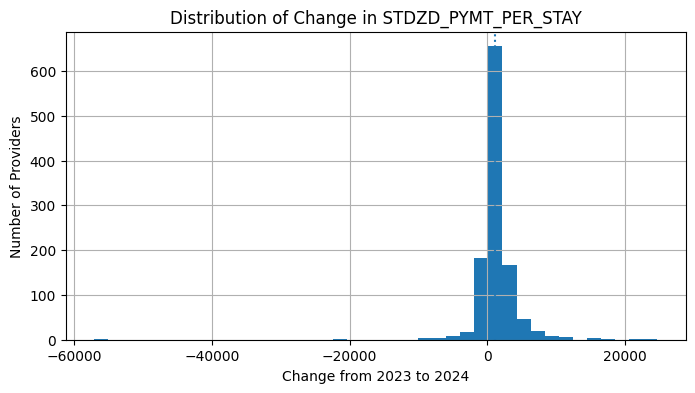

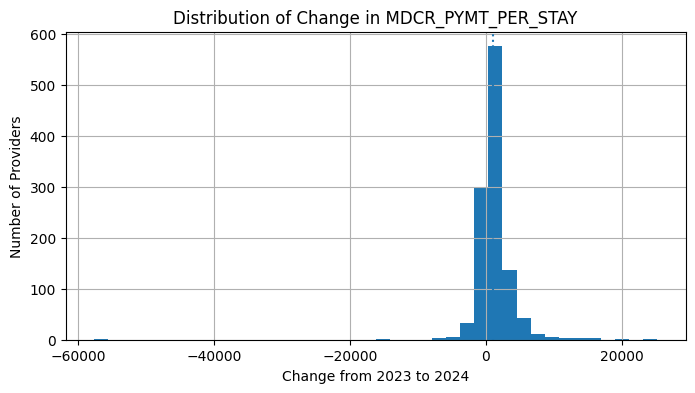

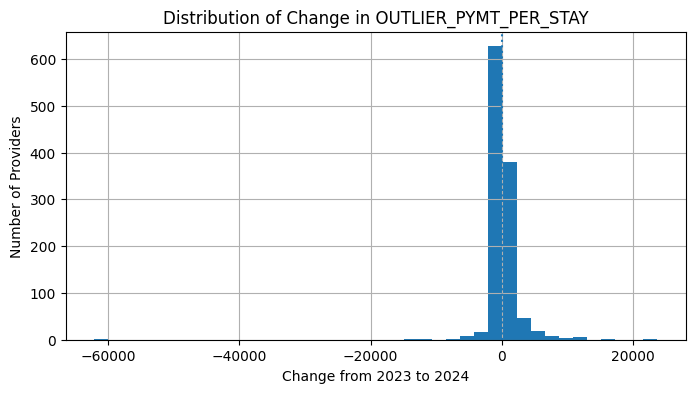

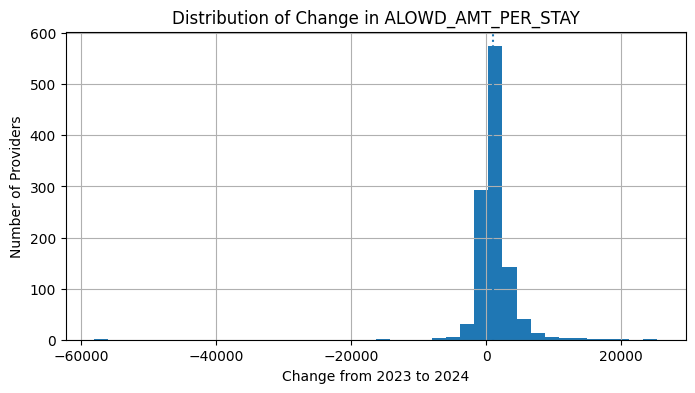

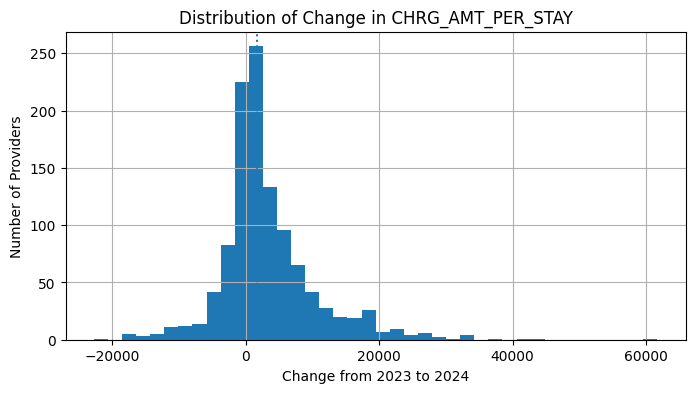

In [67]:
# Visualize payment change distributions

payment_change_vars = [
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY",
    "ALOWD_AMT_PER_STAY",
    "CHRG_AMT_PER_STAY"
]

for variable in payment_change_vars:
    plt.figure(figsize=(8, 4))

    df_change[(variable, "CHANGE")].dropna().hist(
        bins=40
    )

    plt.axvline(
        df_change[(variable, "CHANGE")].median(),
        linestyle=":"
    )

    plt.title(f"Distribution of Change in {variable}")
    plt.xlabel("Change from 2023 to 2024")
    plt.ylabel("Number of Providers")
    plt.show()

In [68]:
# Measure skewness of the payment change distributions

payment_skewness = {}

for variable in payment_change_vars:
    payment_skewness[variable] = (
        df_change[(variable, "CHANGE")]
        .dropna()
        .skew()
    )

payment_skewness = pd.Series(
    payment_skewness,
    name="Skewness"
).sort_values(ascending=False)

display(payment_skewness.round(2))

CHRG_AMT_PER_STAY        1.56
STDZD_PYMT_PER_STAY     -5.19
ALOWD_AMT_PER_STAY      -5.19
MDCR_PYMT_PER_STAY      -5.20
OUTLIER_PYMT_PER_STAY   -8.44
Name: Skewness, dtype: float64

### Distribution Assessment for Payment Changes

Payment change distributions were evaluated before selecting an anomaly detection method.

The distributions for standardized payment, Medicare payment, allowed amount, and outlier payment showed substantial negative skewness, with skewness magnitudes greater than 5. Outlier payment showed the strongest skewness with a magnitude of 8.44. Charge amount showed moderate positive skewness at 1.56.

These results confirm that several payment change distributions contain substantial asymmetry and extreme observations. Because the mean and standard deviation may be strongly influenced by these values, a robust approach based on the median and Median Absolute Deviation (MAD) will be used to evaluate unusual provider changes.

An unusual statistical change will be treated as a signal for further investigation and not as evidence of fraud.

In [69]:
# Calculate median and MAD for each payment change variable

mad_summary = []

for variable in payment_change_vars:
    values = df_change[(variable, "CHANGE")].dropna()

    median = values.median()
    mad = (values - median).abs().median()

    mad_summary.append({
        "Variable": variable,
        "Median_Change": median,
        "MAD": mad,
        "Providers": len(values)
    })

mad_summary = pd.DataFrame(mad_summary)

display(mad_summary.round(2))

,Variable,Median_Change,MAD,Providers
0,STDZD_PYMT_PER_STAY,1115.01,803.62,1123
1,MDCR_PYMT_PER_STAY,1004.47,885.98,1123
2,OUTLIER_PYMT_PER_STAY,48.74,197.31,1123
3,ALOWD_AMT_PER_STAY,1019.00,912.12,1123
4,CHRG_AMT_PER_STAY,1653.04,2809.66,1123


In [70]:
# modified Z scores for payment changes 

for variable in payment_change_vars:
    values = df_change[(variable, "CHANGE")]

    median = values.median()
    mad = (values - median).abs().median()

    df_change[(variable, "MODIFIED_Z")] = (
        0.6745 * (values - median) / mad
    )

print("Modified Z scores calculated for:",
      len(payment_change_vars), "payment variables")

# Preview the scores
z_preview = pd.DataFrame({
    variable: df_change[(variable, "MODIFIED_Z")]
    for variable in payment_change_vars
})

display(z_preview.head().round(2))

Modified Z scores calculated for: 5 payment variables


,STDZD_PYMT_PER_STAY,MDCR_PYMT_PER_STAY,OUTLIER_PYMT_PER_STAY,ALOWD_AMT_PER_STAY,CHRG_AMT_PER_STAY
PRVDR_ID,,,,,
010011,0.49,-0.17,-1.12,0.14,-1.37
010033,-0.46,-0.12,-1.00,-0.25,-1.11
010092,1.96,2.16,0.82,2.00,0.34
010100,4.29,3.43,12.89,3.33,2.55
010104,-0.63,-0.71,-0.95,-0.82,0.46


In [71]:
# Summarize modified Z score distributions

z_summary = []

for variable in payment_change_vars:
    scores = df_change[(variable, "MODIFIED_Z")].dropna()

    z_summary.append({
        "Variable": variable,
        "Count": len(scores),
        "Median": scores.median(),
        "Min": scores.min(),
        "Max": scores.max(),
        "Abs_Max": scores.abs().max()
    })

z_summary = pd.DataFrame(z_summary)

display(z_summary.round(2))

,Variable,Count,Median,Min,Max,Abs_Max
0,STDZD_PYMT_PER_STAY,1123,0.0,-48.90,19.82,48.90
1,MDCR_PYMT_PER_STAY,1123,0.0,-44.72,18.48,44.72
2,OUTLIER_PYMT_PER_STAY,1123,0.0,-212.79,81.02,212.79
3,ALOWD_AMT_PER_STAY,1123,0.0,-43.72,18.02,43.72
4,CHRG_AMT_PER_STAY,1123,0.0,-5.86,14.41,14.41


In [72]:
# Evaluate anomaly counts using an absolute modified Z score of 3.5

threshold = 3.5

flag_summary = []

for variable in payment_change_vars:
    scores = df_change[(variable, "MODIFIED_Z")]

    flagged = scores.abs() > threshold

    flag_summary.append({
        "Variable": variable,
        "Providers_Evaluated": scores.notna().sum(),
        "Providers_Flagged": flagged.sum(),
        "Percent_Flagged": flagged.mean() * 100
    })

flag_summary = pd.DataFrame(flag_summary)

display(flag_summary.round(2))

,Variable,Providers_Evaluated,Providers_Flagged,Percent_Flagged
0,STDZD_PYMT_PER_STAY,1123,81,7.21
1,MDCR_PYMT_PER_STAY,1123,61,5.43
2,OUTLIER_PYMT_PER_STAY,1123,203,18.08
3,ALOWD_AMT_PER_STAY,1123,59,5.25
4,CHRG_AMT_PER_STAY,1123,83,7.39


In [73]:
# Count how many payment variables flag each provider

threshold = 3.5

flag_columns = []

for variable in payment_change_vars:
    flag_name = (variable, "FLAG")

    df_change[flag_name] = (
        df_change[(variable, "MODIFIED_Z")].abs() > threshold
    )

    flag_columns.append(flag_name)

df_change["PAYMENT_FLAG_COUNT"] = (
    df_change[flag_columns]
    .sum(axis=1)
)

print("Number of payment variables flagging each provider:")
print(
    df_change["PAYMENT_FLAG_COUNT"]
    .value_counts()
    .sort_index()
)

Number of payment variables flagging each provider:
PAYMENT_FLAG_COUNT
0    867
1    159
2     33
3     12
4     34
5     18
Name: count, dtype: int64


In [74]:
# Why? Examine combinations of payment flags

flag_pattern = pd.DataFrame(index=df_change.index)

for variable in payment_change_vars:
    flag_pattern[variable] = df_change[(variable, "FLAG")]

flag_pattern["FLAG_COUNT"] = df_change["PAYMENT_FLAG_COUNT"]

multi_flag = flag_pattern[
    flag_pattern["FLAG_COUNT"] >= 3
].copy()

print("Providers flagged by at least 3 payment variables:",
      len(multi_flag))

print("\nFlag frequency within these providers:")

display(
    multi_flag[payment_change_vars]
    .sum()
    .sort_values(ascending=False)
    .to_frame("Providers_Flagged")
)

Providers flagged by at least 3 payment variables: 64

Flag frequency within these providers:


,Providers_Flagged
OUTLIER_PYMT_PER_STAY,60
STDZD_PYMT_PER_STAY,59
ALOWD_AMT_PER_STAY,58
MDCR_PYMT_PER_STAY,57
CHRG_AMT_PER_STAY,28


In [75]:
# Count the exact combinations of payment flags

flag_combinations = (
    multi_flag[payment_change_vars]
    .value_counts()
    .reset_index(name="Provider_Count")
)

display(flag_combinations)

,STDZD_PYMT_PER_STAY,MDCR_PYMT_PER_STAY,OUTLIER_PYMT_PER_STAY,ALOWD_AMT_PER_STAY,CHRG_AMT_PER_STAY,Provider_Count
0,True,True,True,True,False,30
1,True,True,True,True,True,18
2,True,True,False,True,False,3
3,True,False,True,False,True,3
4,True,True,True,False,False,3
5,False,False,True,True,True,2
6,False,True,True,True,True,2
7,True,False,True,True,True,2
8,False,True,False,True,True,1


In [76]:
# Find relevant dataframes currently in memory

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        if "change" in name.lower() or "temporal" in name.lower():
            print(name, obj.shape)

df_temporal (2317, 100)
df_change (1123, 41)
change_summary (10, 5)
df_2023_temporal (1152, 82)
df_2024_temporal (1165, 82)
df_temporal_final (2317, 82)
df_matched_temporal (2246, 82)
change_distribution (10, 4)


In [77]:
print("Column levels:", df_change.columns.nlevels)
print("\nExact columns:")
print(df_change.columns.tolist())

Column levels: 2

Exact columns:
[('TOT_EPSD_STAY_CNT', 2023), ('TOT_EPSD_STAY_CNT', 2024), ('TOT_EPSD_STAY_CNT', 'CHANGE'), ('AVG_SRVC_DAYS_PER_STAY', 2023), ('AVG_SRVC_DAYS_PER_STAY', 2024), ('AVG_SRVC_DAYS_PER_STAY', 'CHANGE'), ('STDZD_PYMT_PER_STAY', 2023), ('STDZD_PYMT_PER_STAY', 2024), ('STDZD_PYMT_PER_STAY', 'CHANGE'), ('MDCR_PYMT_PER_STAY', 2023), ('MDCR_PYMT_PER_STAY', 2024), ('MDCR_PYMT_PER_STAY', 'CHANGE'), ('OUTLIER_PYMT_PER_STAY', 2023), ('OUTLIER_PYMT_PER_STAY', 2024), ('OUTLIER_PYMT_PER_STAY', 'CHANGE'), ('ALOWD_AMT_PER_STAY', 2023), ('ALOWD_AMT_PER_STAY', 2024), ('ALOWD_AMT_PER_STAY', 'CHANGE'), ('CHRG_AMT_PER_STAY', 2023), ('CHRG_AMT_PER_STAY', 2024), ('CHRG_AMT_PER_STAY', 'CHANGE'), ('PT_MNTS_PER_STAY', 2023), ('PT_MNTS_PER_STAY', 2024), ('PT_MNTS_PER_STAY', 'CHANGE'), ('OT_MNTS_PER_STAY', 2023), ('OT_MNTS_PER_STAY', 2024), ('OT_MNTS_PER_STAY', 'CHANGE'), ('SLP_MNTS_PER_STAY', 2023), ('SLP_MNTS_PER_STAY', 2024), ('SLP_MNTS_PER_STAY', 'CHANGE'), ('STDZD_PYMT_PER_STAY',

In [78]:
# Keep only providers flagged on at least 3 payment variables

provider_review = df_change[
    df_change[("PAYMENT_FLAG_COUNT", "")] >= 3
].copy()

print("Providers in review table:", len(provider_review))

print("\nPayment flag counts:")
print(
    provider_review[("PAYMENT_FLAG_COUNT", "")]
    .value_counts()
    .sort_index()
)

display(provider_review.head())

Providers in review table: 64

Payment flag counts:
(PAYMENT_FLAG_COUNT, )
3    12
4    34
5    18
Name: count, dtype: int64


TOT_EPSD_STAY_CNT               AVG_SRVC_DAYS_PER_STAY             \
YEAR                  2023   2024 CHANGE                   2023       2024   
PRVDR_ID                                                                     
050026                55.0   73.0   18.0              14.490909  16.000000   
050100                79.0   69.0  -10.0              14.784810  16.217391   
050103               112.0   85.0  -27.0              11.705357  11.552941   
050135               189.0  135.0  -54.0              11.492063  11.429630   
050152                68.0   54.0  -14.0              14.514706  15.333333   

                   STDZD_PYMT_PER_STAY                             \
YEAR        CHANGE                2023          2024       CHANGE   
PRVDR_ID                                                            
050026    1.509091        35589.872727  45473.452055  9883.579328   
050100    1.432581        30219.936709  34536.000000  4316.063291   
050103   -0.152416        23758.294643  27694.188235  3935.893592   
050135   -0.062434        22548.804233  28059.000000  5510.195767   
050152    0.818627        29083.955882  39046.277778  9962.321895   

         MDCR_PYMT_PER_STAY  ...            OUTLIER_PYMT_PER_STAY  \
YEAR                   2023  ... MODIFIED_Z            MODIFIED_Z   
PRVDR_ID                     ...                                    
050026         43242.618182  ...   8.525336             23.847748   
050100         37060.164557  ...   3.468611              4.867273   
050103         32286.973214  ...   3.463595              8.120266   
050135         30354.116402  ...   3.174621             15.285187   
050152         49613.279412  ...  11.710270             56.415362   

         ALOWD_AMT_PER_STAY CHRG_AMT_PER_STAY STDZD_PYMT_PER_STAY  \
YEAR             MODIFIED_Z        MODIFIED_Z                FLAG   
PRVDR_ID                                                            
050026             8.325248          5.369664                True   
050100             3.640743          5.817467               False   
050103             3.540539          4.912361               False   
050135             2.677490          6.062336                True   
050152            12.067586          8.783753                True   

         MDCR_PYMT_PER_STAY OUTLIER_PYMT_PER_STAY ALOWD_AMT_PER_STAY  \
YEAR                   FLAG                  FLAG               FLAG   
PRVDR_ID                                                               
050026                 True                  True               True   
050100                False                  True               True   
050103                False                  True               True   
050135                False                  True              False   
050152                 True                  True               True   

         CHRG_AMT_PER_STAY PAYMENT_FLAG_COUNT  
YEAR                  FLAG                     
PRVDR_ID                                       
050026                True                  5  
050100                True                  3  
050103                True                  3  
050135                True                  3  
050152                True                  5  

[5 rows x 41 columns]

In [79]:
print(df_2024_matched.columns.tolist())

['PRVDR_ID', 'PRVDR_NAME', 'PRVDR_CITY', 'STATE', 'PRVDR_ZIP', 'BENE_DSTNCT_CNT', 'TOT_EPSD_STAY_CNT', 'TOT_SRVC_DAYS', 'TOT_CHRG_AMT', 'TOT_ALOWD_AMT', 'TOT_MDCR_PYMT_AMT', 'TOT_MDCR_STDZD_PYMT_AMT', 'TOT_OUTLIER_PYMT_AMT', 'BENE_DUAL_PCT', 'BENE_RRL_PCT', 'BENE_AVG_AGE', 'BENE_MALE_PCT', 'BENE_FEML_PCT', 'BENE_RACE_WHT_PCT', 'BENE_RACE_BLACK_PCT', 'BENE_RACE_HSPNC_PCT', 'BENE_RACE_NATIND_PCT', 'BENE_AVG_RISK_SCRE', 'BENE_CC_BH_ALCOHOL_DRUG_V1_PCT', 'BENE_CC_BH_ALZ_NONALZDEM_V2_PCT', 'BENE_CC_BH_ANXIETY_V1_PCT', 'BENE_CC_BH_BIPOLAR_V1_PCT', 'BENE_CC_BH_DEPRESS_V1_PCT', 'BENE_CC_BH_MOOD_V2_PCT', 'BENE_CC_BH_TOBACCO_V1_PCT', 'BENE_CC_PH_AFIB_V2_PCT', 'BENE_CC_PH_ARTHRITIS_V2_PCT', 'BENE_CC_PH_ASTHMA_V2_PCT', 'BENE_CC_PH_CANCER6_V2_PCT', 'BENE_CC_PH_CKD_V2_PCT', 'BENE_CC_PH_COPD_V2_PCT', 'BENE_CC_PH_DIABETES_V2_PCT', 'BENE_CC_PH_HF_NONIHD_V2_PCT', 'BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT', 'BENE_CC_PH_HYPERTENSION_V2_PCT', 'BENE_CC_PH_ISCHEMICHEART_V2_PCT', 'BENE_CC_PH_OSTEOPOROSIS_V2_PCT', 'BE

In [80]:
# Flatten the review table columns

provider_review_flat = provider_review.copy()

provider_review_flat.columns = [
    "_".join(str(x) for x in col if str(x) != "")
    if isinstance(col, tuple)
    else str(col)
    for col in provider_review_flat.columns
]

print("Column levels:", provider_review_flat.columns.nlevels)
print("Shape:", provider_review_flat.shape)
print(provider_review_flat.columns.tolist())

Column levels: 1
Shape: (64, 41)
['TOT_EPSD_STAY_CNT_2023', 'TOT_EPSD_STAY_CNT_2024', 'TOT_EPSD_STAY_CNT_CHANGE', 'AVG_SRVC_DAYS_PER_STAY_2023', 'AVG_SRVC_DAYS_PER_STAY_2024', 'AVG_SRVC_DAYS_PER_STAY_CHANGE', 'STDZD_PYMT_PER_STAY_2023', 'STDZD_PYMT_PER_STAY_2024', 'STDZD_PYMT_PER_STAY_CHANGE', 'MDCR_PYMT_PER_STAY_2023', 'MDCR_PYMT_PER_STAY_2024', 'MDCR_PYMT_PER_STAY_CHANGE', 'OUTLIER_PYMT_PER_STAY_2023', 'OUTLIER_PYMT_PER_STAY_2024', 'OUTLIER_PYMT_PER_STAY_CHANGE', 'ALOWD_AMT_PER_STAY_2023', 'ALOWD_AMT_PER_STAY_2024', 'ALOWD_AMT_PER_STAY_CHANGE', 'CHRG_AMT_PER_STAY_2023', 'CHRG_AMT_PER_STAY_2024', 'CHRG_AMT_PER_STAY_CHANGE', 'PT_MNTS_PER_STAY_2023', 'PT_MNTS_PER_STAY_2024', 'PT_MNTS_PER_STAY_CHANGE', 'OT_MNTS_PER_STAY_2023', 'OT_MNTS_PER_STAY_2024', 'OT_MNTS_PER_STAY_CHANGE', 'SLP_MNTS_PER_STAY_2023', 'SLP_MNTS_PER_STAY_2024', 'SLP_MNTS_PER_STAY_CHANGE', 'STDZD_PYMT_PER_STAY_MODIFIED_Z', 'MDCR_PYMT_PER_STAY_MODIFIED_Z', 'OUTLIER_PYMT_PER_STAY_MODIFIED_Z', 'ALOWD_AMT_PER_STAY_MODIFIED_Z

In [81]:
# Add 2024 provider context to the review table

context_cols = [
    "PRVDR_NAME",
    "PRVDR_CITY",
    "STATE",
    "PRVDR_ZIP",
    "BENE_DSTNCT_CNT",
    "TOT_EPSD_STAY_CNT",
    "BENE_AVG_AGE",
    "BENE_AVG_RISK_SCRE",
    "BENE_RRL_PCT"
]

provider_context = (
    df_2024_matched
    .set_index("PRVDR_ID")[context_cols]
)

provider_review_final = provider_review_flat.join(
    provider_context,
    how="left"
)

print("Final review table shape:", provider_review_final.shape)
print("Providers:", len(provider_review_final))
print("Missing provider names:", provider_review_final["PRVDR_NAME"].isna().sum())

display(
    provider_review_final[
        [
            "PRVDR_NAME",
            "PRVDR_CITY",
            "STATE",
            "TOT_EPSD_STAY_CNT",
            "BENE_AVG_RISK_SCRE",
            "BENE_RRL_PCT",
            "PAYMENT_FLAG_COUNT"
        ]
    ].head(10)
)

Final review table shape: (64, 50)
Providers: 64
Missing provider names: 0


,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,BENE_RRL_PCT,PAYMENT_FLAG_COUNT
PRVDR_ID,,,,,,,
050026,Grossmont Hospital,La Mesa,CA,73,1.69,0.0,5
050100,Sharp Memorial Hospital,San Diego,CA,69,2.37,0.0,3
050103,Adventist Health White Memorial,Los Angeles,CA,85,3.75,0.0,3
050135,Southern California Hospital At Hollywood,Hollywood,CA,135,3.49,0.0,3
050152,Saint Francis Memorial Hospital,San Francisco,CA,54,2.39,NaN,5
050174,Providence Santa Rosa Memorial Hospital,Santa Rosa,CA,130,2.18,0.0,4
050180,John Muir Medical Center - Walnut Creek Campus,Walnut Creek,CA,231,1.80,NaN,4
050717,Lac/rancho Los Amigos National Rehabilitation ...,Downey,CA,127,2.27,0.0,5
053045,Sacramento Rehabilitation Hospital,Sacramento,CA,494,2.30,5.0,3


In [82]:
# Compare flagged providers with providers that were not flagged

flagged_ids = provider_review_final.index

comparison_2024 = df_2024_matched.copy()

comparison_2024["FLAGGED_PAYMENT_CHANGE"] = (
    comparison_2024["PRVDR_ID"].isin(flagged_ids)
)

comparison_vars = [
    "TOT_EPSD_STAY_CNT",
    "BENE_AVG_RISK_SCRE",
    "BENE_RRL_PCT",
    "BENE_AVG_AGE"
]

group_comparison = (
    comparison_2024
    .groupby("FLAGGED_PAYMENT_CHANGE")[comparison_vars]
    .agg(["count", "median", "mean"])
    .round(2)
)

print("Providers by group:")
print(comparison_2024["FLAGGED_PAYMENT_CHANGE"].value_counts())

display(group_comparison)

Providers by group:
FLAGGED_PAYMENT_CHANGE
False    1059
True       64
Name: count, dtype: int64


TOT_EPSD_STAY_CNT                BENE_AVG_RISK_SCRE  \
                                   count median    mean              count   
FLAGGED_PAYMENT_CHANGE                                                       
False                               1059  244.0  394.90               1059   
True                                  64  107.5  148.06                 64   

                                    BENE_RRL_PCT               BENE_AVG_AGE  \
                       median  mean        count median   mean        count   
FLAGGED_PAYMENT_CHANGE                                                        
False                    2.40  2.42          612    8.0  12.28         1059   
True                     2.31  2.40           32    0.0   7.62           64   

                                      
                       median   mean  
FLAGGED_PAYMENT_CHANGE                
False                    78.0  77.31  
True                     77.0  76.23

### Is the tendency toward larger payment changes related to provider volume, or are we just seeing a weird feature of those 64 flagged providers?

In [83]:
volume_change_check = pd.DataFrame({
    "Volume_2024": df_change[("TOT_EPSD_STAY_CNT", 2024)],
    "Standardized_Payment_Change": df_change[
        ("STDZD_PYMT_PER_STAY", "CHANGE")
    ],
    "Medicare_Payment_Change": df_change[
        ("MDCR_PYMT_PER_STAY", "CHANGE")
    ],
    "Outlier_Payment_Change": df_change[
        ("OUTLIER_PYMT_PER_STAY", "CHANGE")
    ]
})

print("Spearman correlations with 2024 provider volume:")

print(
    volume_change_check.corr(method="spearman")
    ["Volume_2024"]
    .round(3)
)

Spearman correlations with 2024 provider volume:
Volume_2024                    1.000
Standardized_Payment_Change   -0.164
Medicare_Payment_Change       -0.111
Outlier_Payment_Change        -0.207
Name: Volume_2024, dtype: float64


In [84]:
# Examine provider volume distribution before defining peer groups

volume_summary = (
    df_change[("TOT_EPSD_STAY_CNT", 2024)]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .round(2)
)

print("2024 provider volume distribution:")
print(volume_summary)

2024 provider volume distribution:
count    1123.00
mean      380.83
std       378.65
min        11.00
10%        75.20
25%       128.50
50%       231.00
75%       522.50
90%       900.80
max      3305.00
Name: (TOT_EPSD_STAY_CNT, 2024), dtype: float64


In [85]:
# Create volume peer groups using quartiles

volume_2024 = df_change[("TOT_EPSD_STAY_CNT", 2024)]

volume_peer_group = pd.qcut(
    volume_2024,
    q=4,
    labels=[
        "Volume Group 1",
        "Volume Group 2",
        "Volume Group 3",
        "Volume Group 4"
    ]
)

volume_peer_check = pd.DataFrame({
    "Volume_2024": volume_2024,
    "Volume_Peer_Group": volume_peer_group,
    "Flagged": volume_2024.index.isin(provider_review_final.index)
})

print("All providers:")
print(volume_peer_check["Volume_Peer_Group"].value_counts().sort_index())

print("\nFlagged providers:")
print(
    volume_peer_check.loc[
        volume_peer_check["Flagged"],
        "Volume_Peer_Group"
    ].value_counts().sort_index()
)

All providers:
Volume_Peer_Group
Volume Group 1    281
Volume Group 2    284
Volume Group 3    277
Volume Group 4    281
Name: count, dtype: int64

Flagged providers:
Volume_Peer_Group
Volume Group 1    37
Volume Group 2    14
Volume Group 3    11
Volume Group 4     2
Name: count, dtype: int64


In [86]:
# Calculate peer based modified Z scores for standardized payment change

peer_test = pd.DataFrame({
    "Volume_2024": volume_2024,
    "Volume_Peer_Group": volume_peer_group,
    "Payment_Change": df_change[
        ("STDZD_PYMT_PER_STAY", "CHANGE")
    ]
})

def modified_z_within_group(group):
    median = group["Payment_Change"].median()
    mad = (group["Payment_Change"] - median).abs().median()

    group = group.copy()

    group["Peer_Median"] = median
    group["Peer_MAD"] = mad

    if mad != 0:
        group["Peer_Modified_Z"] = (
            0.6745 *
            (group["Payment_Change"] - median) /
            mad
        )
    else:
        group["Peer_Modified_Z"] = np.nan

    return group

peer_test = (
    peer_test
    .groupby(
        "Volume_Peer_Group",
        observed=True,
        group_keys=False
    )
    .apply(modified_z_within_group)
)

peer_test["Peer_Flag"] = (
    peer_test["Peer_Modified_Z"].abs() > 3.5
)

peer_test.groupby(
    "Volume_Peer_Group",
    observed=True
).agg(
    Providers=("Payment_Change", "count"),
    Median_Change=("Peer_Median", "first"),
    MAD=("Peer_MAD", "first"),
    Providers_Flagged=("Peer_Flag", "sum")
).round(2)

/var/folders/0p/610xzzg53fs7t4n2cx68l17m0000gn/T/ipykernel_88350/2945832866.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(modified_z_within_group)


,Providers,Median_Change,MAD,Providers_Flagged
Volume_Peer_Group,,,,
Volume Group 1,281,1375.52,1379.68,20
Volume Group 2,284,1467.75,1068.97,9
Volume Group 3,277,1084.31,681.09,13
Volume Group 4,281,892.55,484.09,6


 ### Volume Based Peer Comparison

Initial temporal anomaly screening compared payment changes across all matched providers. Provider context analysis showed that flagged providers were disproportionately concentrated among lower volume facilities, suggesting that provider size may influence the variability of annual payment changes.

Providers were therefore divided into four volume based comparison groups using the quartiles of 2024 episode stay counts. Modified Z scores for standardized payment per stay change were then recalculated within each volume group.

The peer comparison identified 48 providers with unusual standardized payment changes, compared with 81 providers using the overall national distribution. This reduction suggests that provider volume explains part of the variability previously identified as unusual.

However, unusual values remained within every volume group. These providers may warrant additional review using other payment, utilization, therapy, and provider context variables.

Statistical flags represent unusual patterns relative to comparable providers and should not be interpreted as evidence of fraud.

In [87]:
# Calculate volume peer modified Z scores for all payment variables

payment_vars = [
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY",
    "ALOWD_AMT_PER_STAY",
    "CHRG_AMT_PER_STAY"
]

peer_results = pd.DataFrame(index=df_change.index)

peer_results["Volume_Peer_Group"] = volume_peer_group

peer_summary_rows = []

for var in payment_vars:

    payment_change = df_change[(var, "CHANGE")]

    for group in volume_peer_group.cat.categories:

        group_mask = volume_peer_group == group
        group_values = payment_change[group_mask]

        median = group_values.median()
        mad = (group_values - median).abs().median()

        if mad != 0:
            peer_z = 0.6745 * (group_values - median) / mad
        else:
            peer_z = pd.Series(
                np.nan,
                index=group_values.index
            )

        peer_results.loc[
            group_mask,
            var + "_PEER_Z"
        ] = peer_z

        peer_results.loc[
            group_mask,
            var + "_PEER_FLAG"
        ] = peer_z.abs() > 3.5

        peer_summary_rows.append({
            "Variable": var,
            "Volume_Group": group,
            "Providers": group_values.notna().sum(),
            "Median_Change": median,
            "MAD": mad,
            "Providers_Flagged": (peer_z.abs() > 3.5).sum()
        })

peer_summary = pd.DataFrame(peer_summary_rows)

display(
    peer_summary.round(2)
)

,Variable,Volume_Group,Providers,Median_Change,MAD,Providers_Flagged
0,STDZD_PYMT_PER_STAY,Volume Group 1,281,1375.52,1379.68,20
1,STDZD_PYMT_PER_STAY,Volume Group 2,284,1467.75,1068.97,9
2,STDZD_PYMT_PER_STAY,Volume Group 3,277,1084.31,681.09,13
3,STDZD_PYMT_PER_STAY,Volume Group 4,281,892.55,484.09,6
4,MDCR_PYMT_PER_STAY,Volume Group 1,281,1090.89,1420.58,17
5,MDCR_PYMT_PER_STAY,Volume Group 2,284,1279.68,1046.36,5
6,MDCR_PYMT_PER_STAY,Volume Group 3,277,1007.40,801.94,12
7,MDCR_PYMT_PER_STAY,Volume Group 4,281,779.27,556.40,6
8,OUTLIER_PYMT_PER_STAY,Volume Group 1,281,213.95,494.73,46
9,OUTLIER_PYMT_PER_STAY,Volume Group 2,284,168.87,334.72,44


In [88]:
# Count peer adjusted payment flags for each provider

peer_flag_cols = [
    var + "_PEER_FLAG"
    for var in payment_vars
]

peer_results["PEER_PAYMENT_FLAG_COUNT"] = (
    peer_results[peer_flag_cols]
    .fillna(False)
    .sum(axis=1)
)

print("Number of peer adjusted payment variables flagging each provider:")
print(
    peer_results["PEER_PAYMENT_FLAG_COUNT"]
    .value_counts()
    .sort_index()
)

print(
    "\nProviders flagged by at least 3 peer adjusted payment variables:",
    (peer_results["PEER_PAYMENT_FLAG_COUNT"] >= 3).sum()
)

Number of peer adjusted payment variables flagging each provider:
PEER_PAYMENT_FLAG_COUNT
0    904
1    142
2     37
3     10
4     20
5     10
Name: count, dtype: int64

Providers flagged by at least 3 peer adjusted payment variables: 40


/var/folders/0p/610xzzg53fs7t4n2cx68l17m0000gn/T/ipykernel_88350/2718896346.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [89]:
# compare old to new 

global_flagged = set(
    df_change.index[
        df_change[("PAYMENT_FLAG_COUNT", "")] >= 3
    ]
)

peer_flagged = set(
    peer_results.index[
        peer_results["PEER_PAYMENT_FLAG_COUNT"] >= 3
    ]
)

both = global_flagged & peer_flagged
global_only = global_flagged - peer_flagged
peer_only = peer_flagged - global_flagged

print("Flagged by original global method:", len(global_flagged))
print("Flagged after volume peer adjustment:", len(peer_flagged))
print("Flagged by BOTH methods:", len(both))
print("Global method ONLY:", len(global_only))
print("Peer-adjusted method ONLY:", len(peer_only))

Flagged by original global method: 64
Flagged after volume peer adjustment: 40
Flagged by BOTH methods: 37
Global method ONLY: 27
Peer-adjusted method ONLY: 3


In [90]:
# Inspect providers detected only after volume peer adjustment

peer_only_review = peer_results.loc[
    list(peer_only),
    [
        "Volume_Peer_Group",
        "PEER_PAYMENT_FLAG_COUNT"
    ] + peer_flag_cols
].copy()

# Add provider context from 2024
context_cols = [
    "PRVDR_NAME",
    "PRVDR_CITY",
    "STATE",
    "TOT_EPSD_STAY_CNT",
    "BENE_AVG_RISK_SCRE",
    "BENE_RRL_PCT"
]

context_2024 = (
    df_2024_matched
    .set_index("PRVDR_ID")[context_cols]
)

peer_only_review = context_2024.join(
    peer_only_review,
    how="inner"
)

display(peer_only_review)

,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,BENE_RRL_PCT,Volume_Peer_Group,PEER_PAYMENT_FLAG_COUNT,STDZD_PYMT_PER_STAY_PEER_FLAG,MDCR_PYMT_PER_STAY_PEER_FLAG,OUTLIER_PYMT_PER_STAY_PEER_FLAG,ALOWD_AMT_PER_STAY_PEER_FLAG,CHRG_AMT_PER_STAY_PEER_FLAG
PRVDR_ID,,,,,,,,,,,,,
033038,"Globalrehab - Scottsdale, Llc",Scottsdale,AZ,626,2.06,NaN,Volume Group 4,3,False,True,False,True,True
053044,Bakersfield Rehabilitation Hospital,Bakersfield,CA,583,2.84,NaN,Volume Group 4,5,True,True,True,True,True
140258,Alexian Brothers Medical Center 1,Elk Grove Village,IL,644,2.82,NaN,Volume Group 4,4,True,True,True,True,False


In [91]:
# Show exactly which payment variables flagged the 3 peer only providers

peer_only_flags = peer_results.loc[
    list(peer_only),
    ["Volume_Peer_Group", "PEER_PAYMENT_FLAG_COUNT"] + peer_flag_cols
].copy()

display(peer_only_flags)

,Volume_Peer_Group,PEER_PAYMENT_FLAG_COUNT,STDZD_PYMT_PER_STAY_PEER_FLAG,MDCR_PYMT_PER_STAY_PEER_FLAG,OUTLIER_PYMT_PER_STAY_PEER_FLAG,ALOWD_AMT_PER_STAY_PEER_FLAG,CHRG_AMT_PER_STAY_PEER_FLAG
PRVDR_ID,,,,,,,
033038,Volume Group 4,3,False,True,False,True,True
140258,Volume Group 4,4,True,True,True,True,False
053044,Volume Group 4,5,True,True,True,True,True


### Volume Based Peer Adjustment of Payment Changes

Provider volume was evaluated as a potential source of variation in year to year payment changes. Providers were divided into four approximately equal volume based peer groups using 2024 episode/stay counts, and modified Z-scores were recalculated within each peer group.

The peer adjusted analysis changed the anomaly screening results:

- The original global analysis identified 64 providers flagged on at least 3 of 5 payment variables.
- After adjustment for provider volume, 40 providers were flagged on at least 3 payment variables.
- 37 providers were identified by both approaches.
- 27 providers identified by the global method were no longer flagged after peer adjustment.
- 3 providers were identified only after comparison with similar volume providers.
- All 3 peer-only providers belonged to the highest volume peer group.

These findings suggest that provider volume influences the distribution of payment changes and that a single population wide comparison may over identify some providers while masking unusual behavior within specific provider volume groups.

Volume based peer adjustment therefore provides a more contextual screening approach. Providers identified through this process represent candidates for additional review rather than evidence of Fraud, Waste, or Abuse (FWA).

In [92]:
# Test relationship between 2024 beneficiary risk score and year to year payment changes

risk_test = pd.DataFrame({
    "Risk_Score_2024": df_change.index.map(
        df_2024_matched.set_index("PRVDR_ID")["BENE_AVG_RISK_SCRE"]
    )
}, index=df_change.index)

for var in payment_vars:
    risk_test[var + "_CHANGE"] = df_change[(var, "CHANGE")]

risk_correlations = risk_test.corr(
    method="spearman"
)["Risk_Score_2024"].sort_values(ascending=False)

print("Spearman correlations with 2024 beneficiary risk score:")
print(risk_correlations.round(3))

Spearman correlations with 2024 beneficiary risk score:
Risk_Score_2024                 1.000
ALOWD_AMT_PER_STAY_CHANGE       0.007
MDCR_PYMT_PER_STAY_CHANGE       0.006
CHRG_AMT_PER_STAY_CHANGE       -0.002
STDZD_PYMT_PER_STAY_CHANGE     -0.013
OUTLIER_PYMT_PER_STAY_CHANGE   -0.029
Name: Risk_Score_2024, dtype: float64


### Beneficiary Risk Score and Payment Change

Beneficiary average risk score was evaluated as a potential contextual factor for year to year payment changes.

Spearman correlations between 2024 beneficiary risk score and the five payment change measures ranged from approximately -0.03 to 0.01, indicating essentially no monotonic relationship.

Based on this result, beneficiary risk score was not used to create additional peer groups for the current temporal payment change analysis. Risk score will remain available as contextual information when reviewing individual providers.

In [93]:
# Test relationship between 2024 therapy utilization and year to year payment changes

therapy_test = pd.DataFrame({
    "PT_MNTS_PER_STAY_2024": df_change[("PT_MNTS_PER_STAY", 2024)],
    "OT_MNTS_PER_STAY_2024": df_change[("OT_MNTS_PER_STAY", 2024)],
    "SLP_MNTS_PER_STAY_2024": df_change[("SLP_MNTS_PER_STAY", 2024)]
})

for var in payment_vars:
    therapy_test[var + "_CHANGE"] = df_change[(var, "CHANGE")]

therapy_correlations = therapy_test.corr(method="spearman").loc[
    [
        "PT_MNTS_PER_STAY_2024",
        "OT_MNTS_PER_STAY_2024",
        "SLP_MNTS_PER_STAY_2024"
    ],
    [var + "_CHANGE" for var in payment_vars]
]

print("Spearman correlations between 2024 therapy utilization")
print("and year to year payment changes:")

display(therapy_correlations.round(3))

Spearman correlations between 2024 therapy utilization
and year to year payment changes:


,STDZD_PYMT_PER_STAY_CHANGE,MDCR_PYMT_PER_STAY_CHANGE,OUTLIER_PYMT_PER_STAY_CHANGE,ALOWD_AMT_PER_STAY_CHANGE,CHRG_AMT_PER_STAY_CHANGE
PT_MNTS_PER_STAY_2024,0.018,-0.011,-0.042,-0.010,-0.014
OT_MNTS_PER_STAY_2024,0.023,-0.001,-0.047,-0.002,-0.016
SLP_MNTS_PER_STAY_2024,0.031,0.024,0.036,0.021,-0.047


### Therapy Utilization and Payment Change

Therapy utilization was evaluated as another potential factor for defining provider peer groups.

Spearman correlations were calculated between 2024 PT, OT, and SLP minutes per stay and the five year to year payment change measures. All correlations were very small, with absolute values below approximately 0.05.

These results do not indicate a meaningful relationship between therapy minutes per stay and year to year payment changes in the current dataset.

Therefore, therapy utilization was not used to create additional peer groups for the current temporal payment-change analysis. Therapy variables will remain available as contextual information for later provider level review.

Together with the beneficiary risk score analysis, these results support retaining provider volume as the primary peer group adjustment identified so far.

In [94]:
# Create base table for peer adjusted anomaly candidates

candidate_ids = peer_results.index[
    peer_results["PEER_PAYMENT_FLAG_COUNT"] >= 3
]

candidate_context_cols = [
    "PRVDR_ID",
    "PRVDR_NAME",
    "PRVDR_CITY",
    "STATE",
    "PRVDR_ZIP",
    "TOT_EPSD_STAY_CNT",
    "BENE_AVG_RISK_SCRE",
    "BENE_RRL_PCT"
]

candidate_table = (
    df_2024_matched[
        df_2024_matched["PRVDR_ID"].isin(candidate_ids)
    ][candidate_context_cols]
    .copy()
    .set_index("PRVDR_ID")
)

# Add volume peer group and number of peer adjusted payment flags
candidate_table["VOLUME_PEER_GROUP"] = peer_results.loc[
    candidate_table.index, "Volume_Peer_Group"
]

candidate_table["PEER_PAYMENT_FLAG_COUNT"] = peer_results.loc[
    candidate_table.index, "PEER_PAYMENT_FLAG_COUNT"
]

print("Candidate table shape:", candidate_table.shape)
print("Unique providers:", candidate_table.index.nunique())
print()
display(candidate_table.head(10))

Candidate table shape: (40, 9)
Unique providers: 40



,PRVDR_NAME,PRVDR_CITY,STATE,PRVDR_ZIP,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,BENE_RRL_PCT,VOLUME_PEER_GROUP,PEER_PAYMENT_FLAG_COUNT
PRVDR_ID,,,,,,,,,
033038,"Globalrehab - Scottsdale, Llc",Scottsdale,AZ,85258,626,2.06,NaN,Volume Group 4,3
050026,Grossmont Hospital,La Mesa,CA,91942,73,1.69,0.0,Volume Group 1,4
050152,Saint Francis Memorial Hospital,San Francisco,CA,94109,54,2.39,NaN,Volume Group 1,5
050180,John Muir Medical Center - Walnut Creek Campus,Walnut Creek,CA,94598,231,1.80,NaN,Volume Group 2,3
050717,Lac/rancho Los Amigos National Rehabilitation ...,Downey,CA,90242,127,2.27,0.0,Volume Group 1,5
053044,Bakersfield Rehabilitation Hospital,Bakersfield,CA,93306,583,2.84,NaN,Volume Group 4,5
053045,Sacramento Rehabilitation Hospital,Sacramento,CA,95834,494,2.30,5.0,Volume Group 3,3
060112,Hca Healthone Sky Ridge,Lone Tree,CO,80124,245,2.37,5.0,Volume Group 3,4
070007,Lawrence & Memorial Hospital,New London,CT,06320,62,2.39,0.0,Volume Group 1,5


In [95]:
# Add payment history, change, peer adjusted Z scores, and flags to the 40 provider candidate table

for var in payment_vars:
    
    # Actual 2023 and 2024 values
    candidate_table[var + "_2023"] = df_change.loc[
        candidate_table.index, (var, 2023)
    ]
    
    candidate_table[var + "_2024"] = df_change.loc[
        candidate_table.index, (var, 2024)
    ]
  
    candidate_table[var + "_CHANGE"] = df_change.loc[
        candidate_table.index, (var, "CHANGE")
    ]
    
    candidate_table[var + "_PEER_Z"] = peer_results.loc[
        candidate_table.index, var + "_PEER_Z"
    ]
    
    candidate_table[var + "_PEER_FLAG"] = peer_results.loc[
        candidate_table.index, var + "_PEER_FLAG"
    ]

print("Updated candidate table shape:", candidate_table.shape)
print("Unique providers:", candidate_table.index.nunique())
print()

display(candidate_table.head())

Updated candidate table shape: (40, 34)
Unique providers: 40



,PRVDR_NAME,PRVDR_CITY,STATE,PRVDR_ZIP,TOT_EPSD_STAY_CNT,BENE_AVG_RISK_SCRE,BENE_RRL_PCT,VOLUME_PEER_GROUP,PEER_PAYMENT_FLAG_COUNT,STDZD_PYMT_PER_STAY_2023,...,ALOWD_AMT_PER_STAY_2023,ALOWD_AMT_PER_STAY_2024,ALOWD_AMT_PER_STAY_CHANGE,ALOWD_AMT_PER_STAY_PEER_Z,ALOWD_AMT_PER_STAY_PEER_FLAG,CHRG_AMT_PER_STAY_2023,CHRG_AMT_PER_STAY_2024,CHRG_AMT_PER_STAY_CHANGE,CHRG_AMT_PER_STAY_PEER_Z,CHRG_AMT_PER_STAY_PEER_FLAG
PRVDR_ID,,,,,,,,,,,,,,,,,,,,,
033038,"Globalrehab - Scottsdale, Llc",Scottsdale,AZ,85258,626,2.06,NaN,Volume Group 4,3,20991.059968,...,22439.614263,26319.498403,3879.884140,3.634479,True,81835.653160,108329.955272,26494.302111,15.922784,True
050026,Grossmont Hospital,La Mesa,CA,91942,73,1.69,0.0,Volume Group 1,4,35589.872727,...,43329.890909,55607.041096,12277.150187,5.090835,True,138549.927273,162570.534247,24020.606974,3.076585,False
050152,Saint Francis Memorial Hospital,San Francisco,CA,94109,54,2.39,NaN,Volume Group 1,5,29083.955882,...,50236.808824,67574.685185,17337.876362,7.418288,True,160431.470588,198673.611111,38242.140523,5.159846,True
050180,John Muir Medical Center - Walnut Creek Campus,Walnut Creek,CA,94598,231,1.80,NaN,Volume Group 2,3,23227.208145,...,39153.013575,49146.493506,9993.479932,5.626640,True,182567.447964,195218.835498,12651.387534,1.856441,False
050717,Lac/rancho Los Amigos National Rehabilitation ...,Downey,CA,90242,127,2.27,0.0,Volume Group 1,5,43867.730159,...,55194.738095,69004.354331,13809.616235,5.795623,True,190628.492063,232760.787402,42132.295338,5.729701,True


In [96]:
# Find the largest peer adjusted Z score for each provider

peer_z_cols = [
    var + "_PEER_Z"
    for var in payment_vars
]

candidate_table["MAX_ABS_PEER_Z"] = (
    candidate_table[peer_z_cols]
    .abs()
    .max(axis=1)
)

candidate_ranked = candidate_table.sort_values(
    by=["PEER_PAYMENT_FLAG_COUNT", "MAX_ABS_PEER_Z"],
    ascending=[False, False]
)

print("Candidate ranking shape:", candidate_ranked.shape)

print("\nProviders by number of peer-adjusted payment flags:")
print(
    candidate_ranked["PEER_PAYMENT_FLAG_COUNT"]
    .value_counts()
    .sort_index(ascending=False)
)

display(
    candidate_ranked[
        [
            "PRVDR_NAME",
            "PRVDR_CITY",
            "STATE",
            "TOT_EPSD_STAY_CNT",
            "VOLUME_PEER_GROUP",
            "PEER_PAYMENT_FLAG_COUNT",
            "MAX_ABS_PEER_Z"
        ]
    ].head(10)
)

Candidate ranking shape: (40, 35)

Providers by number of peer-adjusted payment flags:
PEER_PAYMENT_FLAG_COUNT
5    10
4    20
3    10
Name: count, dtype: int64


,PRVDR_NAME,PRVDR_CITY,STATE,TOT_EPSD_STAY_CNT,VOLUME_PEER_GROUP,PEER_PAYMENT_FLAG_COUNT,MAX_ABS_PEER_Z
PRVDR_ID,,,,,,,
100080,Hca Florida Jfk Hospital,Atlantis,FL,269,Volume Group 3,5,51.961897
053044,Bakersfield Rehabilitation Hospital,Bakersfield,CA,583,Volume Group 4,5,45.301616
393038,Magee Rehabilitation Hospital,Philadelphia,PA,310,Volume Group 3,5,26.415063
100242,Hca Florida Gulf Coast Hospital,Panama City,FL,238,Volume Group 3,5,25.684723
050152,Saint Francis Memorial Hospital,San Francisco,CA,54,Volume Group 1,5,22.274880
050717,Lac/rancho Los Amigos National Rehabilitation ...,Downey,CA,127,Volume Group 1,5,17.393255
070007,Lawrence & Memorial Hospital,New London,CT,62,Volume Group 1,5,16.827403
450271,Medical City Decatur,Decatur,TX,104,Volume Group 1,5,13.845350
450711,Rio Grande Regional Hospital,Mcallen,TX,71,Volume Group 1,5,9.274817


In [97]:
# Review actual payment changes for the 10 providers flagged across all 5 peer adjusted payment variables

top_candidates = candidate_ranked[
    candidate_ranked["PEER_PAYMENT_FLAG_COUNT"] == 5
].copy()

review_cols = [
    "PRVDR_NAME",
    "STATE",
    "TOT_EPSD_STAY_CNT",
    "VOLUME_PEER_GROUP",
    "PEER_PAYMENT_FLAG_COUNT",
    "MAX_ABS_PEER_Z",
    
    "STDZD_PYMT_PER_STAY_2023",
    "STDZD_PYMT_PER_STAY_2024",
    "STDZD_PYMT_PER_STAY_CHANGE",
    
    "MDCR_PYMT_PER_STAY_2023",
    "MDCR_PYMT_PER_STAY_2024",
    "MDCR_PYMT_PER_STAY_CHANGE",
    
    "OUTLIER_PYMT_PER_STAY_2023",
    "OUTLIER_PYMT_PER_STAY_2024",
    "OUTLIER_PYMT_PER_STAY_CHANGE"
]

display(
    top_candidates[review_cols]
    .round(2)
)

,PRVDR_NAME,STATE,TOT_EPSD_STAY_CNT,VOLUME_PEER_GROUP,PEER_PAYMENT_FLAG_COUNT,MAX_ABS_PEER_Z,STDZD_PYMT_PER_STAY_2023,STDZD_PYMT_PER_STAY_2024,STDZD_PYMT_PER_STAY_CHANGE,MDCR_PYMT_PER_STAY_2023,MDCR_PYMT_PER_STAY_2024,MDCR_PYMT_PER_STAY_CHANGE,OUTLIER_PYMT_PER_STAY_2023,OUTLIER_PYMT_PER_STAY_2024,OUTLIER_PYMT_PER_STAY_CHANGE
PRVDR_ID,,,,,,,,,,,,,,,
100080,Hca Florida Jfk Hospital,FL,269,Volume Group 3,5,51.96,47196.74,64822.60,17625.86,43551.80,60169.61,16617.81,24663.02,36951.38,12288.35
053044,Bakersfield Rehabilitation Hospital,CA,583,Volume Group 4,5,45.30,24768.13,28243.83,3475.70,28488.29,32574.79,4086.50,68.69,2533.00,2464.31
393038,Magee Rehabilitation Hospital,PA,310,Volume Group 3,5,26.42,47666.70,42364.04,-5302.66,52980.57,47005.09,-5975.48,20154.46,13992.81,-6161.65
100242,Hca Florida Gulf Coast Hospital,FL,238,Volume Group 3,5,25.68,35079.54,44679.51,9599.97,33359.83,40687.13,7327.29,11122.56,17225.24,6102.68
050152,Saint Francis Memorial Hospital,CA,54,Volume Group 1,5,22.27,29083.96,39046.28,9962.32,49613.28,65999.57,16386.29,9466.04,26018.20,16552.16
050717,Lac/rancho Los Amigos National Rehabilitation ...,CA,127,Volume Group 1,5,17.39,43867.73,53854.68,9986.95,54550.40,67749.05,13198.64,17424.65,30396.23,12971.58
070007,Lawrence & Memorial Hospital,CT,62,Volume Group 1,5,16.83,27799.74,42704.34,14904.60,30557.64,44925.81,14368.16,4571.16,17127.69,12556.54
450271,Medical City Decatur,TX,104,Volume Group 1,5,13.85,28419.40,40026.85,11607.44,27813.24,39127.13,11313.90,4051.39,14420.64,10369.25
450711,Rio Grande Regional Hospital,TX,71,Volume Group 1,5,9.27,46011.56,57449.35,11437.79,38166.04,46896.44,8730.40,19332.53,26349.38,7016.85


In [98]:
# Summarize direction and percent change for the top 10 candidates

payment_summary = pd.DataFrame(index=top_candidates.index)

payment_summary["PRVDR_NAME"] = top_candidates["PRVDR_NAME"]
payment_summary["STATE"] = top_candidates["STATE"]
payment_summary["VOLUME_PEER_GROUP"] = top_candidates["VOLUME_PEER_GROUP"]

for var in payment_vars:
    
    value_2023 = top_candidates[var + "_2023"]
    value_2024 = top_candidates[var + "_2024"]
    
    payment_summary[var + "_DIRECTION"] = np.where(
        value_2024 > value_2023, "Increase",
        np.where(value_2024 < value_2023, "Decrease", "No Change")
    )
    
    payment_summary[var + "_PCT_CHANGE"] = (
        ((value_2024 - value_2023) / value_2023) * 100
    ).round(1)

display(payment_summary)

,PRVDR_NAME,STATE,VOLUME_PEER_GROUP,STDZD_PYMT_PER_STAY_DIRECTION,STDZD_PYMT_PER_STAY_PCT_CHANGE,MDCR_PYMT_PER_STAY_DIRECTION,MDCR_PYMT_PER_STAY_PCT_CHANGE,OUTLIER_PYMT_PER_STAY_DIRECTION,OUTLIER_PYMT_PER_STAY_PCT_CHANGE,ALOWD_AMT_PER_STAY_DIRECTION,ALOWD_AMT_PER_STAY_PCT_CHANGE,CHRG_AMT_PER_STAY_DIRECTION,CHRG_AMT_PER_STAY_PCT_CHANGE
PRVDR_ID,,,,,,,,,,,,,
100080,Hca Florida Jfk Hospital,FL,Volume Group 3,Increase,37.3,Increase,38.2,Increase,49.8,Increase,38.6,Increase,27.2
053044,Bakersfield Rehabilitation Hospital,CA,Volume Group 4,Increase,14.0,Increase,14.3,Increase,3587.5,Increase,14.1,Decrease,-15.0
393038,Magee Rehabilitation Hospital,PA,Volume Group 3,Decrease,-11.1,Decrease,-11.3,Decrease,-30.6,Decrease,-11.6,Decrease,-8.6
100242,Hca Florida Gulf Coast Hospital,FL,Volume Group 3,Increase,27.4,Increase,22.0,Increase,54.9,Increase,21.8,Increase,14.0
050152,Saint Francis Memorial Hospital,CA,Volume Group 1,Increase,34.3,Increase,33.0,Increase,174.9,Increase,34.5,Increase,23.8
050717,Lac/rancho Los Amigos National Rehabilitation ...,CA,Volume Group 1,Increase,22.8,Increase,24.2,Increase,74.4,Increase,25.0,Increase,22.1
070007,Lawrence & Memorial Hospital,CT,Volume Group 1,Increase,53.6,Increase,47.0,Increase,274.7,Increase,45.4,Increase,49.3
450271,Medical City Decatur,TX,Volume Group 1,Increase,40.8,Increase,40.7,Increase,255.9,Increase,40.4,Increase,56.8
450711,Rio Grande Regional Hospital,TX,Volume Group 1,Increase,24.9,Increase,22.9,Increase,36.3,Increase,23.2,Increase,44.5


### Temporal Payment Anomaly Screening – Initial Findings

Year to year payment changes were evaluated for the 1,123 providers appearing in both the 2023 and 2024 CMS IRF datasets.

Because payment change distributions were highly skewed, modified Z-scores based on the median and median absolute deviation (MAD) were used instead of traditional Z-scores. Initial screening identified 64 providers with unusual changes across at least three of five payment measures.

Provider volume was then incorporated into the analysis by comparing providers within volume based peer groups. After peer adjustment:

- 40 providers remained flagged across at least three payment measures.
- 10 providers were flagged across all five payment measures.
- 37 providers were identified by both the global and peer adjusted methods.
- 27 providers identified by the global method were no longer flagged after accounting for provider volume.
- 3 providers were identified only after comparison within their volume peer group.

This suggests that provider volume explains part, but not all, of the unusual year to year payment variation.

Beneficiary risk score and therapy utilization showed little association with year to year payment changes, suggesting these variables alone do not explain the observed payment patterns.

Review of the highest ranked candidates also showed that unusual temporal changes can occur in either direction. Most high priority candidates showed increases in payment measures between 2023 and 2024, while some showed substantial decreases. Therefore, statistical flags are interpreted as unusual temporal behavior requiring further review rather than evidence of fraud.

The current results support using temporal change combined with peer group comparison as an initial screening approach for identifying providers that may warrant additional investigation.

## Candidate Characterization

The temporal screening identified a smaller group of providers with unusual payment changes between 2023 and 2024. The next step is to explore whether the strongest candidates also differ in the clinical characteristics of the beneficiaries they serve.

This section begins with the 10 providers flagged across all five peer adjusted payment measures. Chronic condition and primary diagnosis variables will be compared with the remaining matched provider population.

The goal is not to create additional anomaly flags, but to better understand the characteristics of the providers already identified by the temporal payment analysis.

In [99]:
# Identify chronic condition variables available for candidate characterization

chronic_cols = [
    col for col in df_2024_matched.columns
    if col.startswith("BENE_CC_")
]

print("Number of chronic condition variables:", len(chronic_cols))

chronic_cols

Number of chronic condition variables: 21


['BENE_CC_BH_ALCOHOL_DRUG_V1_PCT',
 'BENE_CC_BH_ALZ_NONALZDEM_V2_PCT',
 'BENE_CC_BH_ANXIETY_V1_PCT',
 'BENE_CC_BH_BIPOLAR_V1_PCT',
 'BENE_CC_BH_DEPRESS_V1_PCT',
 'BENE_CC_BH_MOOD_V2_PCT',
 'BENE_CC_BH_TOBACCO_V1_PCT',
 'BENE_CC_PH_AFIB_V2_PCT',
 'BENE_CC_PH_ARTHRITIS_V2_PCT',
 'BENE_CC_PH_ASTHMA_V2_PCT',
 'BENE_CC_PH_CANCER6_V2_PCT',
 'BENE_CC_PH_CKD_V2_PCT',
 'BENE_CC_PH_COPD_V2_PCT',
 'BENE_CC_PH_DIABETES_V2_PCT',
 'BENE_CC_PH_HF_NONIHD_V2_PCT',
 'BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT',
 'BENE_CC_PH_HYPERTENSION_V2_PCT',
 'BENE_CC_PH_ISCHEMICHEART_V2_PCT',
 'BENE_CC_PH_OSTEOPOROSIS_V2_PCT',
 'BENE_CC_PH_PARKINSON_V2_PCT',
 'BENE_CC_PH_STROKE_TIA_V2_PCT']

In [100]:
# Pull chronic condition variables directly from the matched 2024 dataframe

chronic_cols = [
    col for col in df_2024_matched.columns
    if col.startswith("BENE_CC_")
]

chronic_missing = (
    df_2024_matched[chronic_cols]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .to_frame("Missing_Percent")
)

display(chronic_missing)

,Missing_Percent
BENE_CC_PH_HYPERTENSION_V2_PCT,49.4
BENE_CC_PH_PARKINSON_V2_PCT,36.5
BENE_CC_BH_BIPOLAR_V1_PCT,32.3
BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT,18.7
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,12.6
BENE_CC_PH_ASTHMA_V2_PCT,12.3
BENE_CC_BH_TOBACCO_V1_PCT,8.2
BENE_CC_PH_CANCER6_V2_PCT,6.2
BENE_CC_PH_OSTEOPOROSIS_V2_PCT,5.8
BENE_CC_BH_ALZ_NONALZDEM_V2_PCT,5.3


In [101]:
# Pull providers flagged across all five peer adjusted payment measures

top10_candidates = candidate_ranked[
    candidate_ranked["PEER_PAYMENT_FLAG_COUNT"] == 5
].copy()

print("Providers flagged across all five payment measures:", len(top10_candidates))

display(
    top10_candidates[
        ["PRVDR_NAME", "STATE", "VOLUME_PEER_GROUP", "PEER_PAYMENT_FLAG_COUNT"]
    ]
)

Providers flagged across all five payment measures: 10


,PRVDR_NAME,STATE,VOLUME_PEER_GROUP,PEER_PAYMENT_FLAG_COUNT
PRVDR_ID,,,,
100080,Hca Florida Jfk Hospital,FL,Volume Group 3,5
053044,Bakersfield Rehabilitation Hospital,CA,Volume Group 4,5
393038,Magee Rehabilitation Hospital,PA,Volume Group 3,5
100242,Hca Florida Gulf Coast Hospital,FL,Volume Group 3,5
050152,Saint Francis Memorial Hospital,CA,Volume Group 1,5
050717,Lac/rancho Los Amigos National Rehabilitation ...,CA,Volume Group 1,5
070007,Lawrence & Memorial Hospital,CT,Volume Group 1,5
450271,Medical City Decatur,TX,Volume Group 1,5
450711,Rio Grande Regional Hospital,TX,Volume Group 1,5


In [102]:
# Identify candidate vs other matched providers directly from the dataframe

df_2024_matched["TOP10_CANDIDATE"] = (
    df_2024_matched.index.isin(top10_candidates.index)
)

print(df_2024_matched["TOP10_CANDIDATE"].value_counts())

TOP10_CANDIDATE
False    1123
Name: count, dtype: int64


In [103]:
# theres a title error somewhere 

print("Index name:", df_2024_matched.index.name)
print("Index sample:", df_2024_matched.index[:5].tolist())

print("\nProvider ID column exists:",
      "PRVDR_ID" in df_2024_matched.columns)

if "PRVDR_ID" in df_2024_matched.columns:
    print("Provider ID sample:",
          df_2024_matched["PRVDR_ID"].head().tolist())

Index name: None
Index sample: [0, 1, 2, 3, 4]

Provider ID column exists: True
Provider ID sample: ['020017', '022001', '010011', '010033', '010092']


In [104]:
# fix

df_2024_matched["TOP10_CANDIDATE"] = (
    df_2024_matched["PRVDR_ID"].isin(top10_candidates.index.astype(str))
)

print(df_2024_matched["TOP10_CANDIDATE"].value_counts())

TOP10_CANDIDATE
False    1113
True       10
Name: count, dtype: int64


In [105]:
# Compare chronic condition medians between top 10 candidates and other providers

chronic_comparison = (
    df_2024_matched
    .groupby("TOP10_CANDIDATE")[chronic_cols]
    .median()
    .T
)

chronic_comparison.columns = ["Other_Providers", "Top10_Candidates"]

chronic_comparison["Difference"] = (
    chronic_comparison["Top10_Candidates"]
    - chronic_comparison["Other_Providers"]
)

chronic_comparison = chronic_comparison.sort_values(
    "Difference",
    key=abs,
    ascending=False
)

display(chronic_comparison.round(2))

,Other_Providers,Top10_Candidates,Difference
BENE_CC_PH_DIABETES_V2_PCT,49.0,55.5,6.5
BENE_CC_BH_ALZ_NONALZDEM_V2_PCT,26.0,29.5,3.5
BENE_CC_PH_AFIB_V2_PCT,42.0,39.5,-2.5
BENE_CC_PH_ISCHEMICHEART_V2_PCT,53.0,55.5,2.5
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,15.0,17.0,2.0
BENE_CC_PH_ARTHRITIS_V2_PCT,73.0,71.0,-2.0
BENE_CC_PH_HF_NONIHD_V2_PCT,46.0,44.5,-1.5
BENE_CC_PH_COPD_V2_PCT,33.0,34.5,1.5
BENE_CC_PH_HYPERTENSION_V2_PCT,95.0,93.5,-1.5
BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT,89.0,90.0,1.0


In [106]:
# Add available candidate counts for each chronic condition

candidate_counts = (
    df_2024_matched
    .loc[df_2024_matched["TOP10_CANDIDATE"], chronic_cols]
    .count()
)

chronic_comparison["Top10_Available_N"] = candidate_counts

display(chronic_comparison.round(2))

,Other_Providers,Top10_Candidates,Difference,Top10_Available_N
BENE_CC_PH_DIABETES_V2_PCT,49.0,55.5,6.5,10
BENE_CC_BH_ALZ_NONALZDEM_V2_PCT,26.0,29.5,3.5,10
BENE_CC_PH_AFIB_V2_PCT,42.0,39.5,-2.5,10
BENE_CC_PH_ISCHEMICHEART_V2_PCT,53.0,55.5,2.5,10
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,15.0,17.0,2.0,6
BENE_CC_PH_ARTHRITIS_V2_PCT,73.0,71.0,-2.0,10
BENE_CC_PH_HF_NONIHD_V2_PCT,46.0,44.5,-1.5,10
BENE_CC_PH_COPD_V2_PCT,33.0,34.5,1.5,10
BENE_CC_PH_HYPERTENSION_V2_PCT,95.0,93.5,-1.5,4
BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT,89.0,90.0,1.0,7


In [107]:
# Pull primary diagnosis variables from df 

diagnosis_cols = [
    col for col in df_2024_matched.columns
    if col.startswith("PRMRY_DX_")
]

print("Number of primary diagnosis variables:", len(diagnosis_cols))

diagnosis_cols

Number of primary diagnosis variables: 7


['PRMRY_DX_MNTBEHNEUDIS_PCT',
 'PRMRY_DX_NERVSYSTM_PCT',
 'PRMRY_DX_CIRCSYSTM_PCT',
 'PRMRY_DX_SKNMUSSYSTM_PCT',
 'PRMRY_DX_SXILLDEF_PCT',
 'PRMRY_DX_INJPOIS_PCT',
 'PRMRY_DX_HLTHSRV_PCT']

In [108]:
# Check missingness in primary diagnosis variables

diagnosis_missing = (
    df_2024_matched[diagnosis_cols]
    .isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .to_frame("Missing_Percent")
)

display(diagnosis_missing)

,Missing_Percent
PRMRY_DX_SKNMUSSYSTM_PCT,45.1
PRMRY_DX_NERVSYSTM_PCT,24.2
PRMRY_DX_MNTBEHNEUDIS_PCT,21.3
PRMRY_DX_SXILLDEF_PCT,20.2
PRMRY_DX_HLTHSRV_PCT,16.6
PRMRY_DX_INJPOIS_PCT,7.3
PRMRY_DX_CIRCSYSTM_PCT,5.3


In [109]:
# Compare primary diagnosis profiles between top 10 candidates and other providers

diagnosis_comparison = (
    df_2024_matched
    .groupby("TOP10_CANDIDATE")[diagnosis_cols]
    .median()
    .T
)

diagnosis_comparison.columns = ["Other_Providers", "Top10_Candidates"]

diagnosis_comparison["Difference"] = (
    diagnosis_comparison["Top10_Candidates"]
    - diagnosis_comparison["Other_Providers"]
)

diagnosis_comparison["Top10_Available_N"] = (
    df_2024_matched
    .loc[df_2024_matched["TOP10_CANDIDATE"], diagnosis_cols]
    .count()
)

diagnosis_comparison = diagnosis_comparison.sort_values(
    "Difference",
    key=abs,
    ascending=False
)

display(diagnosis_comparison.round(2))

,Other_Providers,Top10_Candidates,Difference,Top10_Available_N
PRMRY_DX_SXILLDEF_PCT,16.0,23.0,7.0,7
PRMRY_DX_NERVSYSTM_PCT,14.0,10.0,-4.0,7
PRMRY_DX_HLTHSRV_PCT,15.0,18.0,3.0,8
PRMRY_DX_CIRCSYSTM_PCT,19.0,21.5,2.5,10
PRMRY_DX_INJPOIS_PCT,25.0,23.5,-1.5,8
PRMRY_DX_MNTBEHNEUDIS_PCT,0.0,0.0,0.0,7
PRMRY_DX_SKNMUSSYSTM_PCT,5.0,5.0,0.0,5


### Clinical Characteristics of Highest Priority Candidates

The 10 providers flagged across all five peer adjusted payment measures were compared with the remaining matched providers using chronic condition and primary diagnosis percentages.

Overall, the chronic condition profiles were relatively similar. Diabetes showed the largest observed difference, with a median of 55.5% among the Top 10 candidates compared with 49.0% among other providers. Most other chronic condition differences were small.

Primary diagnosis profiles were also generally similar. The largest observed difference occurred for symptoms, signs, and ill defined conditions, with a median of 23% among the Top 10 candidates compared with 16% among other providers. However, this comparison was based on only 7 of the 10 candidates because of suppressed values.

Several clinical variables had substantial missingness due to CMS suppression, so differences involving these variables should be interpreted cautiously.

Overall, the available clinical characteristics do not show an obvious difference in patient population that would explain the unusual payment changes observed among the highest priority candidates. These findings are descriptive and are not evidence of a causal relationship.

## Three Year Temporal Extension: 2022 Data Preparation

The initial temporal analysis compared 2023 and 2024 and identified providers with unusual year to year payment changes. Provider volume was incorporated through peer group adjustment, while beneficiary risk score, therapy utilization, chronic conditions, and primary diagnosis patterns did not provide an obvious explanation for the strongest payment anomalies.

A third year of data is now being added to provide additional historical context. The 2022 CMS IRF dataset will first undergo the same structured cleaning and validation process used for the later years before it is incorporated into the temporal analysis.

The 2022 data will be evaluated for schema consistency, suppression, missingness, valid ranges, internal consistency, and variable family specific quality checks. Variables will continue to be evaluated using the established KEEP, REVIEW, and EXCLUDE framework.

The goal is to determine whether payment patterns identified between 2023 and 2024 represent persistent trends, isolated changes, reversals, or movement toward an earlier baseline.

In [110]:
# loading 2022 CMS dataset -- raw

df_2022_raw = pd.read_csv(
    "Medicare_Post_Acute_Care_Utilization_Inpatient_Rehabilitation_Facility_by_Geography_and_Provider_2022.csv"
)

print("2022 raw shape:", df_2022_raw.shape)

display(df_2022_raw.head())

2022 raw shape: (1174, 82)


,YEAR,YEAR_TYPE,SMRY_CTGRY,SRVC_CTGRY,PRVDR_ID,PRVDR_NAME,PRVDR_CITY,STATE,PRVDR_ZIP,BENE_DSTNCT_CNT,...,CNCRNT_GRP_PT_MNTS,COTRT_PT_MNTS,TOT_OT_MNTS,INDVDL_OT_MNTS,CNCRNT_GRP_OT_MNTS,COTRT_OT_MNTS,TOT_SLP_MNTS,INDVDL_SLP_MNTS,CNCRNT_GRP_SLP_MNTS,COTRT_SLP_MNTS
0,2022,FY,NATION,IRF,NATIONAL TOTAL,NATIONAL TOTAL,NATIONAL TOTAL,NATIONAL TOTAL,NATIONAL TOTAL,331460,...,30506303,1841315,230911683,201726666,27472903,1712114,54497529,51439309,2909600,148620
1,2022,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AK,STATE TOTAL,248,...,0,1214,115650,114706,0,944,37594,37284,85,225
2,2022,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AL,STATE TOTAL,8011,...,1698019,34925,5963951,4311774,1618973,33204,1247960,1130392,116455,1113
3,2022,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AR,STATE TOTAL,9613,...,1531064,54783,7332311,5805492,1485520,41299,1603360,1354981,245810,2569
4,2022,FY,STATE,IRF,STATE TOTAL,STATE TOTAL,STATE TOTAL,AZ,STATE TOTAL,7299,...,554106,30267,3927364,3420436,489464,17464,1054861,943735,109536,1590


In [111]:
# Create the 2022 provider level subset

df_2022 = df_2022_raw[
    df_2022_raw["SMRY_CTGRY"] == "PROVIDER"
].copy()

print("2022 provider shape:", df_2022.shape)
print("Unique provider IDs:", df_2022["PRVDR_ID"].nunique())
print("Duplicate provider IDs:", df_2022["PRVDR_ID"].duplicated().sum())

2022 provider shape: (1121, 82)
Unique provider IDs: 1121
Duplicate provider IDs: 0


In [112]:
# Compare schemas across 2022, 2023, and 2024

print("2022 columns:", len(df_2022.columns))
print("2023 columns:", len(df_2023.columns))
print("2024 columns:", len(df_2024.columns))

print("\n2022 vs 2023 identical:",
      df_2022.columns.equals(df_2023.columns))

print("2022 vs 2024 identical:",
      df_2022.columns.equals(df_2024.columns))

print("2023 vs 2024 identical:",
      df_2023.columns.equals(df_2024.columns))

print("\nColumns in 2022 but not 2023:",
      df_2022.columns.difference(df_2023.columns).tolist())

print("Columns in 2023 but not 2022:",
      df_2023.columns.difference(df_2022.columns).tolist())

2022 columns: 82
2023 columns: 82
2024 columns: 82

2022 vs 2023 identical: True
2022 vs 2024 identical: True
2023 vs 2024 identical: True

Columns in 2022 but not 2023: []
Columns in 2023 but not 2022: []


In [113]:
# Check suppression and special values in 2022

star_counts_2022 = (df_2022 == "*").sum()
plus_counts_2022 = (df_2022 == "+").sum()

print("Variables containing *:",
      (star_counts_2022 > 0).sum())

print("Total * values:",
      star_counts_2022.sum())

print("\nVariables containing +:",
      (plus_counts_2022 > 0).sum())

print("Total + values:",
      plus_counts_2022.sum())

print("\nColumns containing +:")
display(
    plus_counts_2022[plus_counts_2022 > 0]
    .sort_values(ascending=False)
)

Variables containing *: 63
Total * values: 14872

Variables containing +: 1
Total + values: 8

Columns containing +:


BENE_DUAL_PCT    8
dtype: int64

In [114]:
# Create working 2022 dataframe and convert CMS suppression symbols to NaN

df_2022_clean = df_2022.copy()

df_2022_clean = df_2022_clean.replace({
    "*": np.nan,
    "+": np.nan
})

print("Remaining * values:",
      (df_2022_clean == "*").sum().sum())

print("Remaining + values:",
      (df_2022_clean == "+").sum().sum())

print("2022 cleaned working shape:",
      df_2022_clean.shape)

Remaining * values: 0
Remaining + values: 0
2022 cleaned working shape: (1121, 82)


In [115]:
# Pull administrative variables directly from the dataframe

provider_id_position = df_2022_clean.columns.get_loc("PRVDR_ID")

admin_cols_2022 = df_2022_clean.columns[:provider_id_position].tolist()

print("Administrative variables:")
print(admin_cols_2022)

print("\nUnique values:")
for col in admin_cols_2022:
    print(f"\n{col}:")
    print(df_2022_clean[col].value_counts(dropna=False))

Administrative variables:
['YEAR', 'YEAR_TYPE', 'SMRY_CTGRY', 'SRVC_CTGRY']

Unique values:

YEAR:
YEAR
2022    1121
Name: count, dtype: int64

YEAR_TYPE:
YEAR_TYPE
FY    1121
Name: count, dtype: int64

SMRY_CTGRY:
SMRY_CTGRY
PROVIDER    1121
Name: count, dtype: int64

SRVC_CTGRY:
SRVC_CTGRY
IRF    1121
Name: count, dtype: int64


### Administrative Variables

The 2022 provider dataset contains four administrative variables: YEAR, YEAR_TYPE, SMRY_CTGRY, and SRVC_CTGRY.

All four variables are constant across the 1,121 provider records. These variables are retained in the cleaned dataset for documentation and dataset identification but are classified as EXCLUDE FROM ANALYSIS because they do not provide provider level variation.

Decision: EXCLUDE FROM ANALYSIS

In [116]:
# Pull provider and geography variables 

provider_start = df_2022_clean.columns.get_loc("PRVDR_ID")

bene_start = next(
    i for i, col in enumerate(df_2022_clean.columns)
    if col.startswith("BENE_")
)

provider_geo_cols_2022 = (
    df_2022_clean.columns[provider_start:bene_start].tolist()
)

print("Provider and geography variables:")
print(provider_geo_cols_2022)

print("\nMissing values:")
display(
    df_2022_clean[provider_geo_cols_2022]
    .isna()
    .sum()
    .to_frame("Missing_Count")
)

print("\nUnique values:")
display(
    df_2022_clean[provider_geo_cols_2022]
    .nunique()
    .to_frame("Unique_Count")
)

Provider and geography variables:
['PRVDR_ID', 'PRVDR_NAME', 'PRVDR_CITY', 'STATE', 'PRVDR_ZIP']

Missing values:


,Missing_Count
PRVDR_ID,0
PRVDR_NAME,0
PRVDR_CITY,0
STATE,0
PRVDR_ZIP,0



Unique values:


,Unique_Count
PRVDR_ID,1121
PRVDR_NAME,1115
PRVDR_CITY,765
STATE,52
PRVDR_ZIP,1045


### Provider and Geography Variables

Five provider and geography variables were identified directly from the 2022 dataset: PRVDR_ID, PRVDR_NAME, PRVDR_CITY, STATE, and PRVDR_ZIP.

All five variables were complete with no missing values. 

These variables are retained for provider identification, matching across years, geographic context, and interpretation of temporal findings. They are not used independently as indicators of anomalous payment behavior.

Decision: KEEP as ID/Context

In [117]:
# Inspect columns immediately following the provider and geography family

zip_position = df_2022_clean.columns.get_loc("PRVDR_ZIP")

columns_after_zip = df_2022_clean.columns[
    zip_position + 1 : zip_position + 12
].tolist()

print("Columns following PRVDR_ZIP:")
for col in columns_after_zip:
    print(col)

Columns following PRVDR_ZIP:
BENE_DSTNCT_CNT
TOT_EPSD_STAY_CNT
TOT_SRVC_DAYS
TOT_CHRG_AMT
TOT_ALOWD_AMT
TOT_MDCR_PYMT_AMT
TOT_MDCR_STDZD_PYMT_AMT
TOT_OUTLIER_PYMT_AMT
BENE_DUAL_PCT
BENE_RRL_PCT
BENE_AVG_AGE


In [118]:
# Pull utilization variables 

util_start = zip_position + 1

payment_start = next(
    i for i, col in enumerate(df_2022_clean.columns)
    if col.startswith("TOT_") and col.endswith("_AMT")
)

util_cols_2022 = df_2022_clean.columns[
    util_start:payment_start
].tolist()

print("Utilization variables:")
print(util_cols_2022)

print("\nMissing values:")
display(
    df_2022_clean[util_cols_2022]
    .isna()
    .sum()
    .to_frame("Missing_Count")
)

print("\nCurrent data types:")
display(
    df_2022_clean[util_cols_2022]
    .dtypes
    .to_frame("Data_Type")
)

Utilization variables:
['BENE_DSTNCT_CNT', 'TOT_EPSD_STAY_CNT', 'TOT_SRVC_DAYS']

Missing values:


,Missing_Count
BENE_DSTNCT_CNT,0
TOT_EPSD_STAY_CNT,0
TOT_SRVC_DAYS,0



Current data types:


,Data_Type
BENE_DSTNCT_CNT,int64
TOT_EPSD_STAY_CNT,int64
TOT_SRVC_DAYS,int64


In [119]:
# Validate 2022 utilization variables

util_validation_2022 = pd.DataFrame({
    "Min": df_2022_clean[util_cols_2022].min(),
    "Median": df_2022_clean[util_cols_2022].median(),
    "Max": df_2022_clean[util_cols_2022].max(),
    "Zero_Count": (df_2022_clean[util_cols_2022] == 0).sum(),
    "Negative_Count": (df_2022_clean[util_cols_2022] < 0).sum()
})

display(util_validation_2022)

,Min,Median,Max,Zero_Count,Negative_Count
BENE_DSTNCT_CNT,11,185.0,2642,0,0
TOT_EPSD_STAY_CNT,11,196.0,2967,0,0
TOT_SRVC_DAYS,113,2566.0,41194,0,0


In [120]:
# Check internal consistency of utilization measures

invalid_utilization = (
    df_2022_clean["TOT_SRVC_DAYS"]
    < df_2022_clean["TOT_EPSD_STAY_CNT"]
)

print(
    "Providers with service days less than total stays:",
    invalid_utilization.sum()
)

# Preview average service days per stay without adding it yet
avg_days_preview = (
    df_2022_clean["TOT_SRVC_DAYS"]
    / df_2022_clean["TOT_EPSD_STAY_CNT"]
)

print("\nAverage service days per stay:")
print(avg_days_preview.describe().round(2))

Providers with service days less than total stays: 0

Average service days per stay:
count    1121.00
mean       12.79
std         1.74
min         7.75
25%        11.75
50%        12.59
75%        13.54
max        26.27
dtype: float64


### Utilization Variables

All three utilization variables were complete and already stored as numeric values.

Validation identified no missing values, zero values, negative values, or providers with fewer service days than total stays.

Average service days per stay ranged from 7.75 to 26.27 days, with a median of 12.59 days.

All three variables are retained for utilization analysis, provider volume comparisons, and subsequent feature engineering.

Decision: KEEP

In [121]:
# Identify and audit 2022 payment variables

payment_cols_2022 = [
    col for col in df_2022_clean.columns
    if col.startswith("TOT_") and col.endswith("_AMT")
]

payment_audit_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[payment_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[payment_cols_2022].isna().mean() * 100
    ).round(2),
    "Data_Type": df_2022_clean[payment_cols_2022].dtypes
})

display(payment_audit_2022)

,Missing_Count,Missing_Percent,Data_Type
TOT_CHRG_AMT,0,0.0,int64
TOT_ALOWD_AMT,0,0.0,int64
TOT_MDCR_PYMT_AMT,0,0.0,int64
TOT_MDCR_STDZD_PYMT_AMT,0,0.0,int64
TOT_OUTLIER_PYMT_AMT,0,0.0,int64


In [122]:
# Validate 2022 payment variables

payment_validation_2022 = pd.DataFrame({
    "Min": df_2022_clean[payment_cols_2022].min(),
    "Median": df_2022_clean[payment_cols_2022].median(),
    "Max": df_2022_clean[payment_cols_2022].max(),
    "Zero_Count": (df_2022_clean[payment_cols_2022] == 0).sum(),
    "Negative_Count": (df_2022_clean[payment_cols_2022] < 0).sum()
})

display(payment_validation_2022)

,Min,Median,Max,Zero_Count,Negative_Count
TOT_CHRG_AMT,148000,12330774.0,309474711,0,0
TOT_ALOWD_AMT,188375,4833406.0,85681955,0,0
TOT_MDCR_PYMT_AMT,178261,4792800.0,84361447,0,0
TOT_MDCR_STDZD_PYMT_AMT,207859,4719748.0,71108225,0,0
TOT_OUTLIER_PYMT_AMT,0,81630.0,9783483,79,0


### Payment Variables

All five payment variables were complete and stored as numeric values for all 1,121 providers.

No negative payment values were identified. Total charges, allowed amounts, Medicare payments, and standardized Medicare payments contained no zero values.

Outlier payments contained 79 zero values. These were retained as valid observations because a zero outlier payment represents the absence of an outlier payment rather than missing data.

The payment variables are retained for temporal payment analysis and subsequent per stay feature engineering.

Decision: KEEP

In [123]:
# Identify beneficiary characteristic variables 

beneficiary_cols_2022 = [
    col for col in df_2022_clean.columns
    if col.startswith("BENE_")
    and not col.startswith("BENE_CC_")
    and col != "BENE_DSTNCT_CNT"
]

print("Number of beneficiary characteristic variables:",
      len(beneficiary_cols_2022))

print("\nBeneficiary characteristic variables:")
beneficiary_cols_2022

Number of beneficiary characteristic variables: 13

Beneficiary characteristic variables:


['BENE_DUAL_PCT',
 'BENE_RRL_PCT',
 'BENE_AVG_AGE',
 'BENE_MALE_PCT',
 'BENE_FEML_PCT',
 'BENE_RACE_WHT_PCT',
 'BENE_RACE_BLACK_PCT',
 'BENE_RACE_API_PCT',
 'BENE_RACE_HSPNC_PCT',
 'BENE_RACE_NATIND_PCT',
 'BENE_RACE_UNK_PCT',
 'BENE_RACE_OTHR_PCT',
 'BENE_AVG_RISK_SCRE']

In [124]:
# Audit missingness and data types for 2022 beneficiary characteristics

beneficiary_audit_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[beneficiary_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[beneficiary_cols_2022].isna().mean() * 100
    ).round(2),
    "Data_Type": df_2022_clean[beneficiary_cols_2022].dtypes
})

beneficiary_audit_2022 = beneficiary_audit_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(beneficiary_audit_2022)

,Missing_Count,Missing_Percent,Data_Type
BENE_RACE_UNK_PCT,881,78.59,object
BENE_RACE_OTHR_PCT,710,63.34,object
BENE_RACE_API_PCT,665,59.32,object
BENE_RACE_HSPNC_PCT,591,52.72,object
BENE_RRL_PCT,462,41.21,object
BENE_RACE_BLACK_PCT,419,37.38,object
BENE_RACE_NATIND_PCT,336,29.97,object
BENE_DUAL_PCT,146,13.02,object
BENE_MALE_PCT,22,1.96,object
BENE_FEML_PCT,22,1.96,object


In [125]:
# Convert object beneficiary variables to numeric and verify conversion

beneficiary_object_cols = (
    df_2022_clean[beneficiary_cols_2022]
    .select_dtypes(include="object")
    .columns
)

missing_before = (
    df_2022_clean[beneficiary_object_cols]
    .isna()
    .sum()
)

df_2022_clean[beneficiary_object_cols] = (
    df_2022_clean[beneficiary_object_cols]
    .apply(pd.to_numeric, errors="coerce")
)

missing_after = (
    df_2022_clean[beneficiary_object_cols]
    .isna()
    .sum()
)

conversion_check = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after,
    "New_Missing_From_Conversion": missing_after - missing_before
})

display(conversion_check)

print(
    "\nTotal unexpected missing values created:",
    conversion_check["New_Missing_From_Conversion"].sum()
)

,Missing_Before,Missing_After,New_Missing_From_Conversion
BENE_DUAL_PCT,146,146,0
BENE_RRL_PCT,462,462,0
BENE_MALE_PCT,22,22,0
BENE_FEML_PCT,22,22,0
BENE_RACE_WHT_PCT,17,17,0
BENE_RACE_BLACK_PCT,419,419,0
BENE_RACE_API_PCT,665,665,0
BENE_RACE_HSPNC_PCT,591,591,0
BENE_RACE_NATIND_PCT,336,336,0
BENE_RACE_UNK_PCT,881,881,0



Total unexpected missing values created: 0


In [126]:
# Validate beneficiary percentage ranges

beneficiary_pct_cols = [
    col for col in beneficiary_cols_2022
    if col.endswith("_PCT")
]

beneficiary_range_check = pd.DataFrame({
    "Min": df_2022_clean[beneficiary_pct_cols].min(),
    "Max": df_2022_clean[beneficiary_pct_cols].max(),
    "Below_0": (df_2022_clean[beneficiary_pct_cols] < 0).sum(),
    "Above_100": (df_2022_clean[beneficiary_pct_cols] > 100).sum()
})

display(beneficiary_range_check)

,Min,Max,Below_0,Above_100
BENE_DUAL_PCT,0.0,84.0,0,0
BENE_RRL_PCT,0.0,100.0,0,0
BENE_MALE_PCT,29.0,74.0,0,0
BENE_FEML_PCT,26.0,71.0,0,0
BENE_RACE_WHT_PCT,0.0,100.0,0,0
BENE_RACE_BLACK_PCT,0.0,94.0,0,0
BENE_RACE_API_PCT,0.0,77.0,0,0
BENE_RACE_HSPNC_PCT,0.0,100.0,0,0
BENE_RACE_NATIND_PCT,0.0,31.0,0,0
BENE_RACE_UNK_PCT,0.0,10.0,0,0


In [127]:
# Validate beneficiary age and risk score

beneficiary_nonpct_cols = [
    col for col in beneficiary_cols_2022
    if not col.endswith("_PCT")
]

beneficiary_nonpct_check = pd.DataFrame({
    "Count": df_2022_clean[beneficiary_nonpct_cols].count(),
    "Missing": df_2022_clean[beneficiary_nonpct_cols].isna().sum(),
    "Mean": df_2022_clean[beneficiary_nonpct_cols].mean(),
    "Median": df_2022_clean[beneficiary_nonpct_cols].median(),
    "Min": df_2022_clean[beneficiary_nonpct_cols].min(),
    "Max": df_2022_clean[beneficiary_nonpct_cols].max()
})

display(beneficiary_nonpct_check.round(2))

,Count,Missing,Mean,Median,Min,Max
BENE_AVG_AGE,1121,0,76.17,76.00,62.00,84.0
BENE_AVG_RISK_SCRE,1121,0,2.45,2.34,1.11,85.0


In [128]:
# what is this crazy 85 max score? 

# Inspect provider(s) with the maximum 2022 beneficiary risk score

max_risk = df_2022_clean["BENE_AVG_RISK_SCRE"].max()

risk_max_rows = df_2022_clean.loc[
    df_2022_clean["BENE_AVG_RISK_SCRE"] == max_risk,
    [
        "PRVDR_ID",
        "PRVDR_NAME",
        "STATE",
        "BENE_AVG_AGE",
        "BENE_AVG_RISK_SCRE"
    ]
]

print("Maximum risk score:", max_risk)
print("Number of providers at maximum:", len(risk_max_rows))

display(risk_max_rows)

Maximum risk score: 85.0
Number of providers at maximum: 1


,PRVDR_ID,PRVDR_NAME,STATE,BENE_AVG_AGE,BENE_AVG_RISK_SCRE
888,400104,Hospital Menonita Caguas Inc,PR,69,85.0


In [129]:
# Compare the same provider's risk score across available years

risk_provider_id = risk_max_rows["PRVDR_ID"].iloc[0]

risk_year_comparison = pd.concat([
    df_2022_clean.loc[
        df_2022_clean["PRVDR_ID"] == risk_provider_id,
        ["YEAR", "PRVDR_ID", "PRVDR_NAME", "STATE", "BENE_AVG_RISK_SCRE"]
    ],
    df_2023.loc[
        df_2023["PRVDR_ID"] == risk_provider_id,
        ["YEAR", "PRVDR_ID", "PRVDR_NAME", "STATE", "BENE_AVG_RISK_SCRE"]
    ],
    df_2024.loc[
        df_2024["PRVDR_ID"] == risk_provider_id,
        ["YEAR", "PRVDR_ID", "PRVDR_NAME", "STATE", "BENE_AVG_RISK_SCRE"]
    ]
])

display(risk_year_comparison)

,YEAR,PRVDR_ID,PRVDR_NAME,STATE,BENE_AVG_RISK_SCRE
888,2022,400104,Hospital Menonita Caguas Inc,PR,85.00
909,2023,400104,Hospital Menonita Caguas Inc,PR,1.09
917,2024,400104,Hospital Menonita Caguas Inc,PR,1.10


In [130]:
# lets check the raw data risk score to see if I cleaned it funky 

raw_risk_check = df_2022_raw.loc[
    df_2022_raw["PRVDR_ID"].astype(str) == str(risk_provider_id),
    [
        "YEAR",
        "SMRY_CTGRY",
        "PRVDR_ID",
        "PRVDR_NAME",
        "STATE",
        "BENE_AVG_RISK_SCRE"
    ]
]

display(raw_risk_check)

,YEAR,SMRY_CTGRY,PRVDR_ID,PRVDR_NAME,STATE,BENE_AVG_RISK_SCRE
888,2022,PROVIDER,400104,Hospital Menonita Caguas Inc,PR,85.0


In [131]:
# Inspect the highest 2022 beneficiary risk scores

risk_score_upper_tail = (
    df_2022_clean[
        [
            "PRVDR_ID",
            "PRVDR_NAME",
            "STATE",
            "BENE_AVG_RISK_SCRE"
        ]
    ]
    .sort_values(
        "BENE_AVG_RISK_SCRE",
        ascending=False
    )
    .head(15)
)

display(risk_score_upper_tail)

,PRVDR_ID,PRVDR_NAME,STATE,BENE_AVG_RISK_SCRE
888,400104,Hospital Menonita Caguas Inc,PR,85.00
407,150125,Community Hospital,IN,4.52
1017,452023,Kindred Hospital Houston Medical Center,TX,4.34
542,230046,University Of Michigan Health,MI,4.19
570,233027,Rehabilitation Institute Of Michigan,MI,4.15
1021,452080,Kindred Hospital Sugar Land,TX,4.09
274,103036,West Gables Rehabilitation Hospital,FL,4.01
142,050135,Southern California Hospital At Hollywood,CA,3.95
263,102009,Kindred Hospital-Bay Area-Tampa,FL,3.93
975,450176,Mission Regional Medical Center,TX,3.87


### 2022 Beneficiary Risk Score Data Quality Finding

During validation of BENE_AVG_RISK_SCRE, one extreme value was identified for Hospital Menonita Caguas Inc.

The reported 2022 risk score was 85.00, while the next highest risk score in the 2022 provider dataset was 4.52. Review of the original CMS file confirmed that 85.00 was present in the source data and was not introduced during cleaning.

The same provider reported risk scores of 1.09 in 2023 and 1.10 in 2024, providing additional evidence that the 2022 value is inconsistent with both the overall 2022 distribution and the provider's values in subsequent years.

The original source value will remain unchanged in the raw dataset. For the cleaned analytical dataset, this individual 2022 value will be treated as unavailable rather than replaced with an estimated or assumed value.

Decision: Treat the 2022 value of 85.00 as a probable source data anomaly and exclude this individual value from analytical use.

In [132]:
# Exclude the confirmed 2022 risk score source anomaly from analytical use

risk_anomaly_mask = (
    (df_2022_clean["PRVDR_ID"] == risk_provider_id) &
    (df_2022_clean["BENE_AVG_RISK_SCRE"] == 85.0)
)

print("Values identified for replacement:", risk_anomaly_mask.sum())

df_2022_clean.loc[
    risk_anomaly_mask,
    "BENE_AVG_RISK_SCRE"
] = np.nan

print(
    "Missing risk scores after adjustment:",
    df_2022_clean["BENE_AVG_RISK_SCRE"].isna().sum()
)

print(
    "Maximum risk score after adjustment:",
    df_2022_clean["BENE_AVG_RISK_SCRE"].max()
)

display(
    df_2022_clean.loc[
        df_2022_clean["PRVDR_ID"] == risk_provider_id,
        [
            "PRVDR_ID",
            "PRVDR_NAME",
            "STATE",
            "BENE_AVG_RISK_SCRE"
        ]
    ]
)

Values identified for replacement: 1
Missing risk scores after adjustment: 1
Maximum risk score after adjustment: 4.52


,PRVDR_ID,PRVDR_NAME,STATE,BENE_AVG_RISK_SCRE
888,400104,Hospital Menonita Caguas Inc,PR,NaN


In [133]:
# Creating beneficiary decision summary from the cleaned 2022 dataframe

beneficiary_decision_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[beneficiary_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[beneficiary_cols_2022].isna().mean() * 100
    ).round(1),
    "Available_N": df_2022_clean[beneficiary_cols_2022].count()
})

beneficiary_decision_2022["Suppression_Screen"] = np.where(
    beneficiary_decision_2022["Missing_Percent"] >= 30,
    "REVIEW",
    "KEEP"
)

beneficiary_decision_2022 = beneficiary_decision_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(beneficiary_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Suppression_Screen
BENE_RACE_UNK_PCT,881,78.6,240,REVIEW
BENE_RACE_OTHR_PCT,710,63.3,411,REVIEW
BENE_RACE_API_PCT,665,59.3,456,REVIEW
BENE_RACE_HSPNC_PCT,591,52.7,530,REVIEW
BENE_RRL_PCT,462,41.2,659,REVIEW
BENE_RACE_BLACK_PCT,419,37.4,702,REVIEW
BENE_RACE_NATIND_PCT,336,30.0,785,REVIEW
BENE_DUAL_PCT,146,13.0,975,KEEP
BENE_MALE_PCT,22,2.0,1099,KEEP
BENE_FEML_PCT,22,2.0,1099,KEEP


### Beneficiary Characteristics

Thirteen beneficiary characteristic variables were evaluated for completeness, numeric validity, and analytical usefulness.

All available percentage values were within the expected 0 to 100 range. Average age was complete and ranged from 62 to 84 years. Average beneficiary risk score was complete in the original source, although one probable source data anomaly was identified and documented separately. That individual value was treated as unavailable in the cleaned analytical dataset rather than replaced with an estimated value.

Several demographic variables had substantial CMS suppression in 2022. The 30 percent missingness threshold was used as a screening tool rather than an automatic exclusion rule.

KEEP:
BENE_AVG_AGE
BENE_AVG_RISK_SCRE
BENE_MALE_PCT
BENE_FEML_PCT
BENE_RACE_WHT_PCT
BENE_DUAL_PCT

KEEP as Context:
BENE_RRL_PCT
BENE_RACE_HSPNC_PCT
BENE_RACE_BLACK_PCT
BENE_RACE_NATIND_PCT

EXCLUDE FROM ANALYSIS:
BENE_RACE_UNK_PCT
BENE_RACE_OTHR_PCT
BENE_RACE_API_PCT

Demographic variables retained as context are available for provider characterization and interpretation but are not treated independently as indicators of anomalous behavior.

Decision: KEEP selected beneficiary characteristics, retain selected demographic variables as context, and exclude highly suppressed variables with limited analytical usefulness.

In [134]:
# Pull chronic condition variables directly from the 2022 dataframe

chronic_cols_2022 = [
    col for col in df_2022_clean.columns
    if col.startswith("BENE_CC_")
]

print(
    "Number of chronic condition variables:",
    len(chronic_cols_2022)
)

print("\nChronic condition variables:")
chronic_cols_2022

Number of chronic condition variables: 25

Chronic condition variables:


['BENE_CC_BH_ADHD_OTHCD_V1_PCT',
 'BENE_CC_BH_ALCOHOL_DRUG_V1_PCT',
 'BENE_CC_BH_ALZ_NONALZDEM_V2_PCT',
 'BENE_CC_BH_ANXIETY_V1_PCT',
 'BENE_CC_BH_BIPOLAR_V1_PCT',
 'BENE_CC_BH_DEPRESS_V1_PCT',
 'BENE_CC_BH_MOOD_V2_PCT',
 'BENE_CC_BH_PD_V1_PCT',
 'BENE_CC_BH_PTSD_V1_PCT',
 'BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT',
 'BENE_CC_BH_TOBACCO_V1_PCT',
 'BENE_CC_PH_AFIB_V2_PCT',
 'BENE_CC_PH_ARTHRITIS_V2_PCT',
 'BENE_CC_PH_ASTHMA_V2_PCT',
 'BENE_CC_PH_CANCER6_V2_PCT',
 'BENE_CC_PH_CKD_V2_PCT',
 'BENE_CC_PH_COPD_V2_PCT',
 'BENE_CC_PH_DIABETES_V2_PCT',
 'BENE_CC_PH_HF_NONIHD_V2_PCT',
 'BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT',
 'BENE_CC_PH_HYPERTENSION_V2_PCT',
 'BENE_CC_PH_ISCHEMICHEART_V2_PCT',
 'BENE_CC_PH_OSTEOPOROSIS_V2_PCT',
 'BENE_CC_PH_PARKINSON_V2_PCT',
 'BENE_CC_PH_STROKE_TIA_V2_PCT']

In [135]:
# Audit missingness and data types for all 2022 chronic condition variables

chronic_audit_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[chronic_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[chronic_cols_2022].isna().mean() * 100
    ).round(1),
    "Available_N": df_2022_clean[chronic_cols_2022].count(),
    "Data_Type": df_2022_clean[chronic_cols_2022].dtypes
})

chronic_audit_2022 = chronic_audit_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(chronic_audit_2022)

,Missing_Count,Missing_Percent,Available_N,Data_Type
BENE_CC_BH_ADHD_OTHCD_V1_PCT,787,70.2,334,object
BENE_CC_BH_PTSD_V1_PCT,747,66.6,374,object
BENE_CC_BH_PD_V1_PCT,736,65.7,385,object
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,631,56.3,490,object
BENE_CC_PH_HYPERTENSION_V2_PCT,571,50.9,550,object
BENE_CC_PH_PARKINSON_V2_PCT,495,44.2,626,object
BENE_CC_BH_BIPOLAR_V1_PCT,434,38.7,687,object
BENE_CC_PH_ASTHMA_V2_PCT,181,16.1,940,object
BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT,178,15.9,943,object
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,166,14.8,955,object


In [136]:
# Convert all 2022 chronic condition variables to numeric

missing_before_chronic = (
    df_2022_clean[chronic_cols_2022]
    .isna()
    .sum()
)

df_2022_clean[chronic_cols_2022] = (
    df_2022_clean[chronic_cols_2022]
    .apply(pd.to_numeric, errors="coerce")
)

missing_after_chronic = (
    df_2022_clean[chronic_cols_2022]
    .isna()
    .sum()
)

chronic_conversion_check = pd.DataFrame({
    "Missing_Before": missing_before_chronic,
    "Missing_After": missing_after_chronic,
    "New_Missing_From_Conversion":
        missing_after_chronic - missing_before_chronic
})

display(chronic_conversion_check)

print(
    "\nTotal unexpected missing values created:",
    chronic_conversion_check["New_Missing_From_Conversion"].sum()
)

,Missing_Before,Missing_After,New_Missing_From_Conversion
BENE_CC_BH_ADHD_OTHCD_V1_PCT,787,787,0
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,166,166,0
BENE_CC_BH_ALZ_NONALZDEM_V2_PCT,80,80,0
BENE_CC_BH_ANXIETY_V1_PCT,34,34,0
BENE_CC_BH_BIPOLAR_V1_PCT,434,434,0
BENE_CC_BH_DEPRESS_V1_PCT,31,31,0
BENE_CC_BH_MOOD_V2_PCT,30,30,0
BENE_CC_BH_PD_V1_PCT,736,736,0
BENE_CC_BH_PTSD_V1_PCT,747,747,0
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,631,631,0



Total unexpected missing values created: 0


In [137]:
# Validate ranges for all 2022 chronic condition variables

chronic_range_check_2022 = pd.DataFrame({
    "Min": df_2022_clean[chronic_cols_2022].min(),
    "Max": df_2022_clean[chronic_cols_2022].max(),
    "Below_0": (df_2022_clean[chronic_cols_2022] < 0).sum(),
    "Above_100": (df_2022_clean[chronic_cols_2022] > 100).sum()
})

display(chronic_range_check_2022)

,Min,Max,Below_0,Above_100
BENE_CC_BH_ADHD_OTHCD_V1_PCT,0.0,30.0,0,0
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,0.0,53.0,0,0
BENE_CC_BH_ALZ_NONALZDEM_V2_PCT,0.0,65.0,0,0
BENE_CC_BH_ANXIETY_V1_PCT,0.0,84.0,0,0
BENE_CC_BH_BIPOLAR_V1_PCT,0.0,69.0,0,0
BENE_CC_BH_DEPRESS_V1_PCT,20.0,94.0,0,0
BENE_CC_BH_MOOD_V2_PCT,25.0,94.0,0,0
BENE_CC_BH_PD_V1_PCT,0.0,20.0,0,0
BENE_CC_BH_PTSD_V1_PCT,0.0,18.0,0,0
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,0.0,74.0,0,0


In [138]:
# Chronic condition suppression screen for 2022
# Uses chronic_cols_2022 directly from the dataframe

chronic_decision_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[chronic_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[chronic_cols_2022].isna().mean() * 100
    ).round(1),
    "Available_N": df_2022_clean[chronic_cols_2022].notna().sum()
})

# Apply our same 30% screening threshold
chronic_decision_2022["Suppression_Screen"] = np.where(
    chronic_decision_2022["Missing_Percent"] >= 30,
    "REVIEW",
    "KEEP"
)

chronic_decision_2022 = chronic_decision_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(chronic_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Suppression_Screen
BENE_CC_BH_ADHD_OTHCD_V1_PCT,787,70.2,334,REVIEW
BENE_CC_BH_PTSD_V1_PCT,747,66.6,374,REVIEW
BENE_CC_BH_PD_V1_PCT,736,65.7,385,REVIEW
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,631,56.3,490,REVIEW
BENE_CC_PH_HYPERTENSION_V2_PCT,571,50.9,550,REVIEW
BENE_CC_PH_PARKINSON_V2_PCT,495,44.2,626,REVIEW
BENE_CC_BH_BIPOLAR_V1_PCT,434,38.7,687,REVIEW
BENE_CC_PH_ASTHMA_V2_PCT,181,16.1,940,KEEP
BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT,178,15.9,943,KEEP
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,166,14.8,955,KEEP


In [139]:
# Final chronic condition decisions for 2022

chronic_decision_2022["Final_Decision"] = "KEEP"

# Variables retained for contextual use
context_terms = [
    "HYPERTENSION",
    "PARKINSON",
    "BIPOLAR"
]

# Variables excluded from primary analysis
exclude_terms = [
    "ADHD",
    "PTSD",
    "PD_V1",
    "SCHIZO"
]

for var in chronic_decision_2022.index:
    
    if any(term in var for term in context_terms):
        chronic_decision_2022.loc[var, "Final_Decision"] = "KEEP – Context"
        
    elif any(term in var for term in exclude_terms):
        chronic_decision_2022.loc[var, "Final_Decision"] = "EXCLUDE FROM ANALYSIS"

display(chronic_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Suppression_Screen,Final_Decision
BENE_CC_BH_ADHD_OTHCD_V1_PCT,787,70.2,334,REVIEW,EXCLUDE FROM ANALYSIS
BENE_CC_BH_PTSD_V1_PCT,747,66.6,374,REVIEW,EXCLUDE FROM ANALYSIS
BENE_CC_BH_PD_V1_PCT,736,65.7,385,REVIEW,EXCLUDE FROM ANALYSIS
BENE_CC_BH_SCHIZO_OTHPSY_V1_PCT,631,56.3,490,REVIEW,EXCLUDE FROM ANALYSIS
BENE_CC_PH_HYPERTENSION_V2_PCT,571,50.9,550,REVIEW,KEEP – Context
BENE_CC_PH_PARKINSON_V2_PCT,495,44.2,626,REVIEW,KEEP – Context
BENE_CC_BH_BIPOLAR_V1_PCT,434,38.7,687,REVIEW,KEEP – Context
BENE_CC_PH_ASTHMA_V2_PCT,181,16.1,940,KEEP,KEEP
BENE_CC_PH_HYPERLIPIDEMIA_V2_PCT,178,15.9,943,KEEP,KEEP
BENE_CC_BH_ALCOHOL_DRUG_V1_PCT,166,14.8,955,KEEP,KEEP


In [140]:
# Identify primary diagnosis variables directly from the 2022 dataframe

primary_dx_cols_2022 = [
    col for col in df_2022_clean.columns
    if col.startswith("PRMRY_DX_")
]

print("Number of primary diagnosis variables:", len(primary_dx_cols_2022))
print("\nPrimary diagnosis variables:")
primary_dx_cols_2022

Number of primary diagnosis variables: 15

Primary diagnosis variables:


['PRMRY_DX_INFCTN_PCT',
 'PRMRY_DX_NEOBLD_PCT',
 'PRMRY_DX_ENDONUTRMET_PCT',
 'PRMRY_DX_MNTBEHNEUDIS_PCT',
 'PRMRY_DX_NERVSYSTM_PCT',
 'PRMRY_DX_ENTSYS_PCT',
 'PRMRY_DX_CIRCSYSTM_PCT',
 'PRMRY_DX_RSPSYSTM_PCT',
 'PRMRY_DX_DIGSYSTM_PCT',
 'PRMRY_DX_SKNMUSSYSTM_PCT',
 'PRMRY_DX_GUSYSTM_PCT',
 'PRMRY_DX_PRGPERICONG_PCT',
 'PRMRY_DX_SXILLDEF_PCT',
 'PRMRY_DX_INJPOIS_PCT',
 'PRMRY_DX_HLTHSRV_PCT']

In [141]:
# Primary diagnosis missingness audit for 2022

primary_dx_missing_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[primary_dx_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[primary_dx_cols_2022].isna().mean() * 100
    ).round(1),
    "Available_N": df_2022_clean[primary_dx_cols_2022].notna().sum(),
    "Data_Type": df_2022_clean[primary_dx_cols_2022].dtypes.astype(str)
})

primary_dx_missing_2022 = primary_dx_missing_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(primary_dx_missing_2022)

,Missing_Count,Missing_Percent,Available_N,Data_Type
PRMRY_DX_NEOBLD_PCT,641,57.2,480,object
PRMRY_DX_SKNMUSSYSTM_PCT,598,53.3,523,object
PRMRY_DX_RSPSYSTM_PCT,531,47.4,590,object
PRMRY_DX_ENDONUTRMET_PCT,506,45.1,615,object
PRMRY_DX_DIGSYSTM_PCT,493,44.0,628,object
PRMRY_DX_INFCTN_PCT,434,38.7,687,object
PRMRY_DX_GUSYSTM_PCT,339,30.2,782,object
PRMRY_DX_NERVSYSTM_PCT,300,26.8,821,object
PRMRY_DX_SXILLDEF_PCT,242,21.6,879,object
PRMRY_DX_HLTHSRV_PCT,204,18.2,917,object


In [142]:
# Convert primary diagnosis variables to numeric
# Check whether conversion creates any unexpected missing values

missing_before = df_2022_clean[primary_dx_cols_2022].isna().sum()

df_2022_clean[primary_dx_cols_2022] = (
    df_2022_clean[primary_dx_cols_2022]
    .apply(pd.to_numeric, errors="coerce")
)

missing_after = df_2022_clean[primary_dx_cols_2022].isna().sum()

primary_dx_conversion_2022 = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after,
    "New_Missing_From_Conversion": missing_after - missing_before
})

display(primary_dx_conversion_2022)

print(
    "\nTotal unexpected missing values created:",
    primary_dx_conversion_2022["New_Missing_From_Conversion"].sum()
)

,Missing_Before,Missing_After,New_Missing_From_Conversion
PRMRY_DX_INFCTN_PCT,434,434,0
PRMRY_DX_NEOBLD_PCT,641,641,0
PRMRY_DX_ENDONUTRMET_PCT,506,506,0
PRMRY_DX_MNTBEHNEUDIS_PCT,201,201,0
PRMRY_DX_NERVSYSTM_PCT,300,300,0
PRMRY_DX_ENTSYS_PCT,141,141,0
PRMRY_DX_CIRCSYSTM_PCT,64,64,0
PRMRY_DX_RSPSYSTM_PCT,531,531,0
PRMRY_DX_DIGSYSTM_PCT,493,493,0
PRMRY_DX_SKNMUSSYSTM_PCT,598,598,0



Total unexpected missing values created: 0


In [143]:
# Validate primary diagnosis percentage ranges

primary_dx_range_2022 = pd.DataFrame({
    "Min": df_2022_clean[primary_dx_cols_2022].min(),
    "Max": df_2022_clean[primary_dx_cols_2022].max(),
    "Below_0": (df_2022_clean[primary_dx_cols_2022] < 0).sum(),
    "Above_100": (df_2022_clean[primary_dx_cols_2022] > 100).sum()
})

display(primary_dx_range_2022)

print(
    "\nTotal values outside 0 to 100:",
    primary_dx_range_2022["Below_0"].sum()
    + primary_dx_range_2022["Above_100"].sum()
)

,Min,Max,Below_0,Above_100
PRMRY_DX_INFCTN_PCT,0.0,9.0,0,0
PRMRY_DX_NEOBLD_PCT,0.0,6.0,0,0
PRMRY_DX_ENDONUTRMET_PCT,0.0,13.0,0,0
PRMRY_DX_MNTBEHNEUDIS_PCT,0.0,4.0,0,0
PRMRY_DX_NERVSYSTM_PCT,0.0,61.0,0,0
PRMRY_DX_ENTSYS_PCT,0.0,0.0,0,0
PRMRY_DX_CIRCSYSTM_PCT,0.0,68.0,0,0
PRMRY_DX_RSPSYSTM_PCT,0.0,29.0,0,0
PRMRY_DX_DIGSYSTM_PCT,0.0,4.0,0,0
PRMRY_DX_SKNMUSSYSTM_PCT,0.0,47.0,0,0



Total values outside 0 to 100: 0


In [144]:
# Primary diagnosis suppression screen for 2022

primary_dx_decision_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[primary_dx_cols_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[primary_dx_cols_2022].isna().mean() * 100
    ).round(1),
    "Available_N": df_2022_clean[primary_dx_cols_2022].notna().sum(),
    "Min": df_2022_clean[primary_dx_cols_2022].min(),
    "Max": df_2022_clean[primary_dx_cols_2022].max()
})

primary_dx_decision_2022["Suppression_Screen"] = np.where(
    primary_dx_decision_2022["Missing_Percent"] >= 30,
    "REVIEW",
    "KEEP"
)

primary_dx_decision_2022 = primary_dx_decision_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(primary_dx_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Min,Max,Suppression_Screen
PRMRY_DX_NEOBLD_PCT,641,57.2,480,0.0,6.0,REVIEW
PRMRY_DX_SKNMUSSYSTM_PCT,598,53.3,523,0.0,47.0,REVIEW
PRMRY_DX_RSPSYSTM_PCT,531,47.4,590,0.0,29.0,REVIEW
PRMRY_DX_ENDONUTRMET_PCT,506,45.1,615,0.0,13.0,REVIEW
PRMRY_DX_DIGSYSTM_PCT,493,44.0,628,0.0,4.0,REVIEW
PRMRY_DX_INFCTN_PCT,434,38.7,687,0.0,9.0,REVIEW
PRMRY_DX_GUSYSTM_PCT,339,30.2,782,0.0,7.0,REVIEW
PRMRY_DX_NERVSYSTM_PCT,300,26.8,821,0.0,61.0,KEEP
PRMRY_DX_SXILLDEF_PCT,242,21.6,879,0.0,85.0,KEEP
PRMRY_DX_HLTHSRV_PCT,204,18.2,917,0.0,100.0,KEEP


In [145]:
# Final primary diagnosis decisions for 2022

primary_dx_decision_2022["Final_Decision"] = "KEEP"

# Exclude due to suppression / limited analytical usefulness
exclude_primary_dx = [
    "PRMRY_DX_INFCTN_PCT",
    "PRMRY_DX_NEOBLD_PCT",
    "PRMRY_DX_ENDONUTRMET_PCT",
    "PRMRY_DX_RSPSYSTM_PCT",
    "PRMRY_DX_DIGSYSTM_PCT",
    "PRMRY_DX_GUSYSTM_PCT",
    "PRMRY_DX_ENTSYS_PCT",
    "PRMRY_DX_PRGPERICONG_PCT"
]

# Retain as contextual variable
context_primary_dx = [
    "PRMRY_DX_SKNMUSSYSTM_PCT"
]

primary_dx_decision_2022.loc[
    exclude_primary_dx, "Final_Decision"
] = "EXCLUDE FROM ANALYSIS"

primary_dx_decision_2022.loc[
    context_primary_dx, "Final_Decision"
] = "KEEP – Context"

display(primary_dx_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Min,Max,Suppression_Screen,Final_Decision
PRMRY_DX_NEOBLD_PCT,641,57.2,480,0.0,6.0,REVIEW,EXCLUDE FROM ANALYSIS
PRMRY_DX_SKNMUSSYSTM_PCT,598,53.3,523,0.0,47.0,REVIEW,KEEP – Context
PRMRY_DX_RSPSYSTM_PCT,531,47.4,590,0.0,29.0,REVIEW,EXCLUDE FROM ANALYSIS
PRMRY_DX_ENDONUTRMET_PCT,506,45.1,615,0.0,13.0,REVIEW,EXCLUDE FROM ANALYSIS
PRMRY_DX_DIGSYSTM_PCT,493,44.0,628,0.0,4.0,REVIEW,EXCLUDE FROM ANALYSIS
PRMRY_DX_INFCTN_PCT,434,38.7,687,0.0,9.0,REVIEW,EXCLUDE FROM ANALYSIS
PRMRY_DX_GUSYSTM_PCT,339,30.2,782,0.0,7.0,REVIEW,EXCLUDE FROM ANALYSIS
PRMRY_DX_NERVSYSTM_PCT,300,26.8,821,0.0,61.0,KEEP,KEEP
PRMRY_DX_SXILLDEF_PCT,242,21.6,879,0.0,85.0,KEEP,KEEP
PRMRY_DX_HLTHSRV_PCT,204,18.2,917,0.0,100.0,KEEP,KEEP


In [146]:
# Identify 2022 therapy utilization variables

therapy_vars_2022 = [
    col for col in df_2022_clean.columns
    if any(term in col for term in ["PT_", "OT_", "SLP_"])
]

print("Number of therapy utilization variables:", len(therapy_vars_2022))
print("\nTherapy utilization variables:")

therapy_vars_2022

Number of therapy utilization variables: 19

Therapy utilization variables:


['TOT_EPSD_STAY_CNT',
 'TOT_SRVC_DAYS',
 'TOT_CHRG_AMT',
 'TOT_ALOWD_AMT',
 'TOT_MDCR_PYMT_AMT',
 'TOT_MDCR_STDZD_PYMT_AMT',
 'TOT_OUTLIER_PYMT_AMT',
 'TOT_PT_MNTS',
 'INDVDL_PT_MNTS',
 'CNCRNT_GRP_PT_MNTS',
 'COTRT_PT_MNTS',
 'TOT_OT_MNTS',
 'INDVDL_OT_MNTS',
 'CNCRNT_GRP_OT_MNTS',
 'COTRT_OT_MNTS',
 'TOT_SLP_MNTS',
 'INDVDL_SLP_MNTS',
 'CNCRNT_GRP_SLP_MNTS',
 'COTRT_SLP_MNTS']

In [147]:
# Identify the 12 therapy utilization variables

therapy_vars_2022 = [
    "TOT_PT_MNTS",
    "INDVDL_PT_MNTS",
    "CNCRNT_GRP_PT_MNTS",
    "COTRT_PT_MNTS",
    
    "TOT_OT_MNTS",
    "INDVDL_OT_MNTS",
    "CNCRNT_GRP_OT_MNTS",
    "COTRT_OT_MNTS",
    
    "TOT_SLP_MNTS",
    "INDVDL_SLP_MNTS",
    "CNCRNT_GRP_SLP_MNTS",
    "COTRT_SLP_MNTS"
]

print("Number of therapy utilization variables:", len(therapy_vars_2022))
print("\nTherapy utilization variables:")
therapy_vars_2022

Number of therapy utilization variables: 12

Therapy utilization variables:


['TOT_PT_MNTS',
 'INDVDL_PT_MNTS',
 'CNCRNT_GRP_PT_MNTS',
 'COTRT_PT_MNTS',
 'TOT_OT_MNTS',
 'INDVDL_OT_MNTS',
 'CNCRNT_GRP_OT_MNTS',
 'COTRT_OT_MNTS',
 'TOT_SLP_MNTS',
 'INDVDL_SLP_MNTS',
 'CNCRNT_GRP_SLP_MNTS',
 'COTRT_SLP_MNTS']

In [148]:
# Audit 2022 therapy utilization variables

therapy_audit_2022 = pd.DataFrame({
    "Missing_Count": df_2022_clean[therapy_vars_2022].isna().sum(),
    "Missing_Percent": (
        df_2022_clean[therapy_vars_2022].isna().mean() * 100
    ).round(1),
    "Available_N": df_2022_clean[therapy_vars_2022].notna().sum(),
    "Data_Type": df_2022_clean[therapy_vars_2022].dtypes.astype(str)
})

therapy_audit_2022 = therapy_audit_2022.sort_values(
    "Missing_Percent",
    ascending=False
)

display(therapy_audit_2022)

,Missing_Count,Missing_Percent,Available_N,Data_Type
TOT_PT_MNTS,4,0.4,1117,object
INDVDL_PT_MNTS,4,0.4,1117,object
CNCRNT_GRP_PT_MNTS,4,0.4,1117,object
COTRT_PT_MNTS,4,0.4,1117,object
TOT_OT_MNTS,4,0.4,1117,object
INDVDL_OT_MNTS,4,0.4,1117,object
CNCRNT_GRP_OT_MNTS,4,0.4,1117,object
COTRT_OT_MNTS,4,0.4,1117,object
TOT_SLP_MNTS,4,0.4,1117,object
INDVDL_SLP_MNTS,4,0.4,1117,object


In [149]:
# Convert 2022 therapy variables to numeric and audit conversion

therapy_missing_before = df_2022_clean[therapy_vars_2022].isna().sum()

df_2022_clean[therapy_vars_2022] = (
    df_2022_clean[therapy_vars_2022]
    .apply(pd.to_numeric, errors="coerce")
)

therapy_missing_after = df_2022_clean[therapy_vars_2022].isna().sum()

therapy_conversion_2022 = pd.DataFrame({
    "Missing_Before": therapy_missing_before,
    "Missing_After": therapy_missing_after,
    "New_Missing_From_Conversion": (
        therapy_missing_after - therapy_missing_before
    )
})

display(therapy_conversion_2022)

print(
    "\nTotal unexpected missing values created:",
    therapy_conversion_2022["New_Missing_From_Conversion"].sum()
)

,Missing_Before,Missing_After,New_Missing_From_Conversion
TOT_PT_MNTS,4,4,0
INDVDL_PT_MNTS,4,4,0
CNCRNT_GRP_PT_MNTS,4,4,0
COTRT_PT_MNTS,4,4,0
TOT_OT_MNTS,4,4,0
INDVDL_OT_MNTS,4,4,0
CNCRNT_GRP_OT_MNTS,4,4,0
COTRT_OT_MNTS,4,4,0
TOT_SLP_MNTS,4,4,0
INDVDL_SLP_MNTS,4,4,0



Total unexpected missing values created: 0


In [150]:
# Check 2022 therapy internal consistency

therapy_consistency_2022 = {}

for therapy in ["PT", "OT", "SLP"]:
    
    total_col = f"TOT_{therapy}_MNTS"
    individual_col = f"INDVDL_{therapy}_MNTS"
    concurrent_col = f"CNCRNT_GRP_{therapy}_MNTS"
    cotreat_col = f"COTRT_{therapy}_MNTS"
    
    complete = df_2022_clean[
        [total_col, individual_col, concurrent_col, cotreat_col]
    ].dropna()
    
    calculated_total = (
        complete[individual_col]
        + complete[concurrent_col]
        + complete[cotreat_col]
    )
    
    mismatches = (complete[total_col] != calculated_total).sum()
    
    therapy_consistency_2022[therapy] = {
        "Complete_Providers": len(complete),
        "Missing_Providers": len(df_2022_clean) - len(complete),
        "Total_Mismatches": mismatches
    }

therapy_consistency_2022 = pd.DataFrame(
    therapy_consistency_2022
).T

display(therapy_consistency_2022)

,Complete_Providers,Missing_Providers,Total_Mismatches
PT,1117,4,0
OT,1117,4,0
SLP,1117,4,0


In [151]:
# Final decision table for 2022 therapy variables

therapy_decision_2022 = therapy_audit_2022.copy()

therapy_decision_2022["Final_Decision"] = "KEEP"

display(therapy_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Data_Type,Final_Decision
TOT_PT_MNTS,4,0.4,1117,object,KEEP
INDVDL_PT_MNTS,4,0.4,1117,object,KEEP
CNCRNT_GRP_PT_MNTS,4,0.4,1117,object,KEEP
COTRT_PT_MNTS,4,0.4,1117,object,KEEP
TOT_OT_MNTS,4,0.4,1117,object,KEEP
INDVDL_OT_MNTS,4,0.4,1117,object,KEEP
CNCRNT_GRP_OT_MNTS,4,0.4,1117,object,KEEP
COTRT_OT_MNTS,4,0.4,1117,object,KEEP
TOT_SLP_MNTS,4,0.4,1117,object,KEEP
INDVDL_SLP_MNTS,4,0.4,1117,object,KEEP


### Therapy Utilization Decision

All 12 therapy utilization variables were retained for analysis.

Only 4 of 1,121 providers had missing therapy data across PT, OT, and SLP variables. Numeric conversion created no additional missing values.

Internal consistency checks confirmed that total therapy minutes equaled the sum of individual, concurrent/group, and cotreatment minutes for all 1,117 providers with complete therapy data. No mismatches were identified for PT, OT, or SLP.

**Final decision: KEEP all therapy utilization variables.**

In [152]:
# Check the 2022 audit/decision objects currently in memory

[name for name in globals()
 if "2022" in name.lower()
 and any(term in name.lower() for term in ["audit", "decision"])]

['payment_audit_2022',
 'beneficiary_audit_2022',
 'beneficiary_decision_2022',
 'chronic_audit_2022',
 'chronic_decision_2022',
 'primary_dx_decision_2022',
 'therapy_audit_2022',
 'therapy_decision_2022']

In [153]:
# Show all 2022 dataframes currently in memory

[name for name in dir() if "2022" in name.lower() and name.startswith("df")]

['df_2022', 'df_2022_clean', 'df_2022_raw']

In [154]:
# Check the audit/decision tables we currently have

[name for name in dir() if ("audit_2022" in name.lower() or "decision_2022" in name.lower())]

['beneficiary_audit_2022',
 'beneficiary_decision_2022',
 'chronic_audit_2022',
 'chronic_decision_2022',
 'payment_audit_2022',
 'primary_dx_decision_2022',
 'therapy_audit_2022',
 'therapy_decision_2022']

In [155]:
# check 

for name in [
    "beneficiary_decision_2022",
    "chronic_decision_2022",
    "primary_dx_decision_2022",
    "therapy_decision_2022"
]:
    obj = globals()[name]
    print(name, ":", list(obj.columns))

beneficiary_decision_2022 : ['Missing_Count', 'Missing_Percent', 'Available_N', 'Suppression_Screen']
chronic_decision_2022 : ['Missing_Count', 'Missing_Percent', 'Available_N', 'Suppression_Screen', 'Final_Decision']
primary_dx_decision_2022 : ['Missing_Count', 'Missing_Percent', 'Available_N', 'Min', 'Max', 'Suppression_Screen', 'Final_Decision']
therapy_decision_2022 : ['Missing_Count', 'Missing_Percent', 'Available_N', 'Data_Type', 'Final_Decision']


In [156]:
# Add final decisions to the 2022 beneficiary table

beneficiary_decision_2022["Final_Decision"] = "KEEP"

beneficiary_decision_2022.loc[
    [
        "BENE_RACE_UNK_PCT",
        "BENE_RACE_OTHR_PCT",
        "BENE_RACE_API_PCT"
    ],
    "Final_Decision"
] = "EXCLUDE FROM ANALYSIS"

beneficiary_decision_2022.loc[
    [
        "BENE_RRL_PCT",
        "BENE_RACE_HSPNC_PCT",
        "BENE_RACE_BLACK_PCT",
        "BENE_RACE_NATIND_PCT"
    ],
    "Final_Decision"
] = "KEEP – Context"

display(beneficiary_decision_2022)

,Missing_Count,Missing_Percent,Available_N,Suppression_Screen,Final_Decision
BENE_RACE_UNK_PCT,881,78.6,240,REVIEW,EXCLUDE FROM ANALYSIS
BENE_RACE_OTHR_PCT,710,63.3,411,REVIEW,EXCLUDE FROM ANALYSIS
BENE_RACE_API_PCT,665,59.3,456,REVIEW,EXCLUDE FROM ANALYSIS
BENE_RACE_HSPNC_PCT,591,52.7,530,REVIEW,KEEP – Context
BENE_RRL_PCT,462,41.2,659,REVIEW,KEEP – Context
BENE_RACE_BLACK_PCT,419,37.4,702,REVIEW,KEEP – Context
BENE_RACE_NATIND_PCT,336,30.0,785,REVIEW,KEEP – Context
BENE_DUAL_PCT,146,13.0,975,KEEP,KEEP
BENE_MALE_PCT,22,2.0,1099,KEEP,KEEP
BENE_FEML_PCT,22,2.0,1099,KEEP,KEEP


In [157]:
# Define 2022 variable families

admin_vars_2022 = [
    "YEAR", "YEAR_TYPE", "SMRY_CTGRY", "SRVC_CTGRY"
]

provider_geo_vars_2022 = [
    "PRVDR_ID", "PRVDR_NAME", "PRVDR_CITY", "STATE", "PRVDR_ZIP"
]

utilization_vars_2022 = [
    "BENE_DSTNCT_CNT", "TOT_EPSD_STAY_CNT", "TOT_SRVC_DAYS"
]

payment_vars_2022 = [
    "TOT_CHRG_AMT",
    "TOT_ALOWD_AMT",
    "TOT_MDCR_PYMT_AMT",
    "TOT_MDCR_STDZD_PYMT_AMT",
    "TOT_OUTLIER_PYMT_AMT"
]

beneficiary_vars_2022 = [
    col for col in df_2022.columns
    if col.startswith("BENE_")
    and not col.startswith("BENE_CC_")
    and col != "BENE_DSTNCT_CNT"
]

chronic_vars_2022 = [
    col for col in df_2022.columns
    if col.startswith("BENE_CC_")
]

primary_dx_vars_2022 = [
    col for col in df_2022.columns
    if col.startswith("PRMRY_DX_")
]

therapy_vars_2022 = [
    col for col in df_2022.columns
    if any(x in col for x in ["_PT_MNTS", "_OT_MNTS", "_SLP_MNTS"])
]

# Check that every original variable is assigned exactly once
all_family_vars_2022 = (
    admin_vars_2022
    + provider_geo_vars_2022
    + utilization_vars_2022
    + payment_vars_2022
    + beneficiary_vars_2022
    + chronic_vars_2022
    + primary_dx_vars_2022
    + therapy_vars_2022
)

print("Administrative:", len(admin_vars_2022))
print("Provider/Geography:", len(provider_geo_vars_2022))
print("Utilization:", len(utilization_vars_2022))
print("Payment:", len(payment_vars_2022))
print("Beneficiary:", len(beneficiary_vars_2022))
print("Chronic Condition:", len(chronic_vars_2022))
print("Primary Diagnosis:", len(primary_dx_vars_2022))
print("Therapy:", len(therapy_vars_2022))

print("\nTotal categorized:", len(all_family_vars_2022))
print("Unique categorized:", len(set(all_family_vars_2022)))
print("Original columns:", len(df_2022.columns))
print(
    "Uncategorized:",
    set(df_2022.columns) - set(all_family_vars_2022)
)

Administrative: 4
Provider/Geography: 5
Utilization: 3
Payment: 5
Beneficiary: 13
Chronic Condition: 25
Primary Diagnosis: 15
Therapy: 12

Total categorized: 82
Unique categorized: 82
Original columns: 82
Uncategorized: set()


In [158]:
# 2022 master variable audit

master_audit_2022 = pd.DataFrame(index=df_2022.columns)

# Assign variable family
family_map = {}

for col in admin_vars_2022:
    family_map[col] = "Administrative"

for col in provider_geo_vars_2022:
    family_map[col] = "Provider/Geography"

for col in utilization_vars_2022:
    family_map[col] = "Utilization"

for col in payment_vars_2022:
    family_map[col] = "Payment"

for col in beneficiary_vars_2022:
    family_map[col] = "Beneficiary"

for col in chronic_vars_2022:
    family_map[col] = "Chronic Condition"

for col in primary_dx_vars_2022:
    family_map[col] = "Primary Diagnosis"

for col in therapy_vars_2022:
    family_map[col] = "Therapy"

master_audit_2022["Variable_Family"] = master_audit_2022.index.map(family_map)

# Default decisions for straightforward families
master_audit_2022["Final_Decision"] = "KEEP"

master_audit_2022.loc[
    admin_vars_2022,
    "Final_Decision"
] = "EXCLUDE FROM ANALYSIS"

master_audit_2022.loc[
    provider_geo_vars_2022,
    "Final_Decision"
] = "KEEP – ID/Context"

# Final decisions
for table in [
    beneficiary_decision_2022,
    chronic_decision_2022,
    primary_dx_decision_2022,
    therapy_decision_2022
]:
    master_audit_2022.loc[
        table.index,
        "Final_Decision"
    ] = table["Final_Decision"]

# Final checks
print("Master audit rows:", len(master_audit_2022))

print("\nVariable families:")
print(master_audit_2022["Variable_Family"].value_counts())

print("\nFinal decisions:")
print(master_audit_2022["Final_Decision"].value_counts())

print("\nMissing family assignments:",
      master_audit_2022["Variable_Family"].isna().sum())

display(master_audit_2022)

Master audit rows: 82

Variable families:
Variable_Family
Chronic Condition     25
Primary Diagnosis     15
Beneficiary           13
Therapy               12
Payment                5
Provider/Geography     5
Administrative         4
Utilization            3
Name: count, dtype: int64

Final decisions:
Final_Decision
KEEP                     50
EXCLUDE FROM ANALYSIS    19
KEEP – Context            8
KEEP – ID/Context         5
Name: count, dtype: int64

Missing family assignments: 0


,Variable_Family,Final_Decision
YEAR,Administrative,EXCLUDE FROM ANALYSIS
YEAR_TYPE,Administrative,EXCLUDE FROM ANALYSIS
SMRY_CTGRY,Administrative,EXCLUDE FROM ANALYSIS
SRVC_CTGRY,Administrative,EXCLUDE FROM ANALYSIS
PRVDR_ID,Provider/Geography,KEEP – ID/Context
...,...,...
COTRT_OT_MNTS,Therapy,KEEP
TOT_SLP_MNTS,Therapy,KEEP
INDVDL_SLP_MNTS,Therapy,KEEP
CNCRNT_GRP_SLP_MNTS,Therapy,KEEP


In [159]:
# Check the current 2022 cleaned dataframe before feature engineering

print("df_2022_clean shape:", df_2022_clean.shape)
print("Unique providers:", df_2022_clean["PRVDR_ID"].nunique())
print("Duplicate provider IDs:", df_2022_clean["PRVDR_ID"].duplicated().sum())

print(
    "Missing risk scores:",
    df_2022_clean["BENE_AVG_RISK_SCRE"].isna().sum()
)

print(
    "Maximum risk score:",
    df_2022_clean["BENE_AVG_RISK_SCRE"].max()
)

df_2022_clean shape: (1121, 82)
Unique providers: 1121
Duplicate provider IDs: 0
Missing risk scores: 1
Maximum risk score: 4.52


In [160]:
# lets check labels from 2023/2024

engineered_candidates = [
    col for col in df_temporal.columns
    if col not in df_2022_clean.columns
]

print("Number of engineered features found:", len(engineered_candidates))
print(engineered_candidates)

Number of engineered features found: 18
['AVG_SRVC_DAYS_PER_STAY', 'STDZD_PYMT_PER_STAY', 'MDCR_PYMT_PER_STAY', 'OUTLIER_PYMT_PER_STAY', 'ALOWD_AMT_PER_STAY', 'CHRG_AMT_PER_STAY', 'PT_MNTS_PER_STAY', 'OT_MNTS_PER_STAY', 'SLP_MNTS_PER_STAY', 'PT_INDVDL_PCT', 'PT_CNCRNT_GRP_PCT', 'PT_COTRT_PCT', 'OT_INDVDL_PCT', 'OT_CNCRNT_GRP_PCT', 'OT_COTRT_PCT', 'SLP_INDVDL_PCT', 'SLP_CNCRNT_GRP_PCT', 'SLP_COTRT_PCT']


In [161]:
# Create 2022 per stay engineered features

df_2022_clean["AVG_SRVC_DAYS_PER_STAY"] = (
    df_2022_clean["TOT_SRVC_DAYS"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["STDZD_PYMT_PER_STAY"] = (
    df_2022_clean["TOT_MDCR_STDZD_PYMT_AMT"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["MDCR_PYMT_PER_STAY"] = (
    df_2022_clean["TOT_MDCR_PYMT_AMT"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["OUTLIER_PYMT_PER_STAY"] = (
    df_2022_clean["TOT_OUTLIER_PYMT_AMT"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["ALOWD_AMT_PER_STAY"] = (
    df_2022_clean["TOT_ALOWD_AMT"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["CHRG_AMT_PER_STAY"] = (
    df_2022_clean["TOT_CHRG_AMT"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["PT_MNTS_PER_STAY"] = (
    df_2022_clean["TOT_PT_MNTS"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["OT_MNTS_PER_STAY"] = (
    df_2022_clean["TOT_OT_MNTS"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

df_2022_clean["SLP_MNTS_PER_STAY"] = (
    df_2022_clean["TOT_SLP_MNTS"] /
    df_2022_clean["TOT_EPSD_STAY_CNT"]
)

print("2022 shape after per stay features:", df_2022_clean.shape)

display(
    df_2022_clean[
        [
            "AVG_SRVC_DAYS_PER_STAY",
            "STDZD_PYMT_PER_STAY",
            "MDCR_PYMT_PER_STAY",
            "OUTLIER_PYMT_PER_STAY",
            "ALOWD_AMT_PER_STAY",
            "CHRG_AMT_PER_STAY",
            "PT_MNTS_PER_STAY",
            "OT_MNTS_PER_STAY",
            "SLP_MNTS_PER_STAY"
        ]
    ].describe().round(2)
)

2022 shape after per stay features: (1121, 91)


,AVG_SRVC_DAYS_PER_STAY,STDZD_PYMT_PER_STAY,MDCR_PYMT_PER_STAY,OUTLIER_PYMT_PER_STAY,ALOWD_AMT_PER_STAY,CHRG_AMT_PER_STAY,PT_MNTS_PER_STAY,OT_MNTS_PER_STAY,SLP_MNTS_PER_STAY
count,1121.00,1121.00,1121.00,1121.00,1121.00,1121.00,1117.00,1117.00,1117.00
mean,12.79,23644.22,24246.52,1509.38,24654.16,61955.42,611.98,607.53,154.12
std,1.74,4373.01,7101.75,4238.99,7141.87,36530.90,135.83,136.41,88.40
min,7.75,15041.83,10485.94,0.00,11080.88,8705.88,53.06,52.90,3.98
25%,11.75,21614.08,20688.21,81.92,21092.06,35076.25,553.11,542.04,92.24
50%,12.59,22830.36,22657.22,425.73,23063.44,50929.95,631.02,628.52,139.05
75%,13.54,24527.58,25398.52,1260.57,25860.48,76599.54,696.68,699.11,202.50
max,26.27,90555.55,114810.47,78784.71,115289.71,289577.50,997.90,983.83,595.66


In [162]:
# 2022 therapy mix % features

# PT
df_2022_clean["PT_INDVDL_PCT"] = (
    df_2022_clean["INDVDL_PT_MNTS"] /
    df_2022_clean["TOT_PT_MNTS"] * 100
)

df_2022_clean["PT_CNCRNT_GRP_PCT"] = (
    df_2022_clean["CNCRNT_GRP_PT_MNTS"] /
    df_2022_clean["TOT_PT_MNTS"] * 100
)

df_2022_clean["PT_COTRT_PCT"] = (
    df_2022_clean["COTRT_PT_MNTS"] /
    df_2022_clean["TOT_PT_MNTS"] * 100
)

# OT
df_2022_clean["OT_INDVDL_PCT"] = (
    df_2022_clean["INDVDL_OT_MNTS"] /
    df_2022_clean["TOT_OT_MNTS"] * 100
)

df_2022_clean["OT_CNCRNT_GRP_PCT"] = (
    df_2022_clean["CNCRNT_GRP_OT_MNTS"] /
    df_2022_clean["TOT_OT_MNTS"] * 100
)

df_2022_clean["OT_COTRT_PCT"] = (
    df_2022_clean["COTRT_OT_MNTS"] /
    df_2022_clean["TOT_OT_MNTS"] * 100
)

# SLP
df_2022_clean["SLP_INDVDL_PCT"] = (
    df_2022_clean["INDVDL_SLP_MNTS"] /
    df_2022_clean["TOT_SLP_MNTS"] * 100
)

df_2022_clean["SLP_CNCRNT_GRP_PCT"] = (
    df_2022_clean["CNCRNT_GRP_SLP_MNTS"] /
    df_2022_clean["TOT_SLP_MNTS"] * 100
)

df_2022_clean["SLP_COTRT_PCT"] = (
    df_2022_clean["COTRT_SLP_MNTS"] /
    df_2022_clean["TOT_SLP_MNTS"] * 100
)

print("2022 final engineered shape:", df_2022_clean.shape)

2022 final engineered shape: (1121, 100)


In [163]:
# QC therapy mix percentages for 2022

therapy_pct_groups = {
    "PT": ["PT_INDVDL_PCT", "PT_CNCRNT_GRP_PCT", "PT_COTRT_PCT"],
    "OT": ["OT_INDVDL_PCT", "OT_CNCRNT_GRP_PCT", "OT_COTRT_PCT"],
    "SLP": ["SLP_INDVDL_PCT", "SLP_CNCRNT_GRP_PCT", "SLP_COTRT_PCT"]
}

for therapy, cols in therapy_pct_groups.items():
    
    pct_sum = df_2022_clean[cols].sum(axis=1, min_count=3)
    
    complete = pct_sum.notna()
    
    print(f"\n{therapy}")
    print("Complete providers:", complete.sum())
    print("Missing providers:", (~complete).sum())
    print("Minimum sum:", round(pct_sum[complete].min(), 2))
    print("Maximum sum:", round(pct_sum[complete].max(), 2))
    print(
        "Providers not summing to ~100:",
        (~pct_sum[complete].between(99.99, 100.01)).sum()
    ) 


PT
Complete providers: 1117
Missing providers: 4
Minimum sum: 100.0
Maximum sum: 100.0
Providers not summing to ~100: 0

OT
Complete providers: 1117
Missing providers: 4
Minimum sum: 100.0
Maximum sum: 100.0
Providers not summing to ~100: 0

SLP
Complete providers: 1117
Missing providers: 4
Minimum sum: 100.0
Maximum sum: 100.0
Providers not summing to ~100: 0


In [164]:
# lets check all 3 years 

print("2022 shape:", df_2022_clean.shape)
print("2023 shape:", df_2023_clean.shape)
print("2024 shape:", df_2024_clean.shape)

print("\n2022 vs 2023 same columns:",
      list(df_2022_clean.columns) == list(df_2023_clean.columns))

print("2023 vs 2024 same columns:",
      list(df_2023_clean.columns) == list(df_2024_clean.columns))

print("2022 vs 2024 same columns:",
      list(df_2022_clean.columns) == list(df_2024_clean.columns))

2022 shape: (1121, 100)
2023 shape: (1152, 100)
2024 shape: (1165, 100)

2022 vs 2023 same columns: True
2023 vs 2024 same columns: True
2022 vs 2024 same columns: True


In [165]:
# Combine 2022, 2023, and 2024 into one temporal dataset using "CONCAT" not "merge" 

df_temporal_3yr = pd.concat(
    [
        df_2022_clean,
        df_2023_clean,
        df_2024_clean
    ],
    ignore_index=True
)

print("Three year temporal dataset shape:", df_temporal_3yr.shape)

print("\nProviders by year:")
print(
    df_temporal_3yr.groupby("YEAR")["PRVDR_ID"]
    .nunique()
)

print("\nTotal unique providers across all three years:",
      df_temporal_3yr["PRVDR_ID"].nunique())

Three year temporal dataset shape: (3438, 100)

Providers by year:
YEAR
2022    1121
2023    1152
2024    1165
Name: PRVDR_ID, dtype: int64

Total unique providers across all three years: 1217


In [166]:
# how many years each provider appears

provider_year_counts = (
    df_temporal_3yr
    .groupby("PRVDR_ID")["YEAR"]
    .nunique()
)

print("Provider coverage across years:")
print(provider_year_counts.value_counts().sort_index())

# Providers present in all 3 years
providers_all_3yrs = provider_year_counts[
    provider_year_counts == 3
].index

print("\nProviders present in all 3 years:",
      len(providers_all_3yrs))

print(
    "Percent of 2022 providers retained through all 3 years:",
    round(len(providers_all_3yrs) / 1121 * 100, 2),
    "%"
)

Provider coverage across years:
YEAR
1      65
2      83
3    1069
Name: count, dtype: int64

Providers present in all 3 years: 1069
Percent of 2022 providers retained through all 3 years: 95.36 %


In [167]:
# Create matched 3 year provider cohort

df_matched_3yr = df_temporal_3yr[
    df_temporal_3yr["PRVDR_ID"].isin(providers_all_3yrs)
].copy()

# Sort each provider chronologically
df_matched_3yr = df_matched_3yr.sort_values(
    ["PRVDR_ID", "YEAR"]
).reset_index(drop=True)

print("Matched 3 year dataset shape:",
      df_matched_3yr.shape)

print("Unique providers:",
      df_matched_3yr["PRVDR_ID"].nunique())

print("\nRecords by year:")
print(df_matched_3yr["YEAR"].value_counts().sort_index())

print("\nDuplicate provider year combinations:",
      df_matched_3yr.duplicated(
          subset=["PRVDR_ID", "YEAR"]
      ).sum())

Matched 3 year dataset shape: (3207, 100)
Unique providers: 1069

Records by year:
YEAR
2022    1069
2023    1069
2024    1069
Name: count, dtype: int64

Duplicate provider year combinations: 0


In [168]:
# Check how many existing anomaly candidates have all 3 years of data

candidate_ids = candidate_ranked.index

candidate_3yr_ids = [
    provider_id
    for provider_id in candidate_ids
    if provider_id in providers_all_3yrs
]

print("Original 2023-2024 candidates:", len(candidate_ids))
print("Candidates present in all 3 years:", len(candidate_3yr_ids))
print("Candidates missing a complete 3 year history:",
      len(candidate_ids) - len(candidate_3yr_ids))

Original 2023-2024 candidates: 40
Candidates present in all 3 years: 30
Candidates missing a complete 3 year history: 10


In [169]:
# 3 year payment trajectories for matched candidates

candidate_3yr = df_matched_3yr[
    df_matched_3yr["PRVDR_ID"].isin(candidate_3yr_ids)
].copy()

trajectory_vars = [
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY"
]

candidate_payment_trajectory = (
    candidate_3yr[
        ["PRVDR_ID", "PRVDR_NAME", "YEAR"] + trajectory_vars
    ]
    .sort_values(["PRVDR_ID", "YEAR"])
)

print("Candidate trajectory rows:",
      len(candidate_payment_trajectory))

print("Unique candidate providers:",
      candidate_payment_trajectory["PRVDR_ID"].nunique())

display(candidate_payment_trajectory.head(15))

Candidate trajectory rows: 90
Unique candidate providers: 30


,PRVDR_ID,PRVDR_NAME,YEAR,STDZD_PYMT_PER_STAY,MDCR_PYMT_PER_STAY,OUTLIER_PYMT_PER_STAY
96,033038,Globalrehab - Scottsdale Llc,2022,21649.314019,23149.721495,478.457944
97,033038,Globalrehab - Scottsdale Llc,2023,20991.059968,22149.115073,56.541329
98,033038,"Globalrehab - Scottsdale, Llc",2024,24082.019169,25890.182109,152.308307
204,050026,Grossmont Hospital,2022,39609.853659,48671.670732,13646.609756
205,050026,Grossmont Hospital,2023,35589.872727,43242.618182,10925.636364
206,050026,Grossmont Hospital,2024,45473.452055,55445.397260,17950.657534
261,050152,Saint Francis Memorial Hospital,2022,31007.065789,52065.565789,11312.250000
262,050152,Saint Francis Memorial Hospital,2023,29083.955882,49613.279412,9466.044118
263,050152,Saint Francis Memorial Hospital,2024,39046.277778,65999.574074,26018.203704
276,050180,John Muir Medical Center - Walnut Creek Campus,2022,26853.648780,43928.619512,6629.921951


In [170]:
# Reshape candidate payment trajectories to wide format

candidate_payment_wide = (
    candidate_payment_trajectory
    .pivot(
        index=["PRVDR_ID", "PRVDR_NAME"],
        columns="YEAR",
        values=[
            "STDZD_PYMT_PER_STAY",
            "MDCR_PYMT_PER_STAY",
            "OUTLIER_PYMT_PER_STAY"
        ]
    )
)

# Flatten column names
candidate_payment_wide.columns = [
    f"{variable}_{year}"
    for variable, year in candidate_payment_wide.columns
]

candidate_payment_wide = candidate_payment_wide.reset_index()

print("Wide candidate table shape:",
      candidate_payment_wide.shape)

display(candidate_payment_wide.head(10))

Wide candidate table shape: (37, 11)


,PRVDR_ID,PRVDR_NAME,STDZD_PYMT_PER_STAY_2022,STDZD_PYMT_PER_STAY_2023,STDZD_PYMT_PER_STAY_2024,MDCR_PYMT_PER_STAY_2022,MDCR_PYMT_PER_STAY_2023,MDCR_PYMT_PER_STAY_2024,OUTLIER_PYMT_PER_STAY_2022,OUTLIER_PYMT_PER_STAY_2023,OUTLIER_PYMT_PER_STAY_2024
0,033038,Globalrehab - Scottsdale Llc,21649.314019,20991.059968,NaN,23149.721495,22149.115073,NaN,478.457944,56.541329,NaN
1,033038,"Globalrehab - Scottsdale, Llc",NaN,NaN,24082.019169,NaN,NaN,25890.182109,NaN,NaN,152.308307
2,050026,Grossmont Hospital,39609.853659,35589.872727,45473.452055,48671.670732,43242.618182,55445.397260,13646.609756,10925.636364,17950.657534
3,050152,Saint Francis Memorial Hospital,31007.065789,29083.955882,39046.277778,52065.565789,49613.279412,65999.574074,11312.250000,9466.044118,26018.203704
4,050180,John Muir Medical Center - Walnut Creek Campus,26853.648780,23227.208145,29221.506494,43928.619512,39036.361991,49020.294372,6629.921951,1634.040724,10006.826840
5,050717,Lac/Rancho Los Amigos National Rehabilitation ...,43301.449438,43867.730159,NaN,53914.303371,54550.404762,NaN,16619.617978,17424.650794,NaN
6,050717,Lac/rancho Los Amigos National Rehabilitation ...,NaN,NaN,53854.677165,NaN,NaN,67749.047244,NaN,NaN,30396.228346
7,053044,Bakersfield Rehabilitation Hospital,18123.144654,24768.129237,28243.826758,21014.899371,28488.286017,32574.785592,15.962264,68.690678,2533.001715
8,070007,Lawrence & Memorial Hospital,21745.849558,27799.736842,42704.338710,24335.548673,30557.644737,44925.806452,743.725664,4571.157895,17127.693548
9,100110,Hca Florida Osceola Hospital,23641.610909,32344.570796,26778.244726,23000.905455,28929.438053,24947.447257,321.429091,4693.730088,94.970464


In [171]:
# the spelling and exact title names are not matching. Lets fix this. 

# Rebuild wide table using PRVDR_ID as the longitudinal identifier

candidate_payment_wide = (
    candidate_payment_trajectory
    .pivot(
        index="PRVDR_ID",
        columns="YEAR",
        values=[
            "STDZD_PYMT_PER_STAY",
            "MDCR_PYMT_PER_STAY",
            "OUTLIER_PYMT_PER_STAY"
        ]
    )
)

# Flatten column names
candidate_payment_wide.columns = [
    f"{variable}_{year}"
    for variable, year in candidate_payment_wide.columns
]

candidate_payment_wide = candidate_payment_wide.reset_index()

# Add the most recent provider name (2024) for readability
provider_names_2024 = (
    candidate_3yr[candidate_3yr["YEAR"] == 2024]
    [["PRVDR_ID", "PRVDR_NAME"]]
    .drop_duplicates("PRVDR_ID")
)

candidate_payment_wide = candidate_payment_wide.merge(
    provider_names_2024,
    on="PRVDR_ID",
    how="left"
)

# Put ID and name first
candidate_payment_wide = candidate_payment_wide[
    ["PRVDR_ID", "PRVDR_NAME"] +
    [col for col in candidate_payment_wide.columns
     if col not in ["PRVDR_ID", "PRVDR_NAME"]]
]

print("Wide candidate table shape:",
      candidate_payment_wide.shape)

print("Unique providers:",
      candidate_payment_wide["PRVDR_ID"].nunique())

display(candidate_payment_wide.head(10))

Wide candidate table shape: (30, 11)
Unique providers: 30


,PRVDR_ID,PRVDR_NAME,STDZD_PYMT_PER_STAY_2022,STDZD_PYMT_PER_STAY_2023,STDZD_PYMT_PER_STAY_2024,MDCR_PYMT_PER_STAY_2022,MDCR_PYMT_PER_STAY_2023,MDCR_PYMT_PER_STAY_2024,OUTLIER_PYMT_PER_STAY_2022,OUTLIER_PYMT_PER_STAY_2023,OUTLIER_PYMT_PER_STAY_2024
0,033038,"Globalrehab - Scottsdale, Llc",21649.314019,20991.059968,24082.019169,23149.721495,22149.115073,25890.182109,478.457944,56.541329,152.308307
1,050026,Grossmont Hospital,39609.853659,35589.872727,45473.452055,48671.670732,43242.618182,55445.397260,13646.609756,10925.636364,17950.657534
2,050152,Saint Francis Memorial Hospital,31007.065789,29083.955882,39046.277778,52065.565789,49613.279412,65999.574074,11312.250000,9466.044118,26018.203704
3,050180,John Muir Medical Center - Walnut Creek Campus,26853.648780,23227.208145,29221.506494,43928.619512,39036.361991,49020.294372,6629.921951,1634.040724,10006.826840
4,050717,Lac/rancho Los Amigos National Rehabilitation ...,43301.449438,43867.730159,53854.677165,53914.303371,54550.404762,67749.047244,16619.617978,17424.650794,30396.228346
5,053044,Bakersfield Rehabilitation Hospital,18123.144654,24768.129237,28243.826758,21014.899371,28488.286017,32574.785592,15.962264,68.690678,2533.001715
6,070007,Lawrence & Memorial Hospital,21745.849558,27799.736842,42704.338710,24335.548673,30557.644737,44925.806452,743.725664,4571.157895,17127.693548
7,100110,Hca Florida Osceola Hospital,23641.610909,32344.570796,26778.244726,23000.905455,28929.438053,24947.447257,321.429091,4693.730088,94.970464
8,100224,Hca Florida Woodmont Hospital,47257.310680,47555.604730,37867.902041,45218.174757,45186.726351,37303.212245,23273.621359,23411.962838,11718.375510
9,140258,Alexian Brothers Medical Center 1,31681.676036,32231.897959,36053.610248,33354.461538,33541.877551,37391.156832,4744.970414,5245.953353,8372.673913


In [172]:
# lets look at trends 

# year to year payment changes. 
payment_metrics = [
    "STDZD_PYMT_PER_STAY",
    "MDCR_PYMT_PER_STAY",
    "OUTLIER_PYMT_PER_STAY"
]

for metric in payment_metrics:
    
    candidate_payment_wide[f"{metric}_CHANGE_22_23"] = (
        candidate_payment_wide[f"{metric}_2023"]
        - candidate_payment_wide[f"{metric}_2022"]
    )
    
    candidate_payment_wide[f"{metric}_CHANGE_23_24"] = (
        candidate_payment_wide[f"{metric}_2024"]
        - candidate_payment_wide[f"{metric}_2023"]
    )

print("Candidate table shape after adding changes:",
      candidate_payment_wide.shape)

change_cols = [
    "PRVDR_ID",
    "PRVDR_NAME",
    "STDZD_PYMT_PER_STAY_CHANGE_22_23",
    "STDZD_PYMT_PER_STAY_CHANGE_23_24",
    "MDCR_PYMT_PER_STAY_CHANGE_22_23",
    "MDCR_PYMT_PER_STAY_CHANGE_23_24",
    "OUTLIER_PYMT_PER_STAY_CHANGE_22_23",
    "OUTLIER_PYMT_PER_STAY_CHANGE_23_24"
]

display(candidate_payment_wide[change_cols].head(10))

Candidate table shape after adding changes: (30, 17)


,PRVDR_ID,PRVDR_NAME,STDZD_PYMT_PER_STAY_CHANGE_22_23,STDZD_PYMT_PER_STAY_CHANGE_23_24,MDCR_PYMT_PER_STAY_CHANGE_22_23,MDCR_PYMT_PER_STAY_CHANGE_23_24,OUTLIER_PYMT_PER_STAY_CHANGE_22_23,OUTLIER_PYMT_PER_STAY_CHANGE_23_24
0,033038,"Globalrehab - Scottsdale, Llc",-658.254051,3090.959202,-1000.606422,3741.067036,-421.916615,95.766978
1,050026,Grossmont Hospital,-4019.980931,9883.579328,-5429.052550,12202.779078,-2720.973392,7025.021171
2,050152,Saint Francis Memorial Hospital,-1923.109907,9962.321895,-2452.286378,16386.294662,-1846.205882,16552.159586
3,050180,John Muir Medical Center - Walnut Creek Campus,-3626.440636,5994.298349,-4892.257521,9983.932381,-4995.881227,8372.786116
4,050717,Lac/rancho Los Amigos National Rehabilitation ...,566.280721,9986.947007,636.101391,13198.642482,805.032816,12971.577553
5,053044,Bakersfield Rehabilitation Hospital,6644.984583,3475.697521,7473.386646,4086.499575,52.728414,2464.311037
6,070007,Lawrence & Memorial Hospital,6053.887285,14904.601868,6222.096064,14368.161715,3827.432231,12556.535654
7,100110,Hca Florida Osceola Hospital,8702.959887,-5566.326071,5928.532599,-3981.990796,4372.300998,-4598.759624
8,100224,Hca Florida Woodmont Hospital,298.294050,-9687.702689,-31.448406,-7883.514106,138.341479,-11693.587328
9,140258,Alexian Brothers Medical Center 1,550.221924,3821.712289,187.416013,3849.279281,500.982939,3126.720560


In [173]:
# classify payment trajectory over the 3 years  

def classify_trajectory(row):
    
    change_22_23 = row["STDZD_PYMT_PER_STAY_CHANGE_22_23"]
    change_23_24 = row["STDZD_PYMT_PER_STAY_CHANGE_23_24"]
    
    if change_22_23 > 0 and change_23_24 > 0:
        return "Continued Increase"
    
    elif change_22_23 < 0 and change_23_24 < 0:
        return "Continued Decrease"
    
    elif change_22_23 < 0 and change_23_24 > 0:
        return "Reversal Up"
    
    elif change_22_23 > 0 and change_23_24 < 0:
        return "Reversal Down"
    
    else:
        return "No Change / Mixed"


candidate_payment_wide["STDZD_TRAJECTORY"] = (
    candidate_payment_wide.apply(classify_trajectory, axis=1)
)

print("Standardized payment trajectory patterns:")
print()
print(candidate_payment_wide["STDZD_TRAJECTORY"].value_counts())

display(
    candidate_payment_wide[
        [
            "PRVDR_ID",
            "PRVDR_NAME",
            "STDZD_PYMT_PER_STAY_CHANGE_22_23",
            "STDZD_PYMT_PER_STAY_CHANGE_23_24",
            "STDZD_TRAJECTORY"
        ]
    ]
)

Standardized payment trajectory patterns:

STDZD_TRAJECTORY
Reversal Up           11
Continued Increase    11
Reversal Down          7
Continued Decrease     1
Name: count, dtype: int64


,PRVDR_ID,PRVDR_NAME,STDZD_PYMT_PER_STAY_CHANGE_22_23,STDZD_PYMT_PER_STAY_CHANGE_23_24,STDZD_TRAJECTORY
0,033038,"Globalrehab - Scottsdale, Llc",-658.254051,3090.959202,Reversal Up
1,050026,Grossmont Hospital,-4019.980931,9883.579328,Reversal Up
2,050152,Saint Francis Memorial Hospital,-1923.109907,9962.321895,Reversal Up
3,050180,John Muir Medical Center - Walnut Creek Campus,-3626.440636,5994.298349,Reversal Up
4,050717,Lac/rancho Los Amigos National Rehabilitation ...,566.280721,9986.947007,Continued Increase
5,053044,Bakersfield Rehabilitation Hospital,6644.984583,3475.697521,Continued Increase
6,070007,Lawrence & Memorial Hospital,6053.887285,14904.601868,Continued Increase
7,100110,Hca Florida Osceola Hospital,8702.959887,-5566.326071,Reversal Down
8,100224,Hca Florida Woodmont Hospital,298.294050,-9687.702689,Reversal Down
9,140258,Alexian Brothers Medical Center 1,550.221924,3821.712289,Continued Increase


In [174]:
# lets look at movements from 2022-2023 and 2023-2024

candidate_payment_wide["STDZD_CHANGE_ACCELERATION"] = (
    candidate_payment_wide["STDZD_PYMT_PER_STAY_CHANGE_23_24"]
    - candidate_payment_wide["STDZD_PYMT_PER_STAY_CHANGE_22_23"]
)

trajectory_change = candidate_payment_wide[
    [
        "PRVDR_ID",
        "PRVDR_NAME",
        "STDZD_PYMT_PER_STAY_CHANGE_22_23",
        "STDZD_PYMT_PER_STAY_CHANGE_23_24",
        "STDZD_CHANGE_ACCELERATION",
        "STDZD_TRAJECTORY"
    ]
].copy()

trajectory_change = trajectory_change.sort_values(
    "STDZD_CHANGE_ACCELERATION",
    key=abs,
    ascending=False
)

display(trajectory_change)

,PRVDR_ID,PRVDR_NAME,STDZD_PYMT_PER_STAY_CHANGE_22_23,STDZD_PYMT_PER_STAY_CHANGE_23_24,STDZD_CHANGE_ACCELERATION,STDZD_TRAJECTORY
22,390304,Roxborough Memorial Hospital,45121.526316,-57141.263158,-102262.789474,Reversal Down
15,330128,Elmhurst Hospital Center,-26351.599206,11152.123932,37503.723138,Reversal Up
14,330059,Montefiore Medical Center,16309.797101,-20862.206897,-37172.003998,Reversal Down
18,370023,"Duncan Regional Hospital, Inc",17240.020263,-8601.331045,-25841.351308,Reversal Down
16,330160,Staten Island University Hospital,3776.720191,20771.279297,16994.559106,Continued Increase
26,450271,Medical City Decatur,-4002.681357,11607.441574,15610.122931,Reversal Up
7,100110,Hca Florida Osceola Hospital,8702.959887,-5566.326071,-14269.285958,Reversal Down
1,050026,Grossmont Hospital,-4019.980931,9883.579328,13903.560259,Reversal Up
23,393038,Magee Rehabilitation Hospital,8219.347095,-5302.655906,-13522.003002,Reversal Down
24,420070,Prisma Health Tuomey Hospital,2176.376566,-10055.802696,-12232.179262,Reversal Down


In [175]:
# Find our current candidate / trajectory dataframe names

[name for name in globals()
 if "candidate" in name.lower() or "trajectory" in name.lower()]

['candidate_ids',
 'candidate_context_cols',
 'candidate_table',
 'candidate_ranked',
 'top_candidates',
 'top10_candidates',
 'candidate_counts',
 'engineered_candidates',
 'candidate_3yr_ids',
 'candidate_3yr',
 'trajectory_vars',
 'candidate_payment_trajectory',
 'candidate_payment_wide',
 'classify_trajectory',
 'trajectory_change']

In [176]:
# Summarry of magnitude of standardized payment trajectory changes

trajectory_summary = candidate_payment_wide[
    "STDZD_CHANGE_ACCELERATION"
].abs().describe().round(2)

print("Absolute standardized payment trajectory change:")
display(trajectory_summary)

print("\nTrajectory pattern counts:")
display(
    candidate_payment_wide["STDZD_TRAJECTORY"]
    .value_counts()
)

Absolute standardized payment trajectory change:


count        30.00
mean      14578.76
std       18672.49
min           2.13
25%        7195.11
50%        9659.22
75%       13808.17
max      102262.79
Name: STDZD_CHANGE_ACCELERATION, dtype: float64


Trajectory pattern counts:


STDZD_TRAJECTORY
Reversal Up           11
Continued Increase    11
Reversal Down          7
Continued Decrease     1
Name: count, dtype: int64

In [177]:
# Providers with the largest standardized payment trajectory shifts

trajectory_75 = candidate_payment_wide[
    "STDZD_CHANGE_ACCELERATION"
].abs().quantile(0.75)

largest_trajectory_shifts = candidate_payment_wide[
    candidate_payment_wide["STDZD_CHANGE_ACCELERATION"].abs() >= trajectory_75
][[
    "PRVDR_ID",
    "PRVDR_NAME",
    "STDZD_PYMT_PER_STAY_CHANGE_22_23",
    "STDZD_PYMT_PER_STAY_CHANGE_23_24",
    "STDZD_CHANGE_ACCELERATION",
    "STDZD_TRAJECTORY"
]].copy()

largest_trajectory_shifts["ABS_TRAJECTORY_CHANGE"] = (
    largest_trajectory_shifts["STDZD_CHANGE_ACCELERATION"].abs()
)

largest_trajectory_shifts = largest_trajectory_shifts.sort_values(
    "ABS_TRAJECTORY_CHANGE",
    ascending=False
)

print("75th percentile:", round(trajectory_75, 2))
print("Providers at or above the 75th percentile:",
      len(largest_trajectory_shifts))

display(largest_trajectory_shifts)

75th percentile: 13808.17
Providers at or above the 75th percentile: 8


,PRVDR_ID,PRVDR_NAME,STDZD_PYMT_PER_STAY_CHANGE_22_23,STDZD_PYMT_PER_STAY_CHANGE_23_24,STDZD_CHANGE_ACCELERATION,STDZD_TRAJECTORY,ABS_TRAJECTORY_CHANGE
22,390304,Roxborough Memorial Hospital,45121.526316,-57141.263158,-102262.789474,Reversal Down,102262.789474
15,330128,Elmhurst Hospital Center,-26351.599206,11152.123932,37503.723138,Reversal Up,37503.723138
14,330059,Montefiore Medical Center,16309.797101,-20862.206897,-37172.003998,Reversal Down,37172.003998
18,370023,"Duncan Regional Hospital, Inc",17240.020263,-8601.331045,-25841.351308,Reversal Down,25841.351308
16,330160,Staten Island University Hospital,3776.720191,20771.279297,16994.559106,Continued Increase,16994.559106
26,450271,Medical City Decatur,-4002.681357,11607.441574,15610.122931,Reversal Up,15610.122931
7,100110,Hca Florida Osceola Hospital,8702.959887,-5566.326071,-14269.285958,Reversal Down,14269.285958
1,050026,Grossmont Hospital,-4019.980931,9883.579328,13903.560259,Reversal Up,13903.560259


### What I want to do next 
I don't want to narrow the 30 down to these eight permanently. The 75th percentile was descriptive, and these eight shouldn't suddenly become our new official anomaly list. Instead, I think we've reached the point where we should ask one really important question:
Are these dramatic payment trajectories accompanied by changes in provider volume?

In [178]:
# Find the 3 year / temporal dataframe names

[name for name in globals()
 if "temporal" in name.lower()
 or "matched" in name.lower()
 or "3yr" in name.lower()]

['df_temporal',
 'df_matched',
 'temporal_vars',
 'df_2023_temporal',
 'df_2024_temporal',
 'df_temporal_final',
 'matched_providers',
 'df_2023_matched',
 'df_2024_matched',
 'df_matched_temporal',
 'df_temporal_3yr',
 'providers_all_3yrs',
 'df_matched_3yr',
 'candidate_3yr_ids',
 'candidate_3yr']

In [179]:
print("TOT_EPSD_STAY_CNT" in df_matched_3yr.columns)

print([
    col for col in df_matched_3yr.columns
    if "STAY" in col or "EPSD" in col
])

True
['TOT_EPSD_STAY_CNT', 'AVG_SRVC_DAYS_PER_STAY', 'STDZD_PYMT_PER_STAY', 'MDCR_PYMT_PER_STAY', 'OUTLIER_PYMT_PER_STAY', 'ALOWD_AMT_PER_STAY', 'CHRG_AMT_PER_STAY', 'PT_MNTS_PER_STAY', 'OT_MNTS_PER_STAY', 'SLP_MNTS_PER_STAY']


In [180]:
# Adding 3 year provider volume to the 8 largest trajectory shifts

volume_wide = (
    df_matched_3yr[
        ["PRVDR_ID", "YEAR", "TOT_EPSD_STAY_CNT"]
    ]
    .pivot(
        index="PRVDR_ID",
        columns="YEAR",
        values="TOT_EPSD_STAY_CNT"
    )
    .reset_index()
)

volume_wide.columns = [
    "PRVDR_ID",
    "VOLUME_2022",
    "VOLUME_2023",
    "VOLUME_2024"
]

trajectory_volume_review = largest_trajectory_shifts.merge(
    volume_wide,
    on="PRVDR_ID",
    how="left"
)

trajectory_volume_review["VOLUME_CHANGE_22_23"] = (
    trajectory_volume_review["VOLUME_2023"]
    - trajectory_volume_review["VOLUME_2022"]
)

trajectory_volume_review["VOLUME_CHANGE_23_24"] = (
    trajectory_volume_review["VOLUME_2024"]
    - trajectory_volume_review["VOLUME_2023"]
)

display(
    trajectory_volume_review[[
        "PRVDR_ID",
        "PRVDR_NAME",
        "STDZD_TRAJECTORY",
        "ABS_TRAJECTORY_CHANGE",
        "VOLUME_2022",
        "VOLUME_2023",
        "VOLUME_2024",
        "VOLUME_CHANGE_22_23",
        "VOLUME_CHANGE_23_24"
    ]]
)

,PRVDR_ID,PRVDR_NAME,STDZD_TRAJECTORY,ABS_TRAJECTORY_CHANGE,VOLUME_2022,VOLUME_2023,VOLUME_2024,VOLUME_CHANGE_22_23,VOLUME_CHANGE_23_24
0,390304,Roxborough Memorial Hospital,Reversal Down,102262.789474,19,27,19,8,-8
1,330128,Elmhurst Hospital Center,Reversal Up,37503.723138,28,18,26,-10,8
2,330059,Montefiore Medical Center,Reversal Down,37172.003998,69,65,58,-4,-7
3,370023,"Duncan Regional Hospital, Inc",Reversal Down,25841.351308,44,83,86,39,3
4,330160,Staten Island University Hospital,Continued Increase,16994.559106,192,188,193,-4,5
5,450271,Medical City Decatur,Reversal Up,15610.122931,128,131,104,3,-27
6,100110,Hca Florida Osceola Hospital,Reversal Down,14269.285958,275,226,237,-49,11
7,050026,Grossmont Hospital,Reversal Up,13903.560259,82,55,73,-27,18


In [181]:
# lets test this against all providers not just the top 75%

candidate_volume_review = candidate_payment_wide.merge(
    volume_wide,
    on="PRVDR_ID",
    how="left"
)

candidate_volume_review["VOLUME_CHANGE_22_23"] = (
    candidate_volume_review["VOLUME_2023"]
    - candidate_volume_review["VOLUME_2022"]
)

candidate_volume_review["VOLUME_CHANGE_23_24"] = (
    candidate_volume_review["VOLUME_2024"]
    - candidate_volume_review["VOLUME_2023"]
)

corr_22_23 = candidate_volume_review[
    ["STDZD_PYMT_PER_STAY_CHANGE_22_23", "VOLUME_CHANGE_22_23"]
].corr(method="spearman").iloc[0, 1]

corr_23_24 = candidate_volume_review[
    ["STDZD_PYMT_PER_STAY_CHANGE_23_24", "VOLUME_CHANGE_23_24"]
].corr(method="spearman").iloc[0, 1]

print("2022 → 2023 Spearman correlation:", round(corr_22_23, 3))
print("2023 → 2024 Spearman correlation:", round(corr_23_24, 3))
print()
print("Providers analyzed:", len(candidate_volume_review))

2022 → 2023 Spearman correlation: 0.039
2023 → 2024 Spearman correlation: 0.08

Providers analyzed: 30


## Phase 3 Summary: Three Year Temporal Analysis

Phase 3 expanded the temporal analysis from 2023–2024 to 2022–2024 to determine whether unusual provider payment changes represented isolated year-to-year changes or broader patterns over time.

### Three Year Dataset

- 2022: 1,121 providers
- 2023: 1,152 providers
- 2024: 1,165 providers
- 1,217 unique providers appeared across the three years.
- 1,069 providers were present in all three years.
- Approximately 95% of 2022 providers were retained across the full three year period.

The three annual datasets contained the same 82 original variables. The same cleaning decisions and 18 engineered features were applied across all three years, creating consistent 100 column datasets for temporal comparison.

### Candidate Identification

The original 2023–2024 analysis used robust modified Z-scores and provider volume peer groups to identify unusual changes in five payment per stay measures.

This resulted in 40 candidate providers with unusual changes across at least 3 of the 5 payment measures.

Of these 40 providers:

- 30 had complete data for 2022, 2023, and 2024.
- 10 did not have a complete three year history and were not included in the three year trajectory analysis.

### Three Year Payment Trajectories

For the 30 providers with complete three year histories, standardized payment per stay was evaluated across both year-to-year intervals.

Trajectory patterns were classified as:

- Reversal Up: 11 providers
- Continued Increase: 11 providers
- Reversal Down: 7 providers
- Continued Decrease: 1 provider

These results show that unusual 2023–2024 payment changes did not represent a single common pattern. Some providers demonstrated continued movement in the same direction, while others showed substantial reversals between years.

### Largest Trajectory Changes

The absolute change between the 2022–2023 and 2023–2024 standardized payment changes was used to describe the magnitude of each provider's trajectory shift.

- Median absolute trajectory change: $9,659.22
- 75th percentile: $13,808.17
- 8 providers were at or above the 75th percentile.
- The largest observed trajectory shift was approximately $102,263.

These providers represent useful candidates for additional review because their payment patterns changed substantially across the three year period.

### Provider Volume

Provider stay volume was examined as a possible explanation for the unusual standardized payment trajectories.

Among the 30 three year candidates, Spearman correlations between changes in provider volume and changes in standardized payment per stay were:

- 2022–2023: ρ = 0.039
- 2023–2024: ρ = 0.080

Both relationships were essentially zero. This suggests that changes in provider volume alone do not explain the unusual standardized payment trajectories observed among these candidates.

Provider volume was still important earlier in the analysis for constructing more appropriate peer groups, but changes in volume were not strongly associated with changes in standardized payment per stay.

### Overall Interpretation

The three year analysis added important context to the original two year anomaly screen. Rather than simply identifying providers with unusually large year-to-year changes, the additional year allowed those changes to be characterized as persistent increases, persistent decreases, or reversals.

The results support using temporal patterns together with peer adjusted anomaly detection when prioritizing providers for further review.

These findings identify statistical patterns that warrant additional investigation. They should not be interpreted as evidence of fraud, waste, or abuse without additional clinical, operational, claims level, and provider level context.

### Limitations and Future Analysis

This analysis currently includes only three years of provider level CMS IRF data. Volume peer groups are exploratory and do not represent finalized provider classifications. Beneficiary rural residence is not equivalent to facility rurality, and additional provider characteristics may improve future peer comparisons.

Future analysis could evaluate whether the identified patterns persist in additional years, incorporate more detailed provider characteristics, or examine claims level information where available.